want to see how much each stripe is used and then create df 

compare only on trials right before recall?
we shouldnt include recall because if gating out from chunk/input then that will be erased. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()

from decodedoutputdefs import Precision, training_curve_indv, training_curve_average, getfiles #class with the compiled definitions

In [2]:
# def find_stripe_prop(df):
# #     df_include= []
# #     for i in df['$TrialName']:
# #         if 'Recall' in i:
# #             df_include.append('True')
# #         else:
# #             df_include.append('False')
# #     df.index = df_include
#     df_recall = df.loc['True']
#     df_norecall = df.loc['False']
#     chunkstripeNR = df_norecall['#stripe']
#     inputstripeNR = df_norecall['#stripe\x01']
#     return chunkstripeNR, inputstripeNR

def get_df(base, geterr = False):
    full_files = getfiles(base)
    p = Precision()
    err = p.mult_models(full_files)
    df = p.dat 
    if geterr:
        return df, err
    else:
        return df


def get_empty(chunkstripe, inputstripe):
    empty = 0 
    for i in range(len(chunkstripe)):
        if chunkstripe.iloc[i]==0.0 and inputstripe.iloc[i]== 0.0:
            empty+=1
    empty_perc = empty/len(chunkstripe)
    #print('Empty Percent: {}'.format(empty_perc))
    return empty_perc
def calc_perc(chunkstripe, inputstripe):
    chk = np.sum(chunkstripe != 0.0)/len(chunkstripe)
    inp = np.sum(inputstripe != 0.0)/len(inputstripe)
    
    #print('chunk: {}'.format(chk))
    #print('inp: {} \n'.format(inp))
    return chk,inp
    
def stripes_used_before_recall(df,err, df_recall = [],):
    df['ind'] = range(len(df))
    both_stripes_used = pd.DataFrame()
    one_stripe_used = pd.DataFrame()
    zero_stripes_used = pd.DataFrame()
    err_bothstripes = []
    err_onestripe = []
    err_zerostripes = []
    if len(df_recall) ==0:
        df_recall = df.loc['True']
    else:
        ind = []
        for i in range(len(df_recall)):
            tr = df_recall.iloc[i]['$TrialName']
            ind.append(df[df['$TrialName']==tr]['ind'][0])
        df_recall['ind'] = ind

        #print(ind)
    for i in range(len(df_recall)):
        recall_tr = df_recall.iloc[i]['ind']
        #need to find the previous store trial - right before the recall
        need_store = True
        tb = 1 #trials back
        if need_store:
            tr = recall_tr - tb
            full_tr = df[df['ind']==tr]
            if 'Store' in full_tr['$TrialName'][0]:
                need_store = False
                if full_tr['#stripe'][0]!= 0.0 and full_tr['#stripe\x01'][0]!= 0.0:
                    both_stripes_used = both_stripes_used.append(df_recall.iloc[i]) #want the recall trials that we want to keep.
                    err_bothstripes.append(err[i])
                if full_tr['#stripe'][0]!= 0.0 or full_tr['#stripe\x01'][0]!= 0.0:
                    one_stripe_used = one_stripe_used.append(df_recall.iloc[i])
                    err_onestripe.append(err[i])
                if full_tr['#stripe'][0]== 0.0 and full_tr['#stripe\x01'][0]== 0.0:
                    zero_stripes_used = zero_stripes_used.append(df_recall.iloc[i])
                    err_zerostripe.append(df_recall.iloc[i])
                        
    return both_stripes_used, err_bothstripes, one_stripe_used, err_onestripe, zero_stripes_used, err_zerostripes

def one_stripe_empty(chunkstripe,inputstripe):
    empty = 0
    for i in range(len(chunkstripe)):
        if chunkstripe.iloc[i]==0.0 or inputstripe.iloc[i]== 0.0:
            empty+=1
    one_stripe_empty_perc = empty/len(chunkstripe)
    
    return one_stripe_empty_perc

def all_files_one_empty(base,item = 'all'):
    full_files = getfiles(base)
    if 'sir2' in base:
        task = 2
    if 'sir3' in base:
        task = 3
    if 'sir4' in base:
        task = 4
    empty_perc_all = []
    for f in full_files:
        df = pd.read_csv(f,'\s+')
        df, df_recall = get_recall(df)
        chunkstripeNR, inputstripeNR = find_stripe_prop(df, item = item, task = task)
        empty_perc = one_stripe_empty(chunkstripeNR, inputstripeNR)
        empty_perc_all.append(empty_perc)
    return empty_perc_all

def all_files_sep(base, item = 'all'):
    full_files = getfiles(base)
    if 'sir2' in base:
        task = 2
    if 'sir3' in base:
        task = 3
    if 'sir4' in base:
        task = 4
    chk_all = []
    inp_all = []
    empty_perc_all = []
    for f in full_files:
        #print(f)
#         p = Precision()
#         err = p.mult_models([f])
#         df = p.dat 
        df = pd.read_csv(f,'\s+')
        df, df_recall = get_recall(df)
        chunkstripeNR, inputstripeNR = find_stripe_prop(df, item = item, task = task)
        chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
        empty_perc = get_empty(chunkstripeNR, inputstripeNR)
        chk_all.append(chk)
        inp_all.append(inp)
        empty_perc_all.append(empty_perc)
        #import pdb; pdb.set_trace()
    return chk_all, inp_all, empty_perc_all

def find_stripe_prop(df, item, task):
#     df_include= []
#     for i in df['$TrialName']:
#         if 'Recall' in i:
#             df_include.append('True')
#         else:
#             df_include.append('False')
#     df.index = df_include
    df_recall = df.loc['True']
    df_norecall = df.loc['False']
    
    if item != 'all':
        df_norecall_item = pd.DataFrame()
        for i in range(len(df_norecall)):
            t = df_norecall.iloc[i]['$TrialName']
            num = 0 
            mnt1= float(t.split('mnt1_')[1].split('_')[0])
            mnt2= float(t.split('mnt2_')[1].split('_')[0])
            if task == 3:
                mnt3= float(t.split('mnt3_')[1].split('_')[0])
            if task == 4:
                mnt3= float(t.split('mnt3_')[1].split('_')[0])
                mnt4= float(t.split('mnt4_')[1].split('_')[0])
            if mnt1 != -1:
                num+=1
            if mnt2 != -1:
                num+=1
            if task == 3 and mnt3 != -1:
                num+=1
            if task == 4 and mnt3 != -1:
                num +=1
            if task == 4 and mnt4 != -1:
                num+=1
            #print(num)
            #if num == item:
            if num in item:
                df_norecall_item = df_norecall_item.append(df_norecall.iloc[i])
        chunkstripeNR = df_norecall_item['#stripe']
        inputstripeNR = df_norecall_item['#stripe\x01']
        #import pdb; pdb.set_trace()
    else:
        chunkstripeNR = df_norecall['#stripe']
        inputstripeNR = df_norecall['#stripe\x01']
    return chunkstripeNR, inputstripeNR

    
def get_recall(df):
    df_include= []
    for i in df['$TrialName']:
        if 'Recall' in i:
            df_include.append('True')
        else:
            df_include.append('False')
    df.index = df_include
    df_recall = df.loc['True']
    return df, df_recall

def overlay_hist(errchunk,err,bins = 45, title = '', pl_density = False):
    plot1 = plt.hist(errchunk,bins = np.linspace(-180,180,bins), alpha = 0.4, density = pl_density)
    plot2 = plt.hist(err,bins = np.linspace(-180,180,bins), alpha = 0.4, color = "yellow", density = pl_density)

    # calc middle of bin and width of bin
    ax = [(plot1[1][x]+plot1[1][x+1])/2 for x in range(len(plot1[1])-1)] 
    diff = [_plot1 - _plot2 for _plot1, _plot2 in zip(plot1[0], plot2[0])]
    plt.bar(ax, diff,width = 6, color = "red")
    plt.legend(['Chunk', "No Chunk", "Chunk - No Chunk"])
    plt.title(title)
    plt.show()

In [3]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [2])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(160))

print('sir2 new')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [2])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(160))

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [3])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(160))

print('sir3 ')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [3])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(160))

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(160))

print('sir4 ')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(160))

sir2 chunk
sir2 new
sir3 chunk
sir3 
sir4 chunk
sir4 


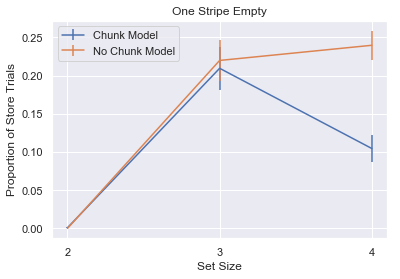

In [20]:
plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('One Stripe Empty')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()

<BarContainer object of 2 artists>

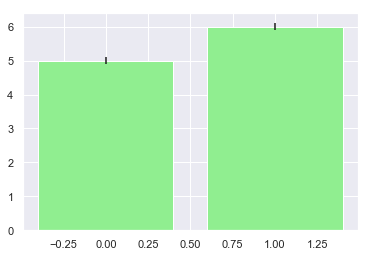

In [26]:
plt.bar([0,1], [5,6],yerr = [0.1, 0.1],color = 'lightgreen', alpha = 1.0)

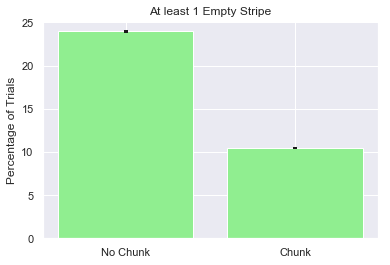

In [15]:
plt.bar(['No Chunk', 'Chunk'], [nochunkmodels_empty[2]*100,chunkmodels_empty[2]*100], yerr = [nochunkmodels_empty_std[2], chunkmodels_empty_std[2]], color = 'lightgreen',error_kw=dict(lw=2, capsize=2, capthick=2))
plt.title("At least 1 Empty Stripe")
plt.ylabel('Percentage of Trials')
plt.show()

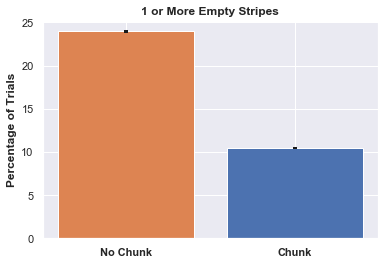

In [19]:
plt.bar(['No Chunk', 'Chunk'], [nochunkmodels_empty[2]*100,chunkmodels_empty[2]*100], yerr = [nochunkmodels_empty_std[2], chunkmodels_empty_std[2]], color = ['C1', 'C0'],error_kw=dict(lw=2, capsize=2, capthick=2))
plt.title("1 or More Empty Stripes",weight = 'bold')
plt.ylabel('Percentage of Trials', weight = 'bold')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
plt.show()

In [3]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []
print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/moremodels/"
empty_perc_all_3 = all_files_one_empty(base,item = [3])

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all+empty_perc_all_3))
chunkmodels_empty_std.append(np.std(empty_perc_all+empty_perc_all_3)/np.sqrt(320))

print('sir3 ')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/moremodels/"
empty_perc_all_3 = all_files_one_empty(base,item = [3])

print('sir4 ')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
empty_perc_all = all_files_one_empty(base,item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all+empty_perc_all_3))
nochunkmodels_empty_std.append(np.std(empty_perc_all+empty_perc_all_3)/np.sqrt(320))

sir3 chunk
sir4 chunk
sir3 
sir4 


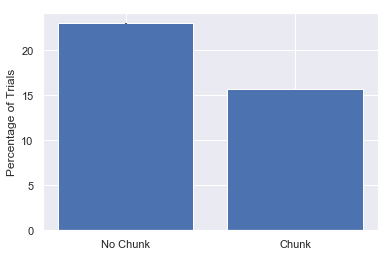

In [5]:
plt.bar(['No Chunk', 'Chunk'], [nochunkmodels_empty[0]*100,chunkmodels_empty[0]*100], yerr = [nochunkmodels_empty_std[0], chunkmodels_empty_std[0]])
#plt.title("At least 1 Empty Stripe, Set Size 4")
plt.ylabel('Percentage of Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


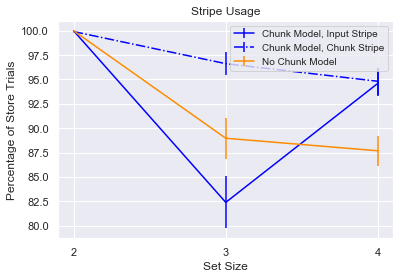

In [28]:
# item = 2

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(160))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(160))
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/moremodels/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chk_all_3 = chk_all
inp_all_3 = inp_all
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(160))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(160))

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(160))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(160))
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/moremodels/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))


plt.errorbar([2,3,4],np.array(input_used_chunkmodels)*100, yerr = np.array(input_used_chunkmodels_std)*100, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],np.array(chunk_used_chunkmodels)*100,yerr = np.array(chunk_used_chunkmodels_std)*100, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],np.array(avg_nochunkmodels)*100,yerr = np.array(avg_nochunkmodels_std)*100,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Percentage of Store Trials')
plt.show()

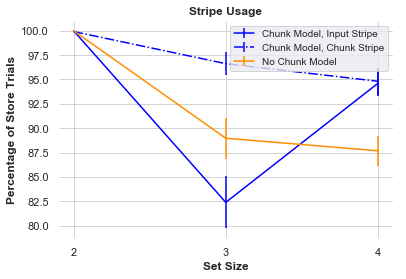

In [30]:
plt.errorbar([2,3,4],np.array(input_used_chunkmodels)*100, yerr = np.array(input_used_chunkmodels_std)*100, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],np.array(chunk_used_chunkmodels)*100,yerr = np.array(chunk_used_chunkmodels_std)*100, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],np.array(avg_nochunkmodels)*100,yerr = np.array(avg_nochunkmodels_std)*100,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage', weight = 'bold')
plt.xlabel('Set Size', weight = 'bold')
plt.ylabel('Percentage of Store Trials', weight = 'bold')
plt.grid(True, color = "lightgrey")
ax  = plt.gca()
ax.set_facecolor('white')
plt.show()

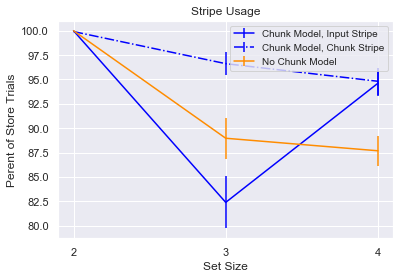

In [51]:
plt.errorbar([2,3,4],np.array(input_used_chunkmodels)*100, yerr = np.array(input_used_chunkmodels_std)*100, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],np.array(chunk_used_chunkmodels)*100,yerr = np.array(chunk_used_chunkmodels_std)*100, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],np.array(avg_nochunkmodels)*100,yerr = np.array(avg_nochunkmodels_std)*100,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Perent of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


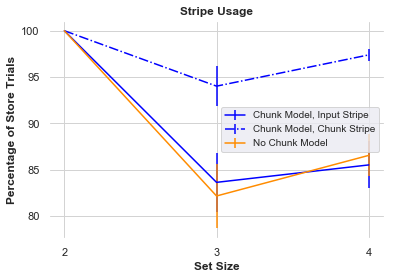

In [27]:
# item = 2
b6d6chunkmodels_empty = []
b6d6chunkmodels_empty_std = []
b6d6nochunkmodels_empty = []
b6d6nochunkmodels_empty_std = []

b6d6chunk_used_chunkmodels = []
b6d6chunk_used_chunkmodels_std = []
b6d6chunk_used_nochunkmodels = []
b6d6chunk_used_nochunkmodels_std = []

b6d6input_used_chunkmodels = []
b6d6input_used_chunkmodels_std = []
b6d6input_used_nochunkmodels = []
b6d6input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# plt.figure()
# plt.hist(chk_all)
# plt.title('Sir2 Chunk; Chunk Stripe Used')
# plt.figure()
# plt.hist(inp_all)
# plt.title('Sir2 Chunk; Input Stripe Used')
# plt.figure()
# plt.hist(empty_perc_all)
# plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# plt.figure()
# plt.hist(chk_all)
# plt.title('Sir3 Chunk; Chunk Stripe Used')
# plt.figure()
# plt.hist(inp_all)
# plt.title('Sir3 Chunk; Input Stripe Used')
# plt.figure()
# plt.hist(empty_perc_all)
# plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# plt.figure()
# plt.hist(chk_all)
# plt.title('Sir4 Chunk; Chunk Stripe Used')
# plt.figure()
# plt.hist(inp_all)
# plt.title('Sir4 Chunk; Input Stripe Used')
# plt.figure()
# plt.hist(empty_perc_all)
# plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
b6d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_nochunkmodels.append(np.mean(inp_all))
b6d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# plt.figure()
# plt.hist(chk_all)
# plt.title('Sir2 No Chunk; Chunk Stripe Used')
# plt.figure()
# plt.hist(inp_all)
# plt.title('Sir2 No Chunk; Input Stripe Used')
# plt.figure()
# plt.hist(empty_perc_all)
# plt.title('Sir2 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
b6d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_nochunkmodels.append(np.mean(inp_all))
b6d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# plt.figure()
# plt.hist(chk_all)
# plt.title('Sir3 No Chunk; Chunk Stripe Used')
# plt.figure()
# plt.hist(inp_all)
# plt.title('Sir3 No Chunk; Input Stripe Used')
# plt.figure()
# plt.hist(empty_perc_all)
# plt.title('Sir3 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
b6d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_nochunkmodels.append(np.mean(inp_all))
b6d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# plt.figure()
# plt.hist(chk_all)
# plt.title('Sir4 No Chunk; Chunk Stripe Used')
# plt.figure()
# plt.hist(inp_all)
# plt.title('Sir4 No Chunk; Input Stripe Used')
# plt.figure()
# plt.hist(empty_perc_all)
# plt.title('Sir4 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))



plt.figure()

plt.errorbar([2,3,4],np.array(b6d6input_used_chunkmodels)*100, yerr = np.array(b6d6input_used_chunkmodels_std)*100, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],np.array(b6d6chunk_used_chunkmodels)*100,yerr = np.array(b6d6chunk_used_chunkmodels_std)*100, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],np.array(avg_nochunkmodels)*100,yerr = np.array(avg_nochunkmodels_std)*100,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage', weight = 'bold')
plt.xlabel('Set Size', weight = 'bold')
plt.ylabel('Percentage of Store Trials', weight = 'bold')
plt.grid(True, color = "lightgrey")
ax  = plt.gca()
ax.set_facecolor('white')
plt.show()


sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


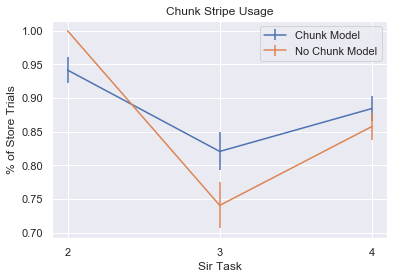

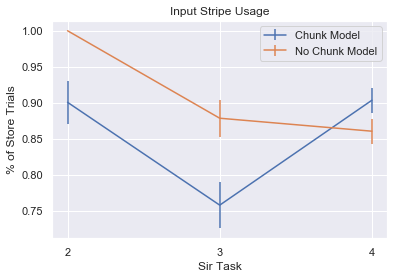

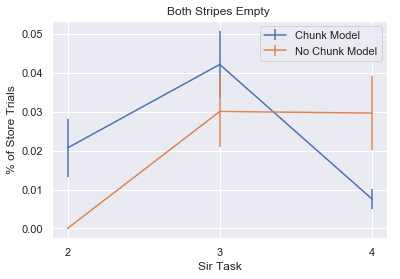

In [31]:
# item = 2
b4d16chunkmodels_empty = []
b4d16chunkmodels_empty_std = []
b4d16nochunkmodels_empty = []
b4d16nochunkmodels_empty_std = []

b4d16chunk_used_chunkmodels = []
b4d16chunk_used_chunkmodels_std = []
b4d16chunk_used_nochunkmodels = []
b4d16chunk_used_nochunkmodels_std = []

b4d16input_used_chunkmodels = []
b4d16input_used_chunkmodels_std = []
b4d16input_used_nochunkmodels = []
b4d16input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])

b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))


avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()

plt.errorbar([2,3,4],b4d16chunk_used_chunkmodels,yerr = b4d16chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b4d16chunk_used_nochunkmodels,yerr = b4d16chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b4d16input_used_chunkmodels, yerr = b4d16input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b4d16input_used_nochunkmodels,yerr = b4d16input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b4d16chunkmodels_empty,yerr = b4d16chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b4d16nochunkmodels_empty, yerr = b4d16nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

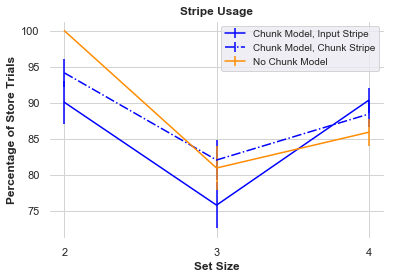

In [33]:
plt.figure()

plt.errorbar([2,3,4],np.array(b4d16input_used_chunkmodels)*100, yerr = np.array(b4d16input_used_chunkmodels_std)*100, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],np.array(b4d16chunk_used_chunkmodels)*100,yerr = np.array(b4d16chunk_used_chunkmodels_std)*100, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],np.array(avg_nochunkmodels)*100,yerr = np.array(avg_nochunkmodels_std)*100,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage', weight = 'bold')
plt.xlabel('Set Size', weight = 'bold')
plt.ylabel('Percentage of Store Trials', weight = 'bold')
plt.grid(True, color = "lightgrey")
ax  = plt.gca()
ax.set_facecolor('white')
plt.show()


sir2 chunk
sir3 chunk
sir4 chunk
combining sir3 and sir 4
sir2 no chunk
sir3 no chunk
sir4 no chunk
combining 3 and 4


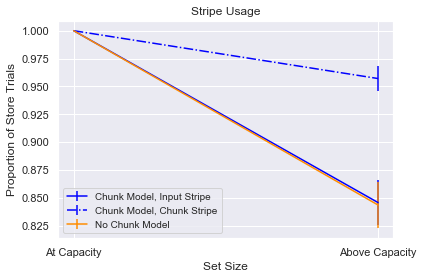

In [23]:
# item = 2
b6d6chunkmodels_empty = []
b6d6chunkmodels_empty_std = []
b6d6nochunkmodels_empty = []
b6d6nochunkmodels_empty_std = []

b6d6chunk_used_chunkmodels = []
b6d6chunk_used_chunkmodels_std = []
b6d6chunk_used_nochunkmodels = []
b6d6chunk_used_nochunkmodels_std = []

b6d6input_used_chunkmodels = []
b6d6input_used_chunkmodels_std = []
b6d6input_used_nochunkmodels = []
b6d6input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
print("combining sir3 and sir 4")
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])

b6d6chunk_used_chunkmodels.append(np.mean(chk_all+chk_all_3))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all+chk_all_3)/np.sqrt(160))
b6d6input_used_chunkmodels.append(np.mean(inp_all+inp_all_3))
b6d6input_used_chunkmodels_std.append(np.std(inp_all+inp_all_3)/np.sqrt(160))
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
avg_list_3 = chk_all+inp_all

print('sir4 no chunk')
print("combining 3 and 4")
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])

avg_list = avg_list_3+chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))


plt.errorbar([2,3],b6d6input_used_chunkmodels, yerr = b6d6input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3],b6d6chunk_used_chunkmodels,yerr = b6d6chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3], labels = ["At Capacity", "Above Capacity"])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()


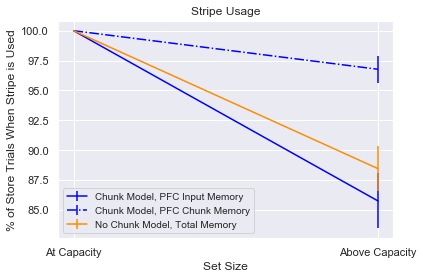

In [37]:
# item = 2

# #Burst 10, Dip 10

# b6d6chunkmodels_empty = []
# b6d6chunkmodels_empty_std = []
# b6d6nochunkmodels_empty = []
# b6d6nochunkmodels_empty_std = []

# b6d6chunk_used_chunkmodels = []
# b6d6chunk_used_chunkmodels_std = []
# b6d6chunk_used_nochunkmodels = []
# b6d6chunk_used_nochunkmodels_std = []

# b6d6input_used_chunkmodels = []
# b6d6input_used_chunkmodels_std = []
# b6d6input_used_nochunkmodels = []
# b6d6input_used_nochunkmodels_std = []

# avg_nochunkmodels = []
# avg_nochunkmodels_std = []

# print('sir2 chunk')
# base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
# chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

# b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
# b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
# b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
# b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
# b6d6input_used_chunkmodels.append(np.mean(inp_all))
# b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
# chk_all_2 = chk_all
# inp_all_2 = inp_all

# print('sir3 chunk')
# base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
# chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
# chk_all_3 = chk_all
# inp_all_3 = inp_all

# print('sir4 chunk')
# print("combining sir3 and sir 4")
# base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
# chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])

# b6d6chunk_used_chunkmodels.append(np.mean(chk_all+chk_all_3))
# b6d6chunk_used_chunkmodels_std.append(np.std(chk_all+chk_all_3)/np.sqrt(160))
# b6d6input_used_chunkmodels.append(np.mean(inp_all+inp_all_3))
# b6d6input_used_chunkmodels_std.append(np.std(inp_all+inp_all_3)/np.sqrt(160))
# chk_all_4 = chk_all
# inp_all_4 = inp_all

# print('sir2 no chunk')
# base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
# chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
# avg_list = chk_all+inp_all
# avg_nochunkmodels.append(np.mean(avg_list))
# avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

# print('sir3 no chunk')
# base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
# chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
# avg_list_3 = chk_all+inp_all

# print('sir4 no chunk')
# print("combining 3 and 4")
# base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
# chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])

# avg_list = avg_list_3+chk_all+inp_all
# avg_nochunkmodels.append(np.mean(avg_list))
# avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))


plt.errorbar([2,3],[b6d6input_used_chunkmodels[0]*100,b6d6input_used_chunkmodels[1]*100], yerr = [b6d6input_used_chunkmodels_std[0]*100, b6d6input_used_chunkmodels_std[1]*100], label='Chunk Model, PFC Input Memory', color = 'blue')
plt.errorbar([2,3],[b6d6chunk_used_chunkmodels[0]*100,b6d6chunk_used_chunkmodels[1]*100],yerr = [b6d6chunk_used_chunkmodels_std[0]*100,b6d6chunk_used_chunkmodels_std[1]*100], label='Chunk Model, PFC Chunk Memory', color = 'blue', ls= '-.')
plt.errorbar([2,3],[avg_nochunkmodels[0]*100,avg_nochunkmodels[1]*100],yerr = [avg_nochunkmodels_std[0]*100, avg_nochunkmodels_std[1]*100],label='No Chunk Model, Total Memory', color = 'darkorange')
plt.xticks([2,3], labels = ["At Capacity", "Above Capacity"])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('% of Store Trials When Stripe is Used')
plt.show()


sir2 chunk
sir3 chunk
sir4 chunk
combining sir3 and sir 4
sir2 no chunk
sir3 no chunk
sir4 no chunk
combining 3 and 4


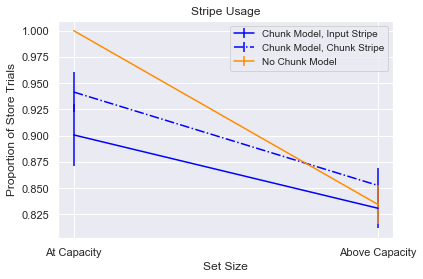

In [26]:
# item = 2

#Burst 4/ Dip 16

b6d6chunkmodels_empty = []
b6d6chunkmodels_empty_std = []
b6d6nochunkmodels_empty = []
b6d6nochunkmodels_empty_std = []

b6d6chunk_used_chunkmodels = []
b6d6chunk_used_chunkmodels_std = []
b6d6chunk_used_nochunkmodels = []
b6d6chunk_used_nochunkmodels_std = []

b6d6input_used_chunkmodels = []
b6d6input_used_chunkmodels_std = []
b6d6input_used_nochunkmodels = []
b6d6input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
print("combining sir3 and sir 4")
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])

b6d6chunk_used_chunkmodels.append(np.mean(chk_all+chk_all_3))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all+chk_all_3)/np.sqrt(160))
b6d6input_used_chunkmodels.append(np.mean(inp_all+inp_all_3))
b6d6input_used_chunkmodels_std.append(np.std(inp_all+inp_all_3)/np.sqrt(160))
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
avg_list_3 = chk_all+inp_all

print('sir4 no chunk')
print("combining 3 and 4")
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])

avg_list = avg_list_3+chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))


plt.errorbar([2,3],b6d6input_used_chunkmodels, yerr = b6d6input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3],b6d6chunk_used_chunkmodels,yerr = b6d6chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3], labels = ["At Capacity", "Above Capacity"])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()


In [ ]:
# item = 2

#Burst 10, Dip 10

b6d6chunkmodels_empty = []
b6d6chunkmodels_empty_std = []
b6d6nochunkmodels_empty = []
b6d6nochunkmodels_empty_std = []

b6d6chunk_used_chunkmodels = []
b6d6chunk_used_chunkmodels_std = []
b6d6chunk_used_nochunkmodels = []
b6d6chunk_used_nochunkmodels_std = []

b6d6input_used_chunkmodels = []
b6d6input_used_chunkmodels_std = []
b6d6input_used_nochunkmodels = []
b6d6input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
print("combining sir3 and sir 4")
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])

b6d6chunk_used_chunkmodels.append(np.mean(chk_all+chk_all_3))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all+chk_all_3)/np.sqrt(160))
b6d6input_used_chunkmodels.append(np.mean(inp_all+inp_all_3))
b6d6input_used_chunkmodels_std.append(np.std(inp_all+inp_all_3)/np.sqrt(160))
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
avg_list_3 = chk_all+inp_all

print('sir4 no chunk')
print("combining 3 and 4")
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])

avg_list = avg_list_3+chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(160))


plt.errorbar([2,3],b6d6input_used_chunkmodels, yerr = b6d6input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3],b6d6chunk_used_chunkmodels,yerr = b6d6chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3], labels = ["At Capacity", "Above Capacity"])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()


sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


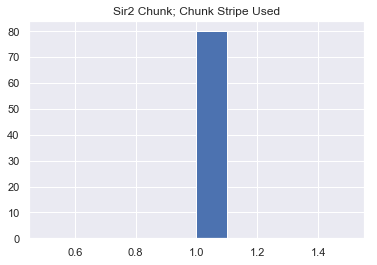

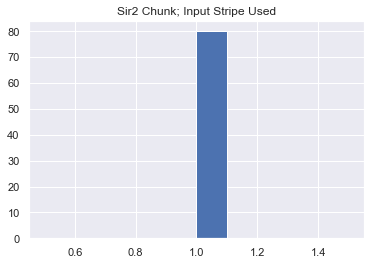

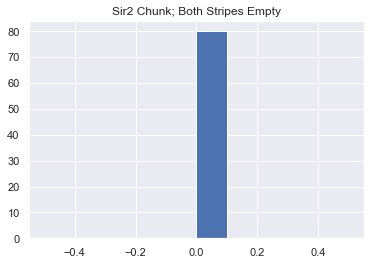

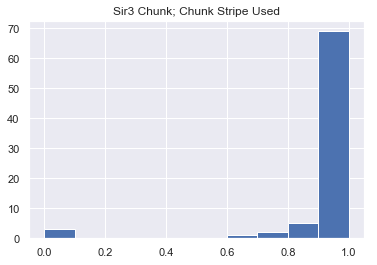

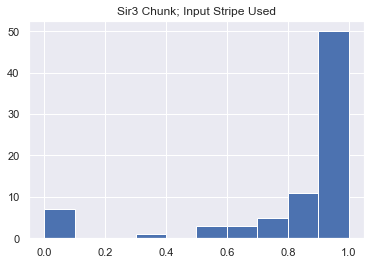

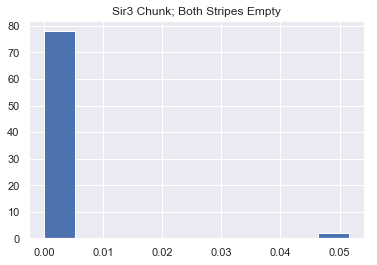

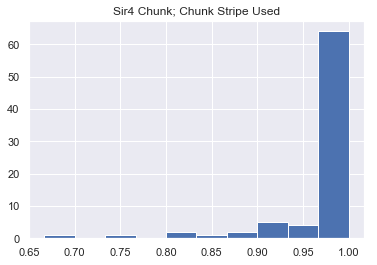

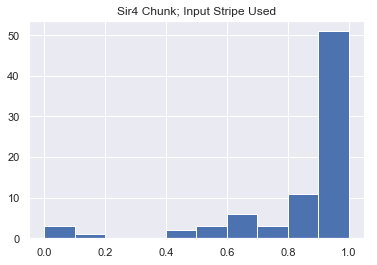

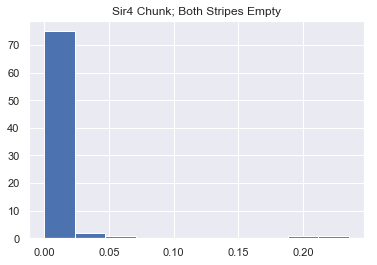

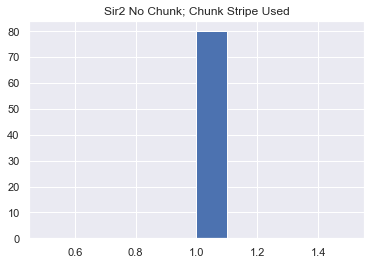

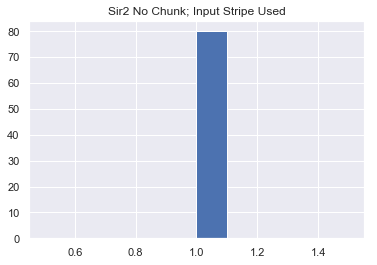

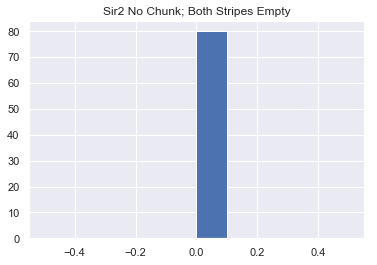

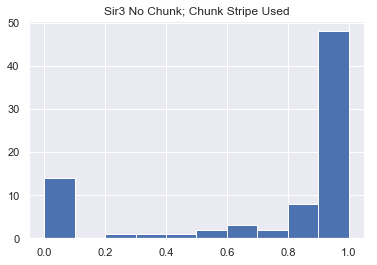

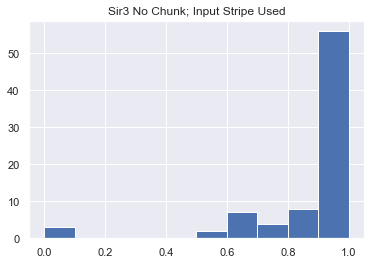

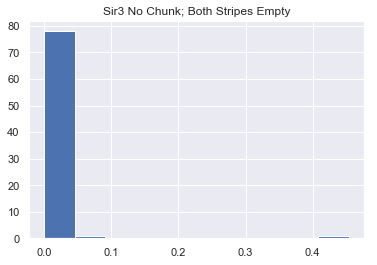

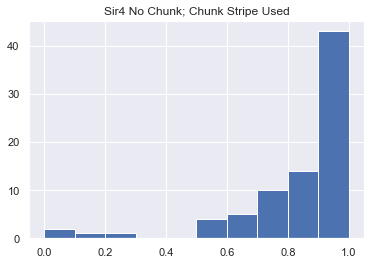

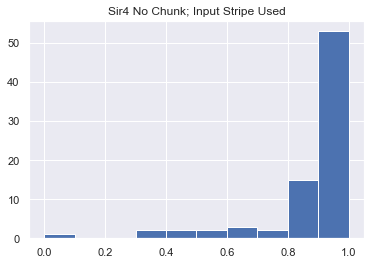

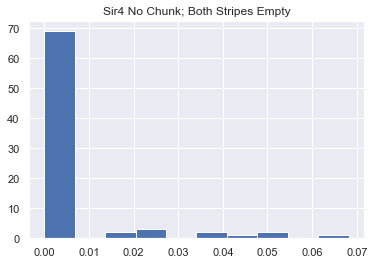

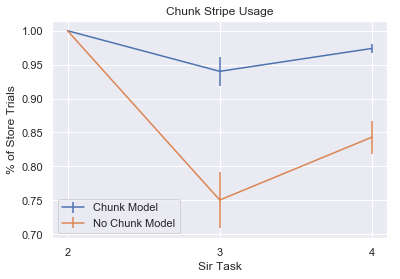

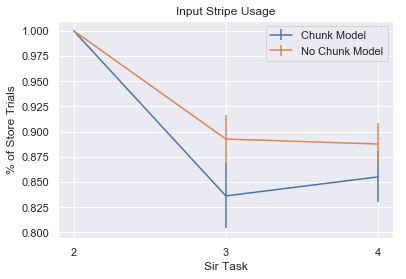

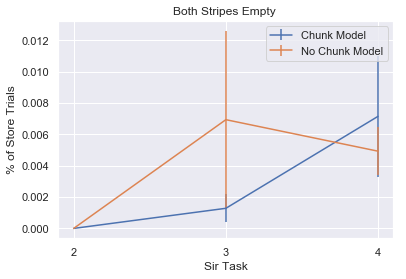

In [17]:
# item = 2
b6d6chunkmodels_empty = []
b6d6chunkmodels_empty_std = []
b6d6nochunkmodels_empty = []
b6d6nochunkmodels_empty_std = []

b6d6chunk_used_chunkmodels = []
b6d6chunk_used_chunkmodels_std = []
b6d6chunk_used_nochunkmodels = []
b6d6chunk_used_nochunkmodels_std = []

b6d6input_used_chunkmodels = []
b6d6input_used_chunkmodels_std = []
b6d6input_used_nochunkmodels = []
b6d6input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])

b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
b6d6chunkmodels_empty.append(np.mean(empty_perc_all))
b6d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_chunkmodels.append(np.mean(chk_all))
b6d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_chunkmodels.append(np.mean(inp_all))
b6d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
b6d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_nochunkmodels.append(np.mean(inp_all))
b6d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
b6d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_nochunkmodels.append(np.mean(inp_all))
b6d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
b6d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d6input_used_nochunkmodels.append(np.mean(inp_all))
b6d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()

plt.errorbar([2,3,4],b6d6chunk_used_chunkmodels,yerr = b6d6chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b6d6chunk_used_nochunkmodels,yerr = b6d6chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b6d6input_used_chunkmodels, yerr = b6d6input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b6d6input_used_nochunkmodels,yerr = b6d6input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b6d6chunkmodels_empty,yerr = b6d6chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b6d6nochunkmodels_empty, yerr = b6d6nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

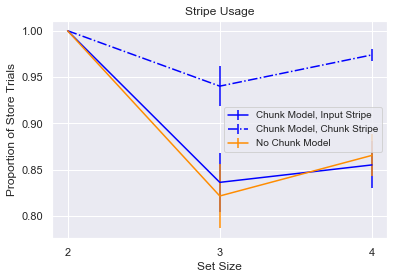

In [18]:
plt.errorbar([2,3,4],b6d6input_used_chunkmodels, yerr = b6d6input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],b6d6chunk_used_chunkmodels,yerr = b6d6chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()


In [ ]:
b6d6input_used_chunkmodels
plt.errorbar([2,3],b6d6input_used_chunkmodels[0],np.mean(b6d6input_used_chunkmodels[1], ), yerr = b6d6input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3],b6d6chunk_used_chunkmodels,yerr = b6d6chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3], labels = ["At Capacity", "Above Capacity"])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()


sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


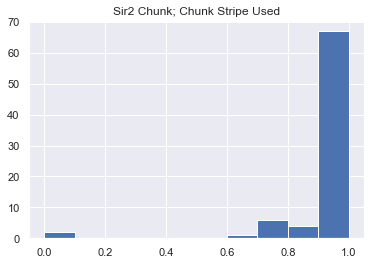

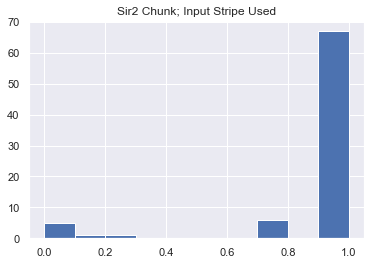

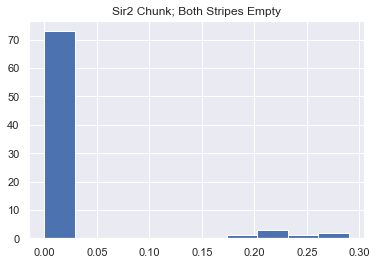

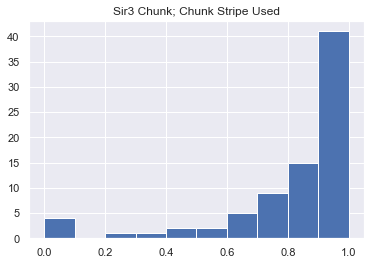

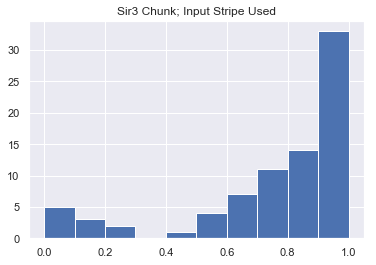

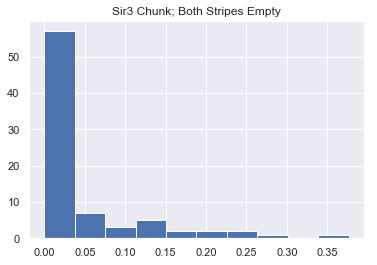

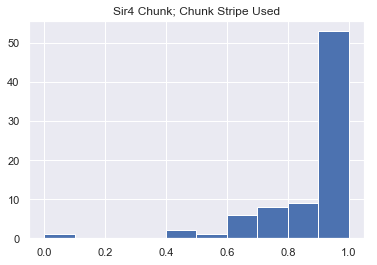

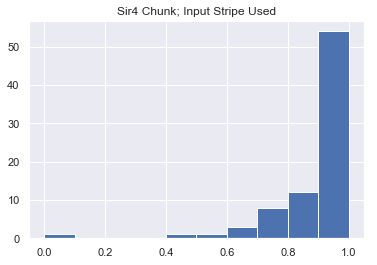

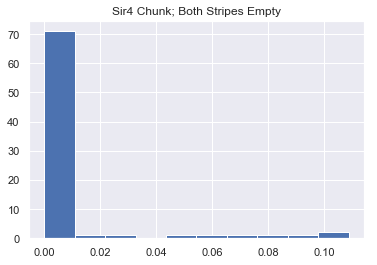

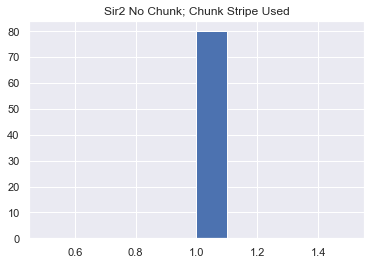

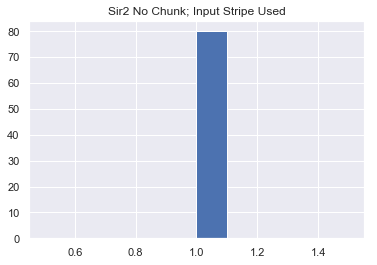

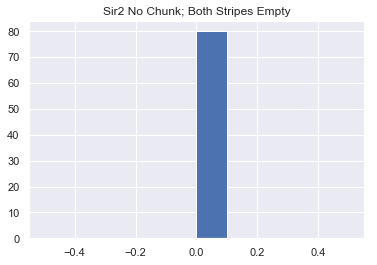

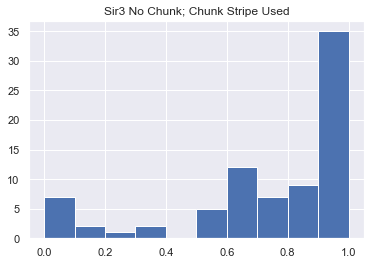

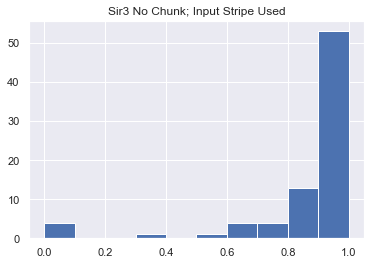

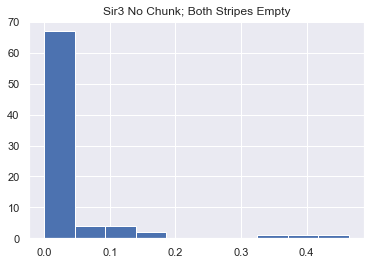

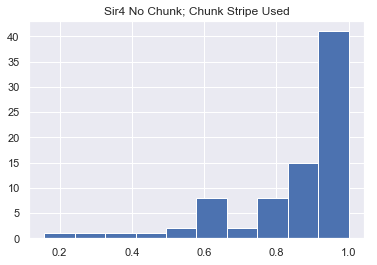

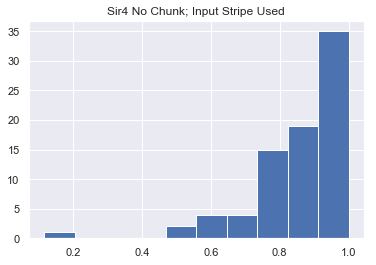

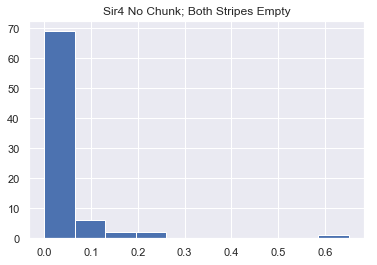

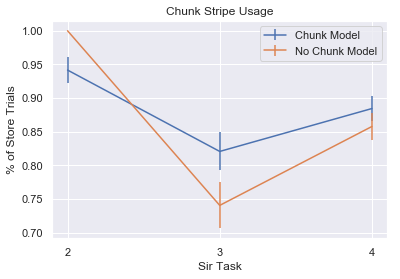

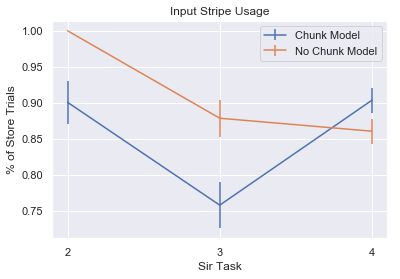

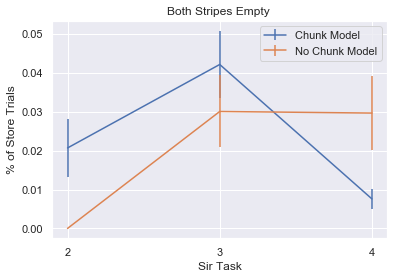

In [14]:
# item = 2
b4d16chunkmodels_empty = []
b4d16chunkmodels_empty_std = []
b4d16nochunkmodels_empty = []
b4d16nochunkmodels_empty_std = []

b4d16chunk_used_chunkmodels = []
b4d16chunk_used_chunkmodels_std = []
b4d16chunk_used_nochunkmodels = []
b4d16chunk_used_nochunkmodels_std = []

b4d16input_used_chunkmodels = []
b4d16input_used_chunkmodels_std = []
b4d16input_used_nochunkmodels = []
b4d16input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])

b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()

plt.errorbar([2,3,4],b4d16chunk_used_chunkmodels,yerr = b4d16chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b4d16chunk_used_nochunkmodels,yerr = b4d16chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b4d16input_used_chunkmodels, yerr = b4d16input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b4d16input_used_nochunkmodels,yerr = b4d16input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b4d16chunkmodels_empty,yerr = b4d16chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b4d16nochunkmodels_empty, yerr = b4d16nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

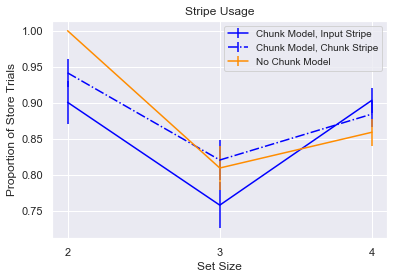

In [15]:
plt.errorbar([2,3,4],b4d16input_used_chunkmodels, yerr = b4d16input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],b4d16chunk_used_chunkmodels,yerr = b4d16chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()


In [10]:

# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

sir2 chunk


KeyError: '#stripe'

In [6]:
print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/8Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/GpiThalInhib24/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chk_all_4_chunk = chk_all
inp_all_4_chunk = inp_all
print(np.mean(chk_all)/np.mean(inp_all))


print('sir4')
base = "Y:/sir4/results/Ring/8Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/GpiThalInhib24/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chk_all_4_chunk = chk_all
inp_all_4_chunk = inp_all
print(np.mean(chk_all)/np.mean(inp_all))

sir4 chunk
1.0197363552505958
sir4
0.9842129360693957


sir4 chunk
1.0383580664754979
sir4
1.031950261472467


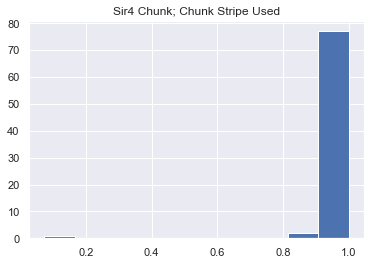

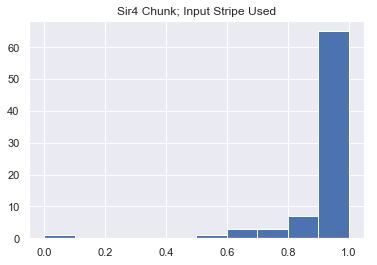

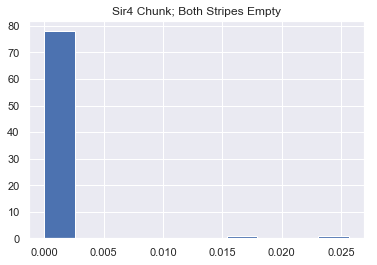

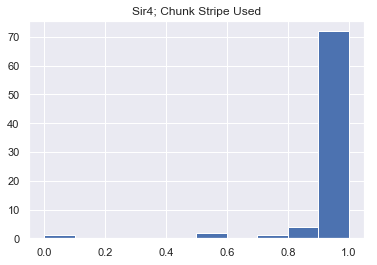

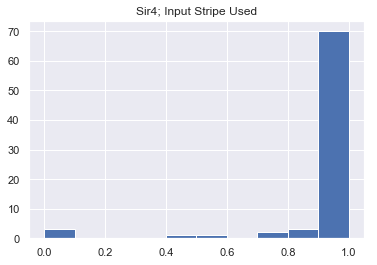

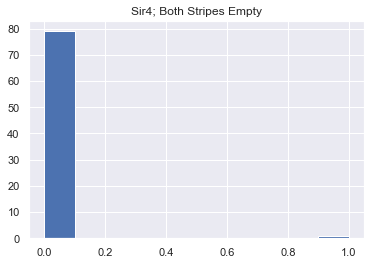

In [5]:
print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/8Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/GpiThalInhib22/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4_chunk = chk_all
inp_all_4_chunk = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

print('sir4')
base = "Y:/sir4/results/Ring/8Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/GpiThalInhib22/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
plt.figure()
plt.hist(chk_all)
plt.title('Sir4; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all
print(np.mean(chk_all)/np.mean(inp_all))


sir2 chunk
0.9637907962143143
sir2
1.0399007417800028
sir3_chunk
1.0369942587201995
sir3
0.9025764019213486
sir4 chunk
0.9976741777740296
sir4
1.00618304706208


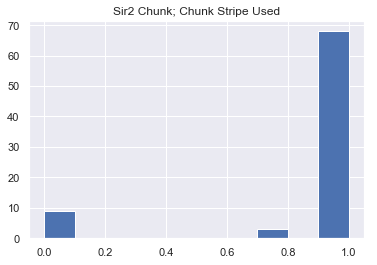

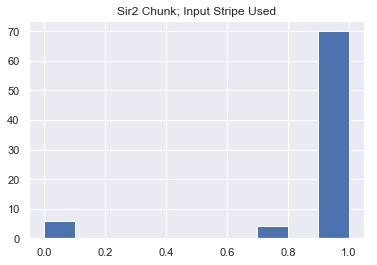

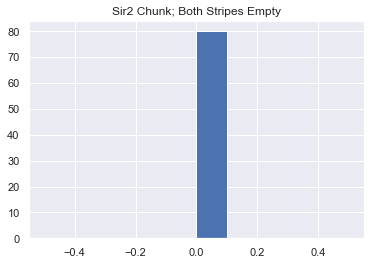

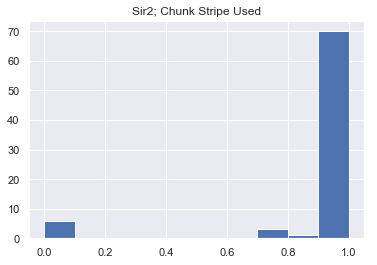

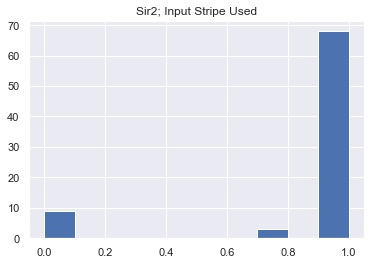

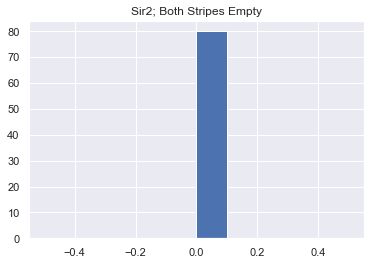

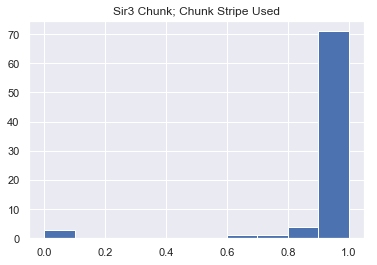

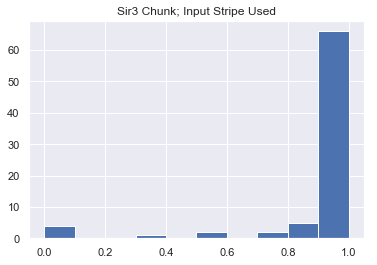

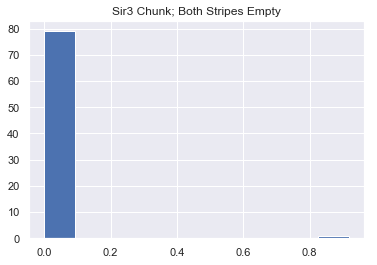

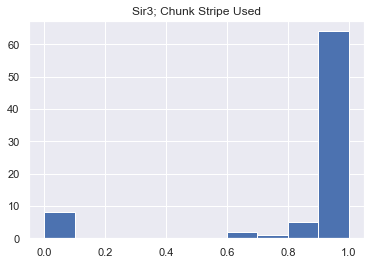

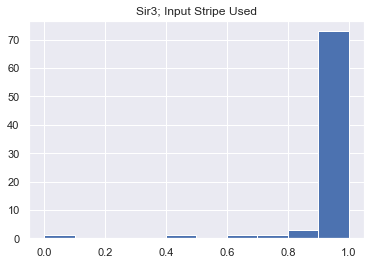

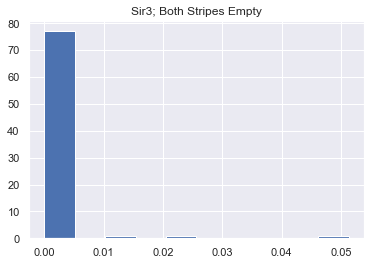

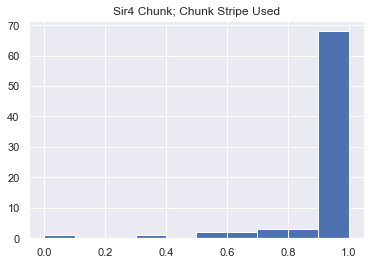

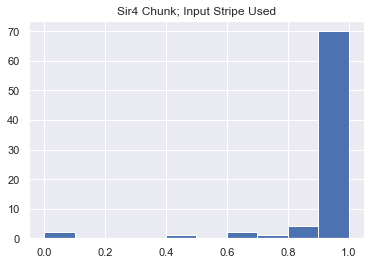

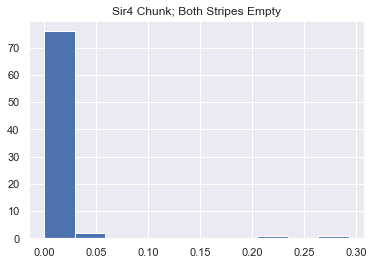

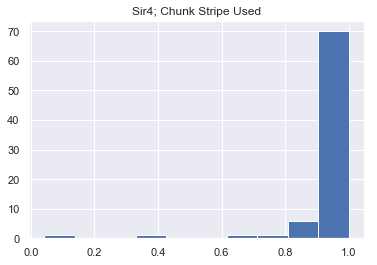

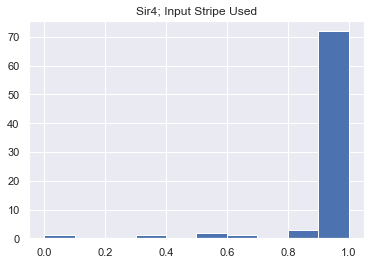

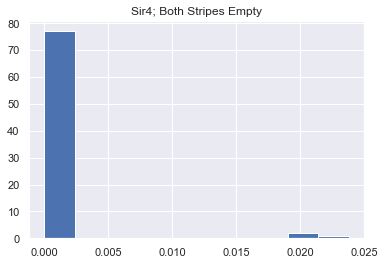

In [14]:
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/3Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

print('sir2')
base = "Y:/sir2_new/results/Ring/3Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])
plt.figure()
plt.hist(chk_all)
plt.title('Sir2; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

print('sir3_chunk')
base = "Y:/sir3_chunk/results/Ring/3Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

print('sir3')
base = "Y:/sir3/results/Ring/3Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
plt.figure()
plt.hist(chk_all)
plt.title('Sir3; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/3Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

print('sir4')
base = "Y:/sir4/results/Ring/3Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
plt.figure()
plt.hist(chk_all)
plt.title('Sir4; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

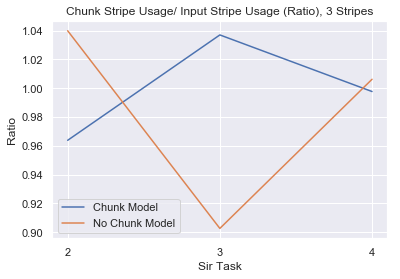

In [16]:
sir2_r = 0.9637907962143143; sir2_r_nochunk = 1.0399007417800028; sir3_r = 1.0369942587201995; sir3_r_nochunk = 0.9025764019213486; sir4_r = 0.9976741777740296; sir4_r_nochunk = 1.00618304706208;
plt.plot([2,3,4],[sir2_r,sir3_r,sir4_r], label = 'Chunk Model')
plt.plot([2,3,4],[sir2_r_nochunk,sir3_r_nochunk,sir4_r_nochunk],label = 'No Chunk Model')
plt.legend()
plt.xticks([2,3,4])
plt.title('Chunk Stripe Usage/ Input Stripe Usage (Ratio), 3 Stripes')
plt.xlabel('Sir Task')
plt.ylabel('Ratio')
plt.show()

sir2 chunk
1.0


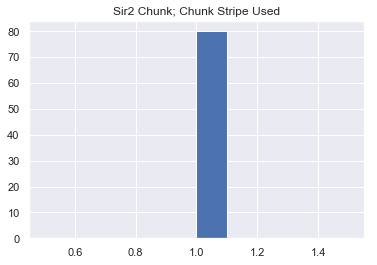

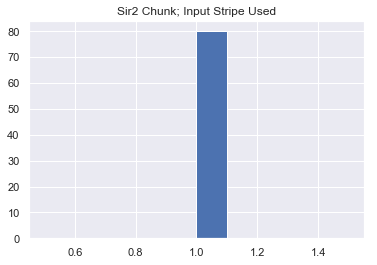

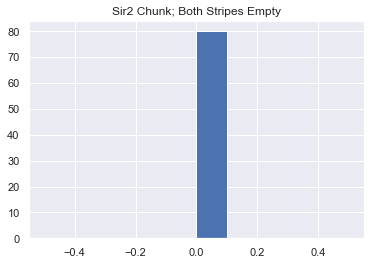

In [13]:
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

sir2
1.0


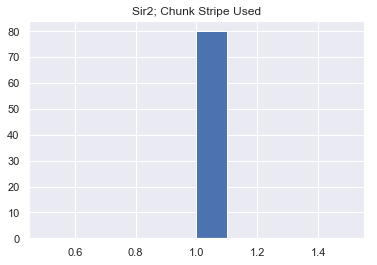

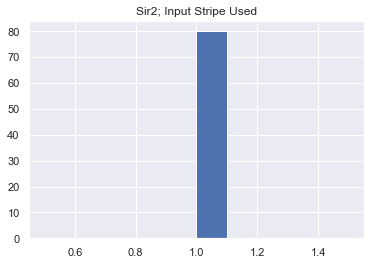

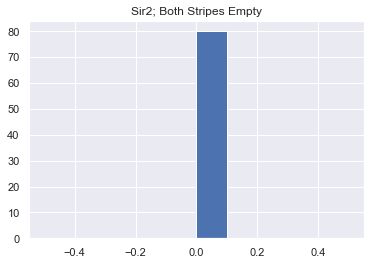

In [12]:
print('sir2')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])
plt.figure()
plt.hist(chk_all)
plt.title('Sir2; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

sir3_chunk
1.1662843153307783


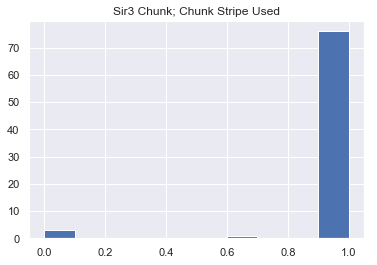

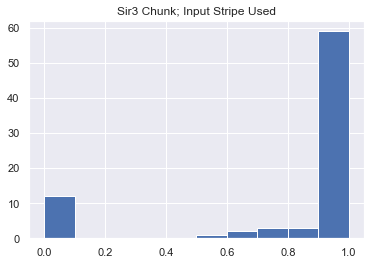

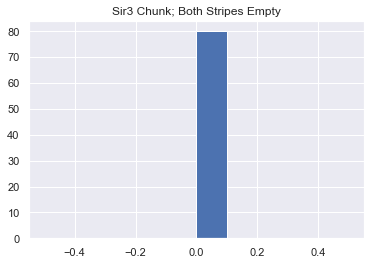

In [9]:
print('sir3_chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

sir3
1.0228124618516377


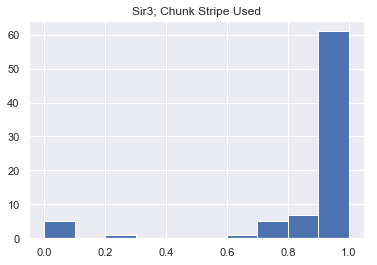

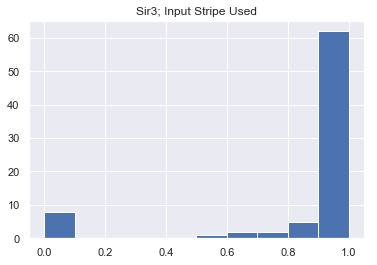

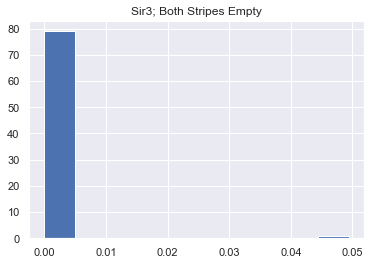

In [8]:
print('sir3')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
plt.figure()
plt.hist(chk_all)
plt.title('Sir3; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

sir4
1.0485568397147416


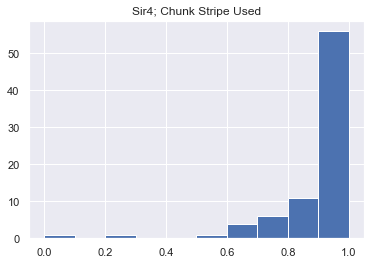

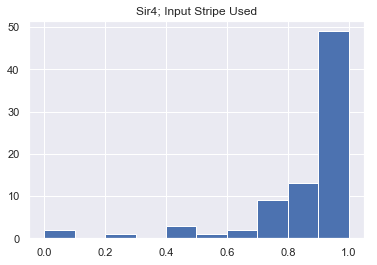

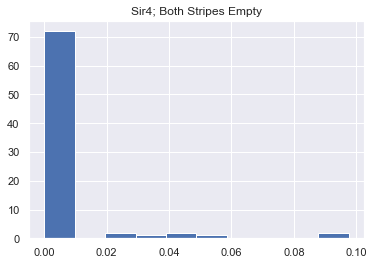

In [5]:
print('sir4')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
plt.figure()
plt.hist(chk_all)
plt.title('Sir4; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

sir4 chunk
1.0940961068997508


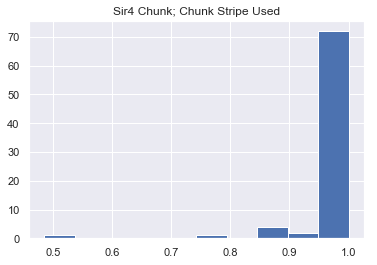

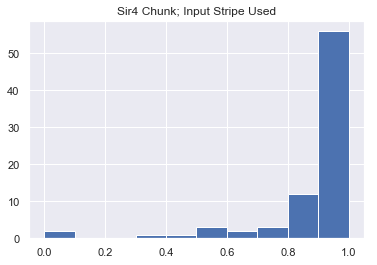

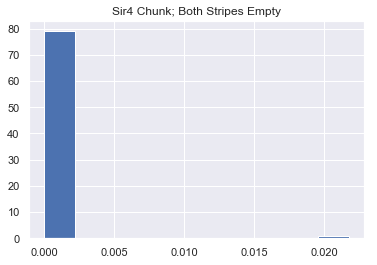

In [7]:
print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print(np.mean(chk_all)/np.mean(inp_all))

In [11]:
np.mean(inp_all)

0.8956088477949322

In [9]:
np.mean(chk_all)/np.mean(inp_all)

1.0940961068997508

In [23]:

# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = ['all'])

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = ['all'])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = ['all'])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = ['all'])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = ['all'])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = ['all'])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

sir2 chunk


KeyError: '#stripe'

In [13]:
sir2_r = chunk_used_chunkmodels[0]/input_used_chunkmodels[0]
sir3_r =chunk_used_chunkmodels[1]/input_used_chunkmodels[1]
sir4_r =chunk_used_chunkmodels[2]/input_used_chunkmodels[2]


In [18]:
sir2_r_nochunk = chunk_used_nochunkmodels[0]/input_used_nochunkmodels[0]
sir3_r_nochunk =chunk_used_nochunkmodels[1]/input_used_nochunkmodels[1]
sir4_r_nochunk =chunk_used_nochunkmodels[2]/input_used_nochunkmodels[2]


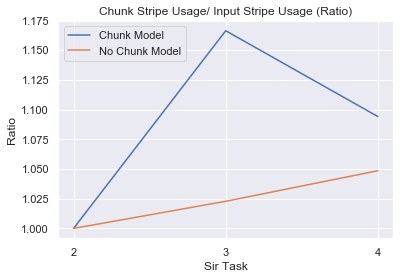

In [22]:
plt.plot([2,3,4],[sir2_r,sir3_r,sir4_r], label = 'Chunk Model')
plt.plot([2,3,4],[sir2_r_nochunk,sir3_r_nochunk,sir4_r_nochunk],label = 'No Chunk Model')
plt.legend()
plt.xticks([2,3,4])
plt.title('Chunk Stripe Usage/ Input Stripe Usage (Ratio)')
plt.xlabel('Sir Task')
plt.ylabel('Ratio')
plt.show()

In [18]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir2 new')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all = all_files_one_empty(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir3 ')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all = all_files_one_empty(base,item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir4 ')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

sir2 chunk
sir2 new
sir3 chunk
sir3 
sir4 chunk
sir4 


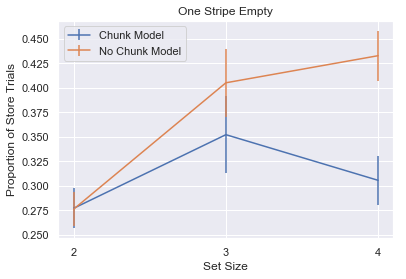

In [19]:
plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('One Stripe Empty')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()

In [25]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []
print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all_3 = all_files_one_empty(base,item = [3])

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all+empty_perc_all_3))
chunkmodels_empty_std.append(np.std(empty_perc_all+empty_perc_all_3)/np.sqrt(160))

print('sir3 ')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all_3 = all_files_one_empty(base,item = [3])

print('sir4 ')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all+empty_perc_all_3))
nochunkmodels_empty_std.append(np.std(empty_perc_all+empty_perc_all_3)/np.sqrt(160))

sir3 chunk
sir4 chunk
sir3 
sir4 


In [31]:
np.mean(empty_perc_all+empty_perc_all_3)

0.13372709770703387

In [29]:
nochunkmodels_empty

[0.22816757778070595]

<BarContainer object of 2 artists>

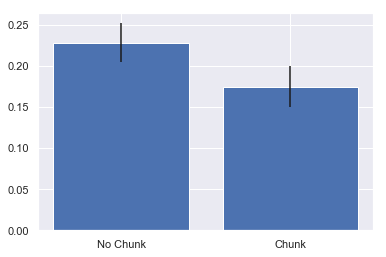

In [32]:
plt.bar(['No Chunk', 'Chunk'], [nochunkmodels_empty[0],chunkmodels_empty[0]], yerr = [nochunkmodels_empty_std[0], chunkmodels_empty_std[0]])

In [5]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [2])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir2 new')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [2])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all = all_files_one_empty(base,item = [3])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir3 ')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all = all_files_one_empty(base,item = [3])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir4 ')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))

sir2 chunk
sir2 new
sir3 chunk
sir3 
sir4 chunk
sir4 


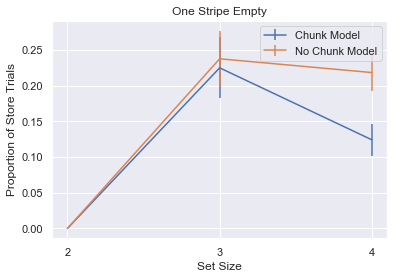

In [7]:
plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('One Stripe Empty')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()

In [ ]:
#not nec for now
chunkmodels_empty_8stripes = []
chunkmodels_empty_std_8stripes = []
nochunkmodels_empty_8stripes = []
nochunkmodels_empty_std_8stripes = []
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/8Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [2])
chunkmodels_empty_8stripes.append(np.mean(empty_perc_all))
chunkmodels_empty_std_8stripes.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir2 new')
base = "Y:/sir2_new/results/Ring/8Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [2])
nochunkmodels_empty_8stripes.append(np.mean(empty_perc_all))
nochunkmodels_empty_std_8stripes.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/8Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all = all_files_one_empty(base,item = [3])
chunkmodels_empty_8stripes.append(np.mean(empty_perc_all))
chunkmodels_empty_std_8stripes.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir3 ')
base = "Y:/sir3/results/Ring/8Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/recordout/"
empty_perc_all = all_files_one_empty(base,item = [3])
nochunkmodels_empty_8stripes.append(np.mean(empty_perc_all))
nochunkmodels_empty_std_8stripes.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/8Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [4])
chunkmodels_empty_8stripes.append(np.mean(empty_perc_all))
chunkmodels_empty_std_8stripes.append(np.std(empty_perc_all)/np.sqrt(80))

print('sir4 ')
base = "Y:/sir4/results/Ring/8Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/recordout/"
empty_perc_all = all_files_one_empty(base,item = [4])
nochunkmodels_empty_8stripes.append(np.mean(empty_perc_all))
nochunkmodels_empty_std_8stripes.append(np.std(empty_perc_all)/np.sqrt(80))

In [ ]:

# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

avg_nochunkmodels = []
avg_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))

avg_list = chk_all+inp_all
avg_nochunkmodels.append(np.mean(avg_list))
avg_nochunkmodels_std.append(np.std(avg_list)/np.sqrt(80))

plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('Proportion of Store Trials')
plt.show()

In [ ]:
plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model, Input Stripe', color = 'blue')
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model, Chunk Stripe', color = 'blue', ls= '-.')
plt.errorbar([2,3,4],avg_nochunkmodels,yerr = avg_nochunkmodels_std,label='No Chunk Model', color = 'darkorange')
plt.xticks([2,3,4])
plt.legend(prop = { "size": 10 })
plt.title('Stripe Usage')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Set Size')
plt.ylabel('Proportion of Store Trials')
plt.show()

In [ ]:
#need to try this with sir2 and sir4 lrate 0.04 and sir3 lrate 0.06
#need to plug in the results from 0.06 lrate.run in morning

#these results don;t look like the results from before?? 
# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))


plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))


plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()



In [ ]:
#need to try this with sir2 and sir4 lrate 0.04 and sir3 lrate 0.06
#need to plug in the results from 0.06 lrate.run in morning

#these results don;t look like the results from before?? 
# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 'all')

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
#these results don;t look like the results from before?? 
# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 'all')

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 'all')
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 'all')
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
#these results don;t look like the results from before?? 
# item = 2
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
# item = 2
b4d16chunkmodels_empty = []
b4d16chunkmodels_empty_std = []
b4d16nochunkmodels_empty = []
b4d16nochunkmodels_empty_std = []

b4d16chunk_used_chunkmodels = []
b4d16chunk_used_chunkmodels_std = []
b4d16chunk_used_nochunkmodels = []
b4d16chunk_used_nochunkmodels_std = []

b4d16input_used_chunkmodels = []
b4d16input_used_chunkmodels_std = []
b4d16input_used_nochunkmodels = []
b4d16input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = item)

b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 3)

b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 4)
b4d16chunkmodels_empty.append(np.mean(empty_perc_all))
b4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_chunkmodels.append(np.mean(chk_all))
b4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_chunkmodels.append(np.mean(inp_all))
b4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 2)
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 3)
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 4)
b4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b4d16input_used_nochunkmodels.append(np.mean(inp_all))
b4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],b4d16chunk_used_chunkmodels,yerr = b4d16chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b4d16chunk_used_nochunkmodels,yerr = b4d16chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b4d16input_used_chunkmodels, yerr = b4d16input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b4d16input_used_nochunkmodels,yerr = b4d16input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b4d16chunkmodels_empty,yerr = b4d16chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b4d16nochunkmodels_empty, yerr = b4d16nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
# item = 2
b16d4chunkmodels_empty = []
b16d4chunkmodels_empty_std = []
b16d4nochunkmodels_empty = []
b16d4nochunkmodels_empty_std = []

b16d4chunk_used_chunkmodels = []
b16d4chunk_used_chunkmodels_std = []
b16d4chunk_used_nochunkmodels = []
b16d4chunk_used_nochunkmodels_std = []

b16d4input_used_chunkmodels = []
b16d4input_used_chunkmodels_std = []
b16d4input_used_nochunkmodels = []
b16d4input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = item)

b16d4chunkmodels_empty.append(np.mean(empty_perc_all))
b16d4chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b16d4chunk_used_chunkmodels.append(np.mean(chk_all))
b16d4chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b16d4input_used_chunkmodels.append(np.mean(inp_all))
b16d4input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 3)

b16d4chunkmodels_empty.append(np.mean(empty_perc_all))
b16d4chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b16d4chunk_used_chunkmodels.append(np.mean(chk_all))
b16d4chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b16d4input_used_chunkmodels.append(np.mean(inp_all))
b16d4input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = 4)
b16d4chunkmodels_empty.append(np.mean(empty_perc_all))
b16d4chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b16d4chunk_used_chunkmodels.append(np.mean(chk_all))
b16d4chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b16d4input_used_chunkmodels.append(np.mean(inp_all))
b16d4input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 2)
b16d4nochunkmodels_empty.append(np.mean(empty_perc_all))
b16d4nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b16d4chunk_used_nochunkmodels.append(np.mean(chk_all))
b16d4chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b16d4input_used_nochunkmodels.append(np.mean(inp_all))
b16d4input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 3)
b16d4nochunkmodels_empty.append(np.mean(empty_perc_all))
b16d4nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b16d4chunk_used_nochunkmodels.append(np.mean(chk_all))
b16d4chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b16d4input_used_nochunkmodels.append(np.mean(inp_all))
b16d4input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = 4)
b16d4nochunkmodels_empty.append(np.mean(empty_perc_all))
b16d4nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b16d4chunk_used_nochunkmodels.append(np.mean(chk_all))
b16d4chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b16d4input_used_nochunkmodels.append(np.mean(inp_all))
b16d4input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],b16d4chunk_used_chunkmodels,yerr = b16d4chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b16d4chunk_used_nochunkmodels,yerr = b16d4chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b16d4input_used_chunkmodels, yerr = b16d4input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b16d4input_used_nochunkmodels,yerr = b16d4input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b16d4chunkmodels_empty,yerr = b16d4chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b16d4nochunkmodels_empty, yerr = b16d4nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

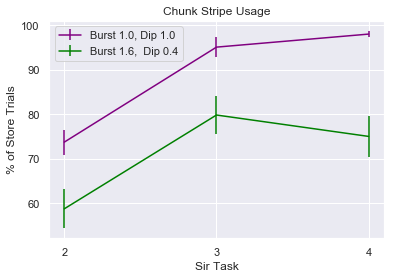

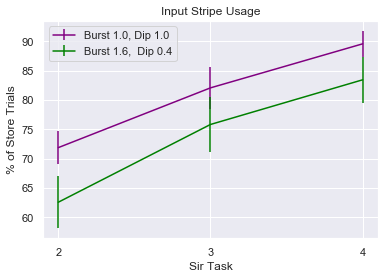

In [113]:
plt.errorbar([2,3,4],100*np.array(chunk_used_chunkmodels),yerr = 100*np.array(chunk_used_chunkmodels_std), label='Burst 1.0, Dip 1.0', color = 'purple')
plt.errorbar([2,3,4],100*np.array(b16d4chunk_used_chunkmodels),yerr = 100*np.array(b16d4chunk_used_chunkmodels_std), label='Burst 1.6,  Dip 0.4', color = 'green')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],100*np.array(input_used_chunkmodels),yerr = 100*np.array(input_used_chunkmodels_std), label='Burst 1.0, Dip 1.0', color = 'purple')
plt.errorbar([2,3,4],100*np.array(b16d4input_used_chunkmodels),yerr = 100*np.array(b16d4input_used_chunkmodels_std), label='Burst 1.6,  Dip 0.4', color = 'green')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


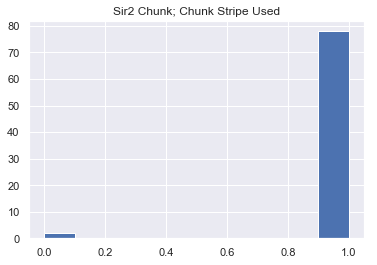

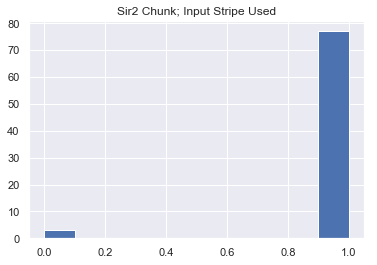

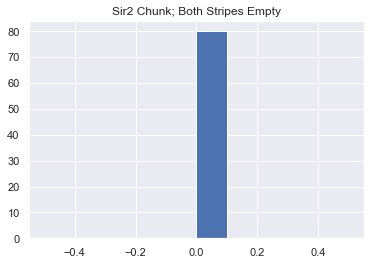

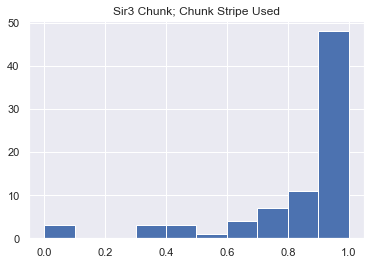

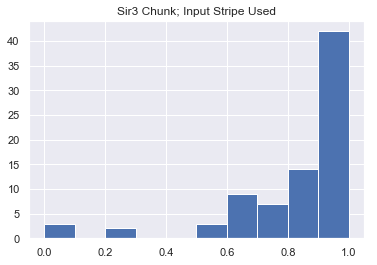

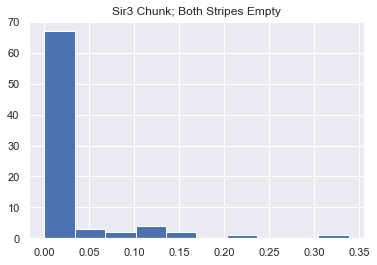

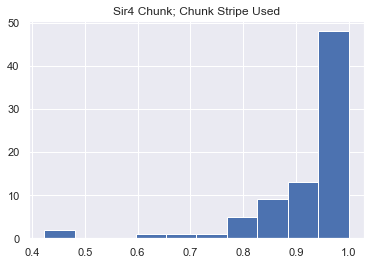

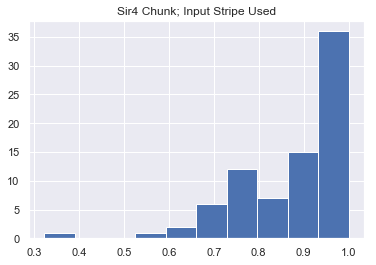

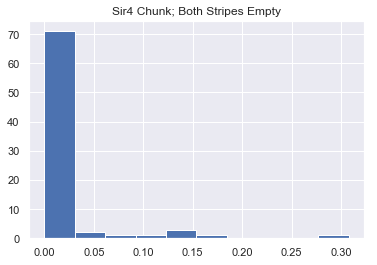

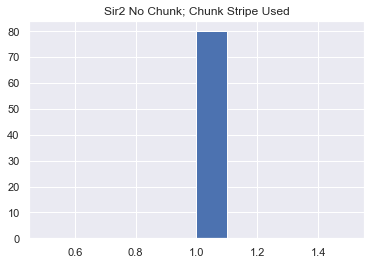

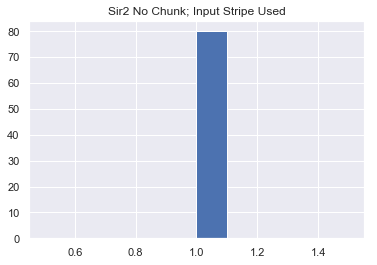

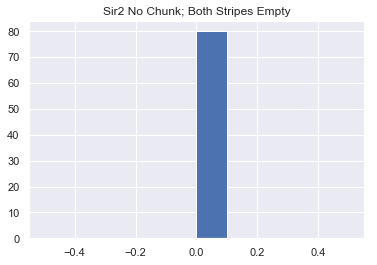

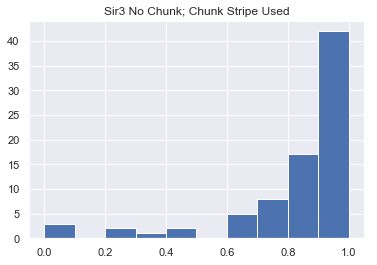

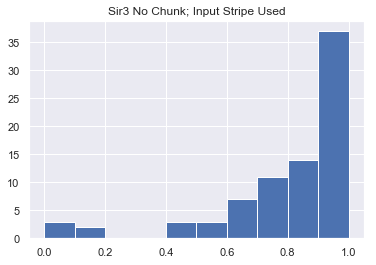

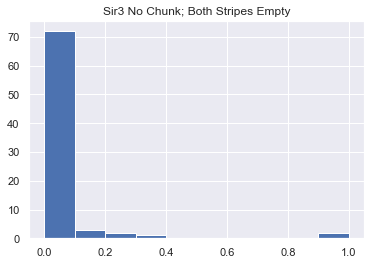

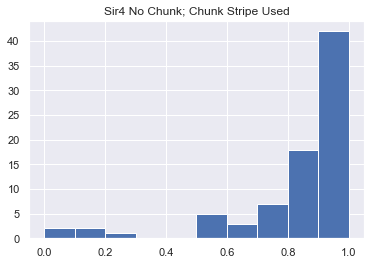

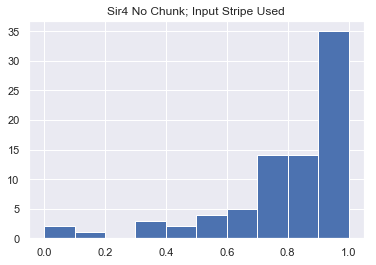

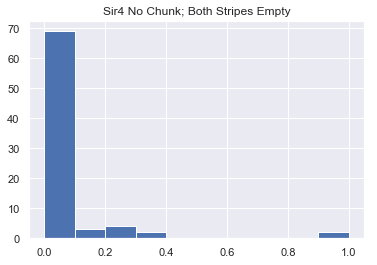

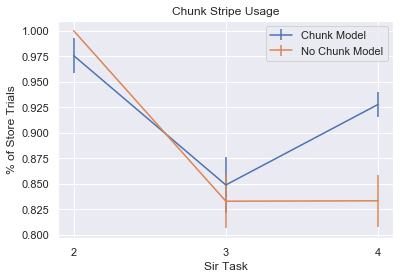

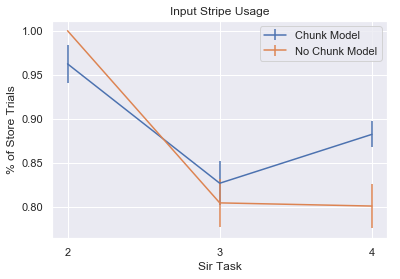

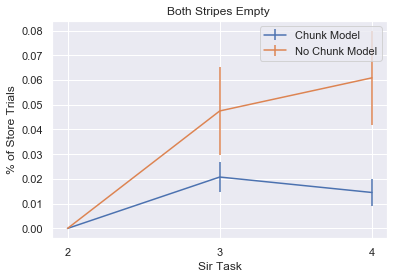

In [78]:
# item = 2
b6d16chunkmodels_empty = []
b6d16chunkmodels_empty_std = []
b6d16nochunkmodels_empty = []
b6d16nochunkmodels_empty_std = []

b6d16chunk_used_chunkmodels = []
b6d16chunk_used_chunkmodels_std = []
b6d16chunk_used_nochunkmodels = []
b6d16chunk_used_nochunkmodels_std = []

b6d16input_used_chunkmodels = []
b6d16input_used_chunkmodels_std = []
b6d16input_used_nochunkmodels = []
b6d16input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b6d16chunkmodels_empty.append(np.mean(empty_perc_all))
b6d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d16chunk_used_chunkmodels.append(np.mean(chk_all))
b6d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d16input_used_chunkmodels.append(np.mean(inp_all))
b6d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])

b6d16chunkmodels_empty.append(np.mean(empty_perc_all))
b6d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d16chunk_used_chunkmodels.append(np.mean(chk_all))
b6d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d16input_used_chunkmodels.append(np.mean(inp_all))
b6d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
b6d16chunkmodels_empty.append(np.mean(empty_perc_all))
b6d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d16chunk_used_chunkmodels.append(np.mean(chk_all))
b6d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d16input_used_chunkmodels.append(np.mean(inp_all))
b6d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
b6d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d16input_used_nochunkmodels.append(np.mean(inp_all))
b6d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
b6d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d16input_used_nochunkmodels.append(np.mean(inp_all))
b6d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
b6d16nochunkmodels_empty.append(np.mean(empty_perc_all))
b6d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b6d16chunk_used_nochunkmodels.append(np.mean(chk_all))
b6d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b6d16input_used_nochunkmodels.append(np.mean(inp_all))
b6d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],b6d16chunk_used_chunkmodels,yerr = b6d16chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b6d16chunk_used_nochunkmodels,yerr = b6d16chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b6d16input_used_chunkmodels, yerr = b6d16input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b6d16input_used_nochunkmodels,yerr = b6d16input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b6d16chunkmodels_empty,yerr = b6d16chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b6d16nochunkmodels_empty, yerr = b6d16nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

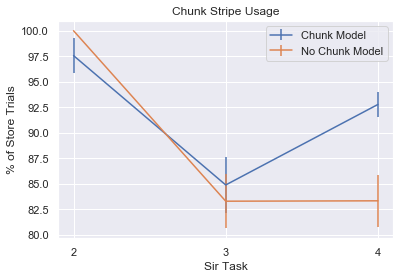

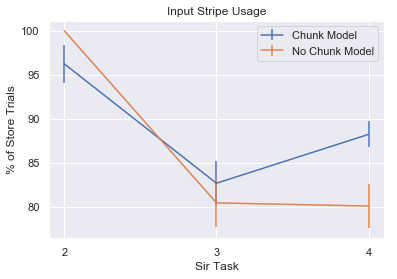

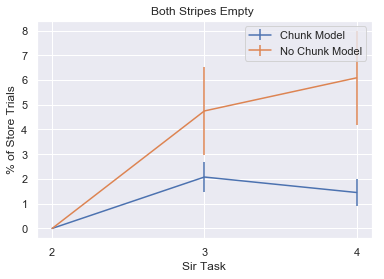

In [110]:
plt.errorbar([2,3,4],100*np.array(b6d16chunk_used_chunkmodels),yerr = 100*np.array(b6d16chunk_used_chunkmodels_std), label='Chunk Model')
plt.errorbar([2,3,4],100*np.array(b6d16chunk_used_nochunkmodels),yerr = 100*np.array(b6d16chunk_used_nochunkmodels_std), label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],100*np.array(b6d16input_used_chunkmodels), yerr = 100*np.array(b6d16input_used_chunkmodels_std), label='Chunk Model')
plt.errorbar([2,3,4],100*np.array(b6d16input_used_nochunkmodels),yerr = 100*np.array(b6d16input_used_nochunkmodels_std), label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],100*np.array(b6d16chunkmodels_empty),yerr = 100*np.array(b6d16chunkmodels_empty_std),label='Chunk Model')
plt.errorbar([2,3,4],100*np.array(b6d16nochunkmodels_empty), yerr = 100*np.array(b6d16nochunkmodels_empty_std), label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

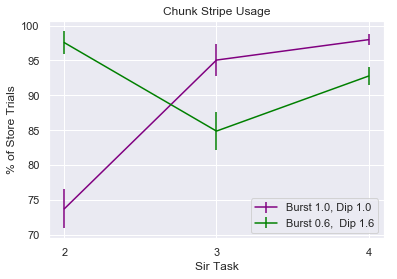

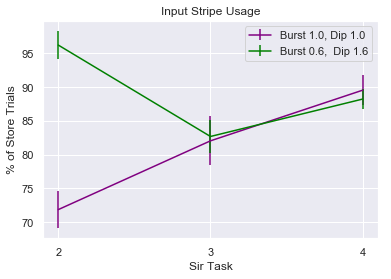

In [112]:
plt.errorbar([2,3,4],100*np.array(chunk_used_chunkmodels),yerr = 100*np.array(chunk_used_chunkmodels_std), label='Burst 1.0, Dip 1.0', color = 'purple')
plt.errorbar([2,3,4],100*np.array(b6d16chunk_used_chunkmodels),yerr = 100*np.array(b6d16chunk_used_chunkmodels_std), label='Burst 0.6,  Dip 1.6', color = 'green')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],100*np.array(input_used_chunkmodels),yerr = 100*np.array(input_used_chunkmodels_std), label='Burst 1.0, Dip 1.0', color = 'purple')
plt.errorbar([2,3,4],100*np.array(b6d16input_used_chunkmodels),yerr = 100*np.array(b6d16input_used_chunkmodels_std), label='Burst 0.6,  Dip 1.6', color = 'green')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


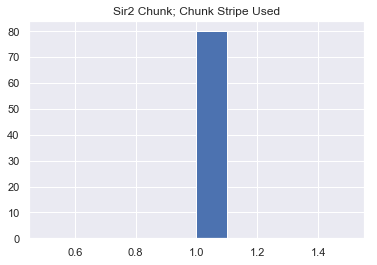

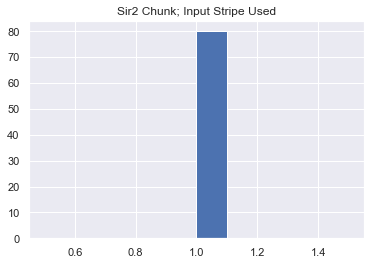

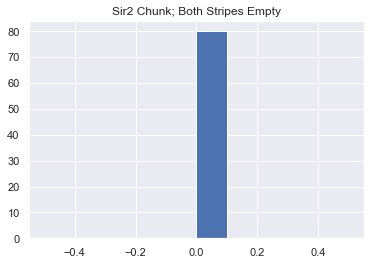

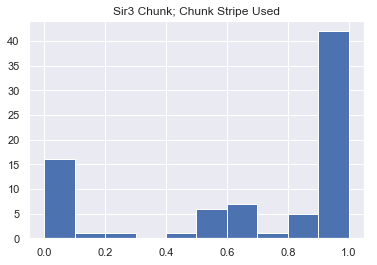

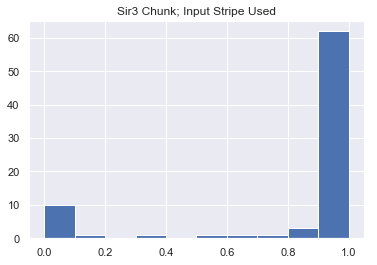

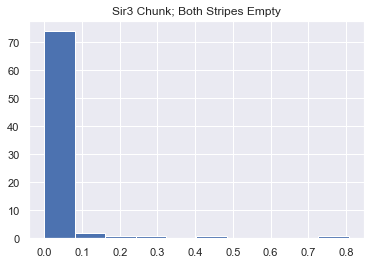

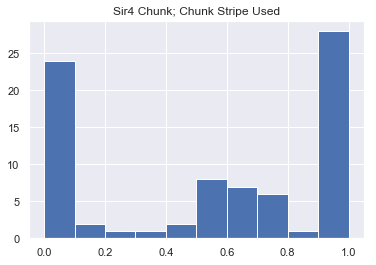

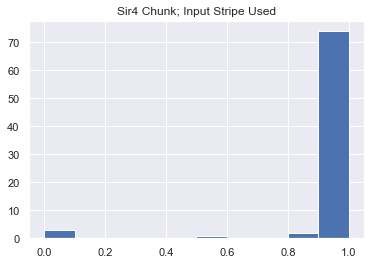

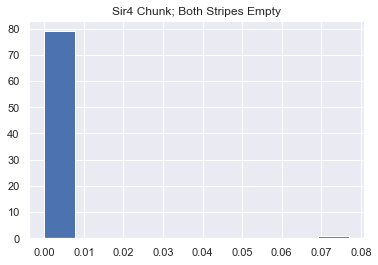

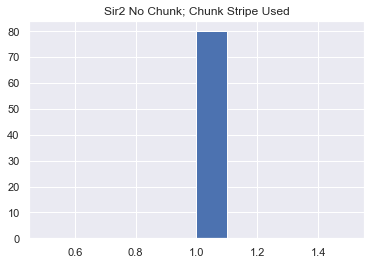

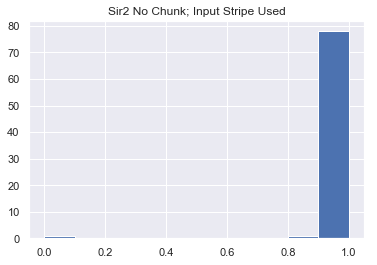

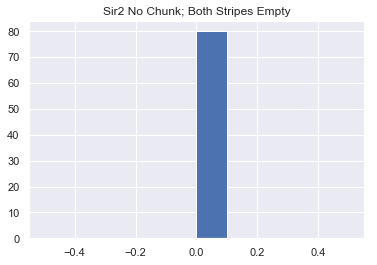

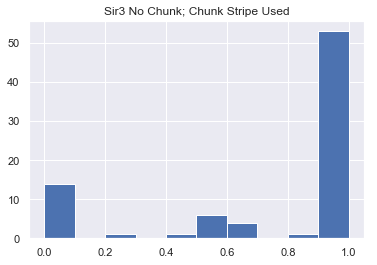

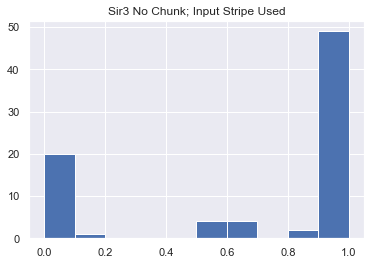

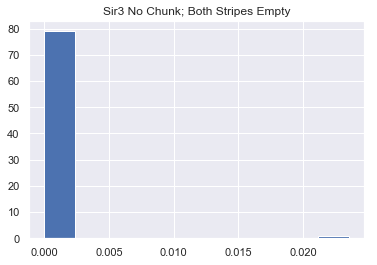

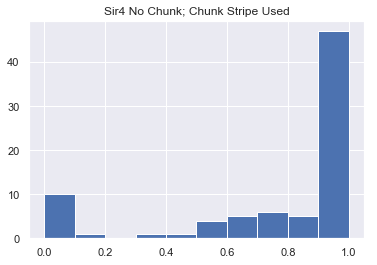

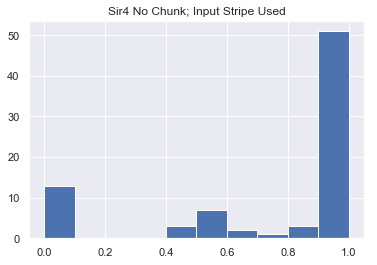

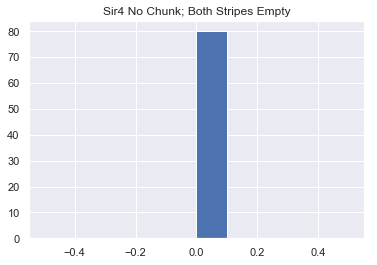

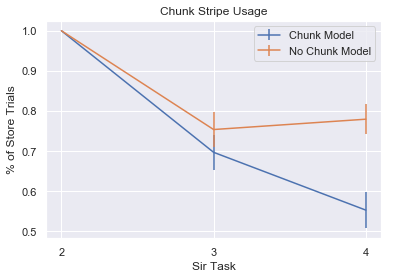

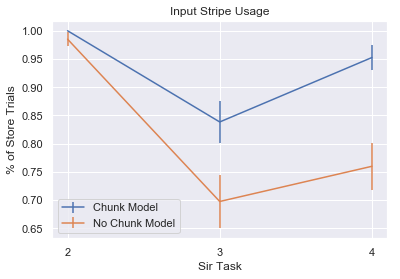

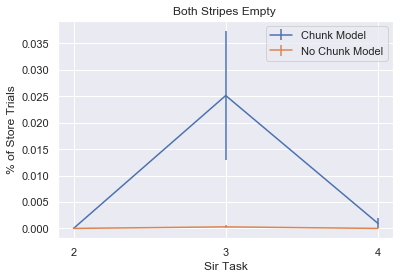

In [79]:
# item = 2
b1d6chunkmodels_empty = []
b1d6chunkmodels_empty_std = []
b1d6nochunkmodels_empty = []
b1d6nochunkmodels_empty_std = []

b1d6chunk_used_chunkmodels = []
b1d6chunk_used_chunkmodels_std = []
b1d6chunk_used_nochunkmodels = []
b1d6chunk_used_nochunkmodels_std = []

b1d6input_used_chunkmodels = []
b1d6input_used_chunkmodels_std = []
b1d6input_used_nochunkmodels = []
b1d6input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [2])

b1d6chunkmodels_empty.append(np.mean(empty_perc_all))
b1d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b1d6chunk_used_chunkmodels.append(np.mean(chk_all))
b1d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b1d6input_used_chunkmodels.append(np.mean(inp_all))
b1d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [3])

b1d6chunkmodels_empty.append(np.mean(empty_perc_all))
b1d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b1d6chunk_used_chunkmodels.append(np.mean(chk_all))
b1d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b1d6input_used_chunkmodels.append(np.mean(inp_all))
b1d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [4])
b1d6chunkmodels_empty.append(np.mean(empty_perc_all))
b1d6chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b1d6chunk_used_chunkmodels.append(np.mean(chk_all))
b1d6chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b1d6input_used_chunkmodels.append(np.mean(inp_all))
b1d6input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [2])
b1d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b1d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b1d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b1d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b1d6input_used_nochunkmodels.append(np.mean(inp_all))
b1d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [3])
b1d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b1d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b1d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b1d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b1d6input_used_nochunkmodels.append(np.mean(inp_all))
b1d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [4])
b1d6nochunkmodels_empty.append(np.mean(empty_perc_all))
b1d6nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
b1d6chunk_used_nochunkmodels.append(np.mean(chk_all))
b1d6chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
b1d6input_used_nochunkmodels.append(np.mean(inp_all))
b1d6input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],b1d6chunk_used_chunkmodels,yerr = b1d6chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b1d6chunk_used_nochunkmodels,yerr = b1d6chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b1d6input_used_chunkmodels, yerr = b1d6input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],b1d6input_used_nochunkmodels,yerr = b1d6input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],b1d6chunkmodels_empty,yerr = b1d6chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],b1d6nochunkmodels_empty, yerr = b1d6nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


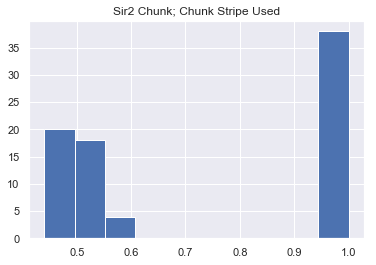

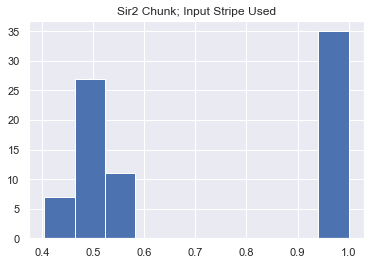

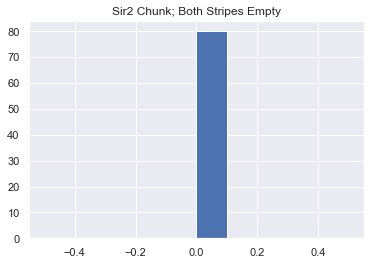

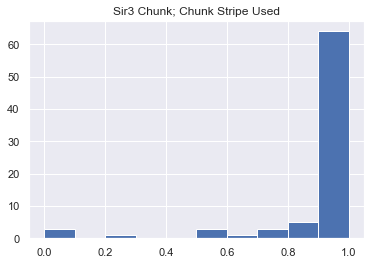

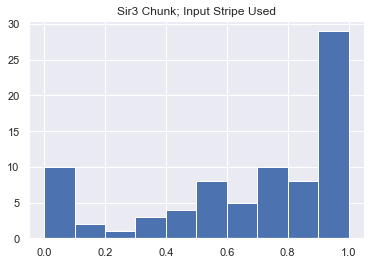

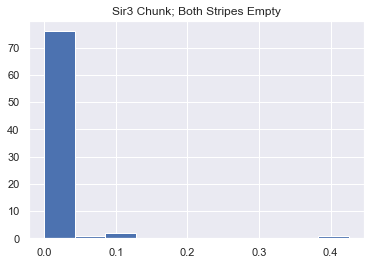

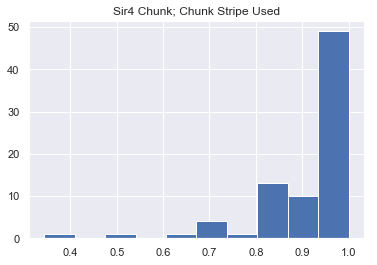

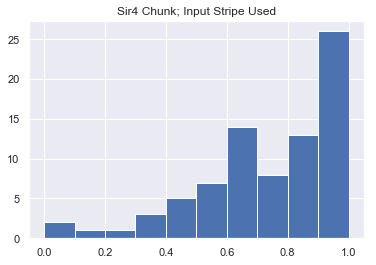

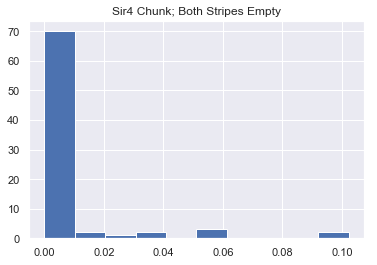

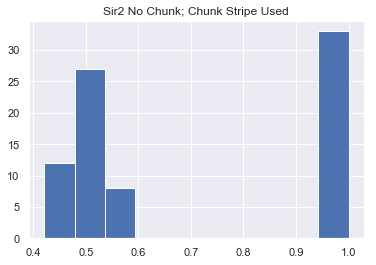

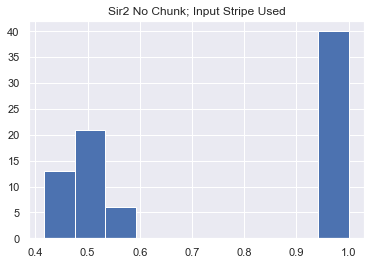

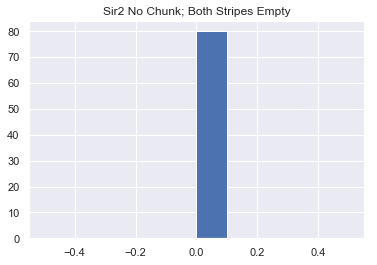

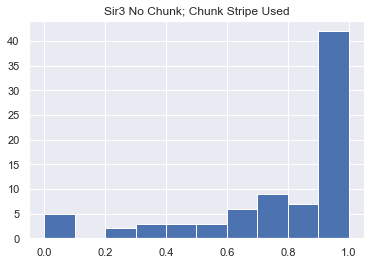

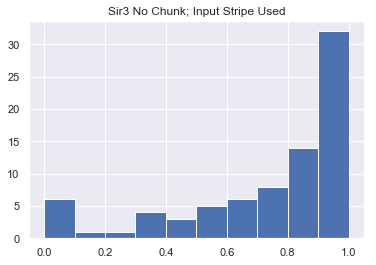

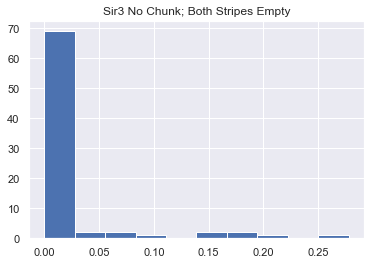

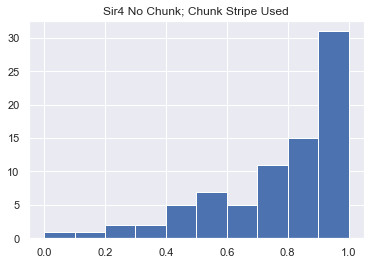

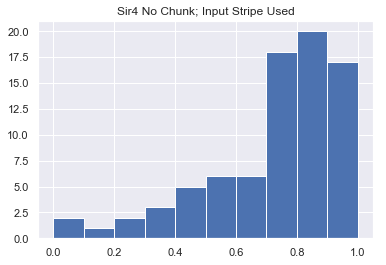

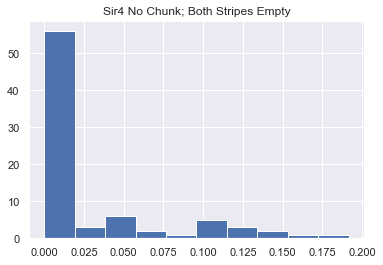

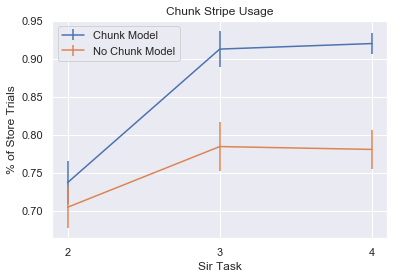

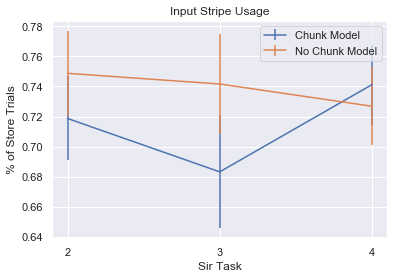

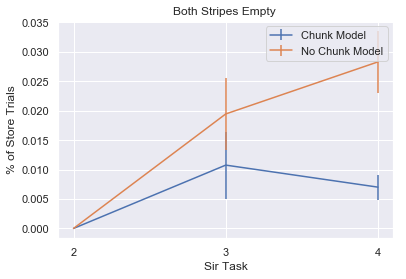

In [74]:
# item = 2
pchunkmodels_empty = []
pchunkmodels_empty_std = []
pnochunkmodels_empty = []
pnochunkmodels_empty_std = []

pchunk_used_chunkmodels = []
pchunk_used_chunkmodels_std = []
pchunk_used_nochunkmodels = []
pchunk_used_nochunkmodels_std = []

pinput_used_chunkmodels = []
pinput_used_chunkmodels_std = []
pinput_used_nochunkmodels = []
pinput_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1])

pchunkmodels_empty.append(np.mean(empty_perc_all))
pchunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pchunk_used_chunkmodels.append(np.mean(chk_all))
pchunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pinput_used_chunkmodels.append(np.mean(inp_all))
pinput_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1,2])
pchunkmodels_empty.append(np.mean(empty_perc_all))
pchunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pchunk_used_chunkmodels.append(np.mean(chk_all))
pchunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pinput_used_chunkmodels.append(np.mean(inp_all))
pinput_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1,2,3])
pchunkmodels_empty.append(np.mean(empty_perc_all))
pchunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pchunk_used_chunkmodels.append(np.mean(chk_all))
pchunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pinput_used_chunkmodels.append(np.mean(inp_all))
pinput_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1])
pnochunkmodels_empty.append(np.mean(empty_perc_all))
pnochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pchunk_used_nochunkmodels.append(np.mean(chk_all))
pchunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pinput_used_nochunkmodels.append(np.mean(inp_all))
pinput_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1,2])
pnochunkmodels_empty.append(np.mean(empty_perc_all))
pnochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pchunk_used_nochunkmodels.append(np.mean(chk_all))
pchunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pinput_used_nochunkmodels.append(np.mean(inp_all))
pinput_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1,2,3])
pnochunkmodels_empty.append(np.mean(empty_perc_all))
pnochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pchunk_used_nochunkmodels.append(np.mean(chk_all))
pchunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pinput_used_nochunkmodels.append(np.mean(inp_all))
pinput_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],pchunk_used_chunkmodels,yerr = pchunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],pchunk_used_nochunkmodels,yerr = pchunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],pinput_used_chunkmodels, yerr = pinput_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],pinput_used_nochunkmodels,yerr = pinput_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],pchunkmodels_empty,yerr = pchunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],pnochunkmodels_empty, yerr = pnochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


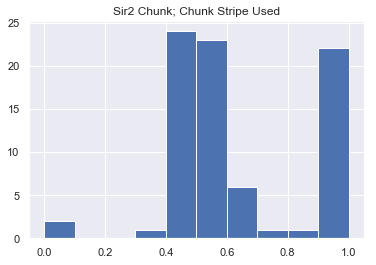

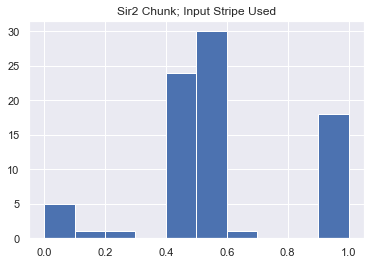

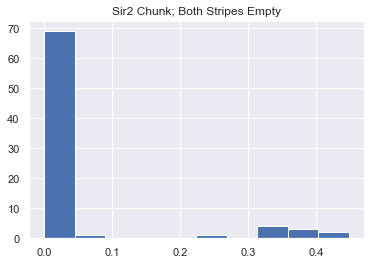

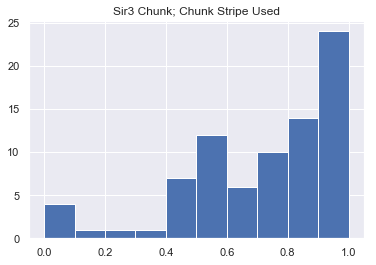

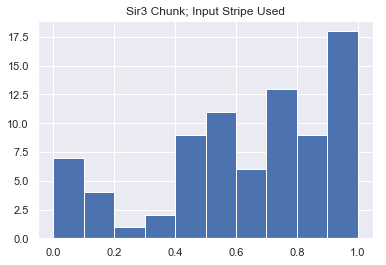

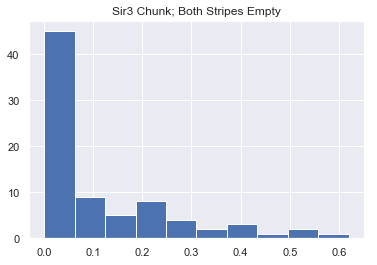

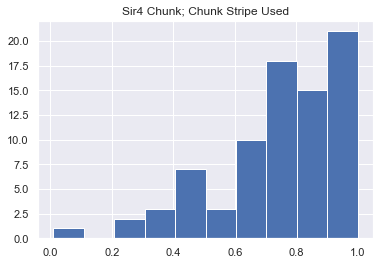

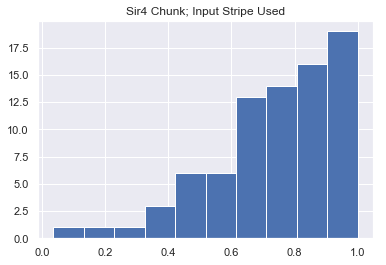

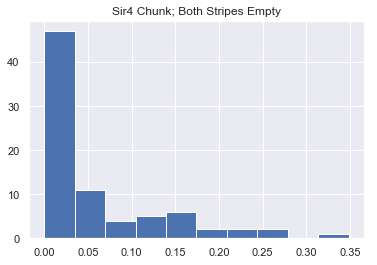

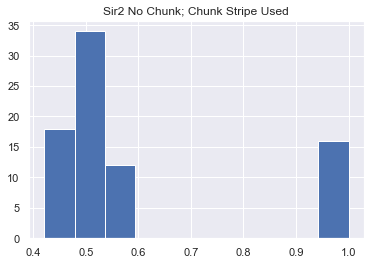

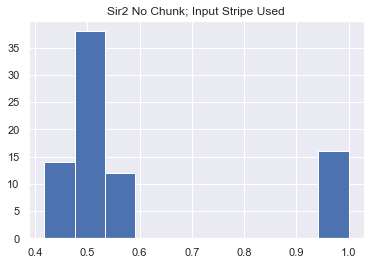

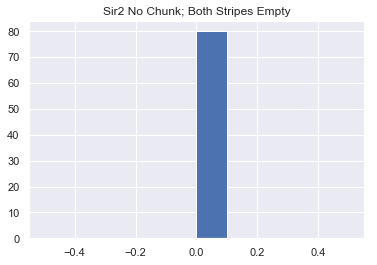

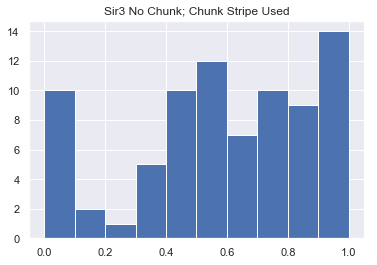

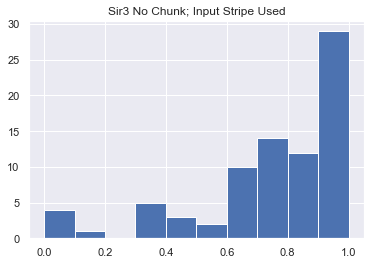

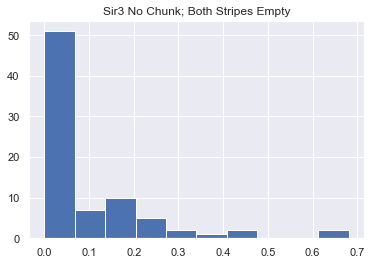

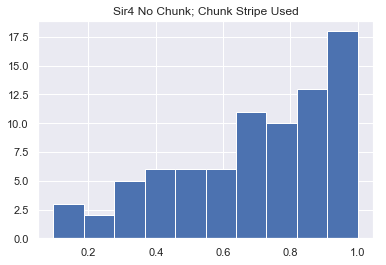

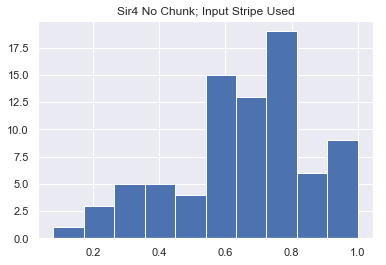

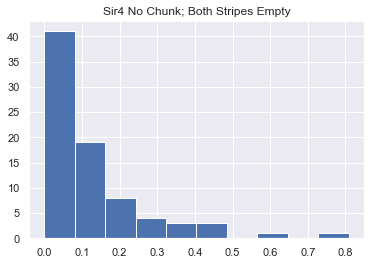

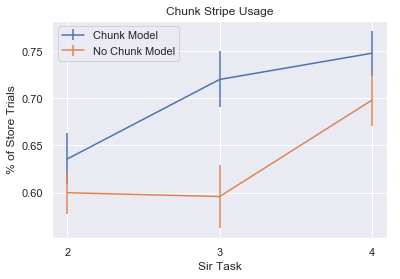

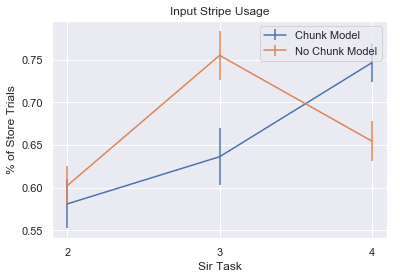

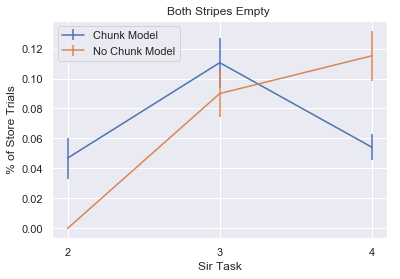

In [75]:
# item = 2
pb4d16chunkmodels_empty = []
pb4d16chunkmodels_empty_std = []
pb4d16nochunkmodels_empty = []
pb4d16nochunkmodels_empty_std = []

pb4d16chunk_used_chunkmodels = []
pb4d16chunk_used_chunkmodels_std = []
pb4d16chunk_used_nochunkmodels = []
pb4d16chunk_used_nochunkmodels_std = []

pb4d16input_used_chunkmodels = []
pb4d16input_used_chunkmodels_std = []
pb4d16input_used_nochunkmodels = []
pb4d16input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1])

pb4d16chunkmodels_empty.append(np.mean(empty_perc_all))
pb4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb4d16chunk_used_chunkmodels.append(np.mean(chk_all))
pb4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb4d16input_used_chunkmodels.append(np.mean(inp_all))
pb4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1,2])

pb4d16chunkmodels_empty.append(np.mean(empty_perc_all))
pb4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb4d16chunk_used_chunkmodels.append(np.mean(chk_all))
pb4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb4d16input_used_chunkmodels.append(np.mean(inp_all))
pb4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1,2,3])
pb4d16chunkmodels_empty.append(np.mean(empty_perc_all))
pb4d16chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb4d16chunk_used_chunkmodels.append(np.mean(chk_all))
pb4d16chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb4d16input_used_chunkmodels.append(np.mean(inp_all))
pb4d16input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1])
pb4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
pb4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
pb4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb4d16input_used_nochunkmodels.append(np.mean(inp_all))
pb4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1,2])
pb4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
pb4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
pb4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb4d16input_used_nochunkmodels.append(np.mean(inp_all))
pb4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1,2,3])
pb4d16nochunkmodels_empty.append(np.mean(empty_perc_all))
pb4d16nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb4d16chunk_used_nochunkmodels.append(np.mean(chk_all))
pb4d16chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb4d16input_used_nochunkmodels.append(np.mean(inp_all))
pb4d16input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],pb4d16chunk_used_chunkmodels,yerr = pb4d16chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],pb4d16chunk_used_nochunkmodels,yerr = pb4d16chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],pb4d16input_used_chunkmodels, yerr = pb4d16input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],pb4d16input_used_nochunkmodels,yerr = pb4d16input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],pb4d16chunkmodels_empty,yerr = pb4d16chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],pb4d16nochunkmodels_empty, yerr = pb4d16nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


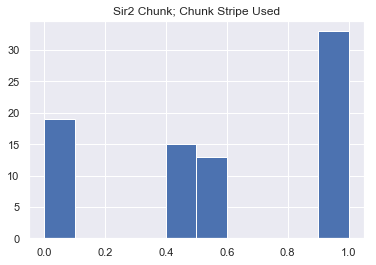

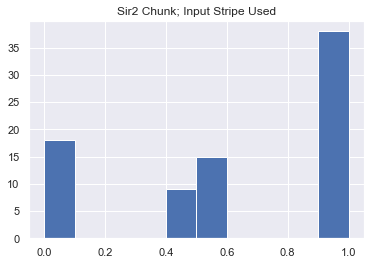

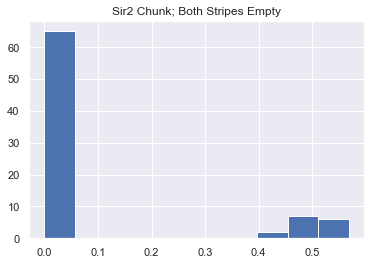

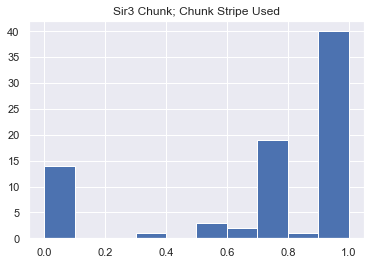

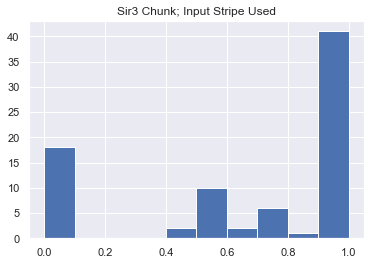

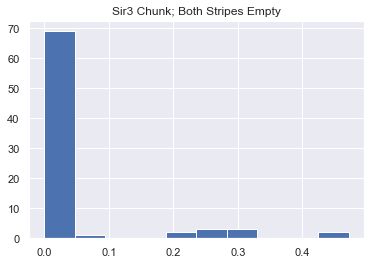

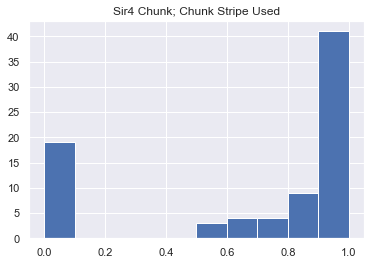

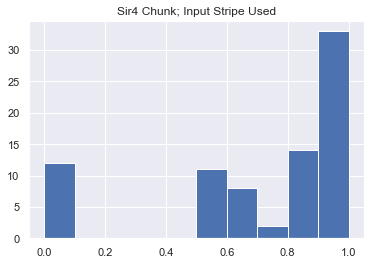

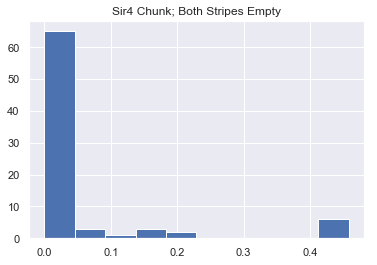

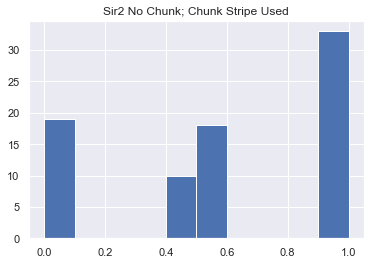

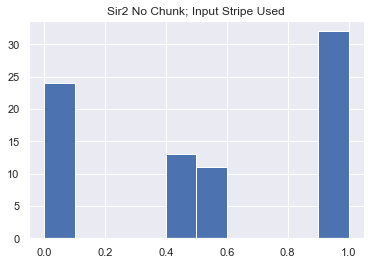

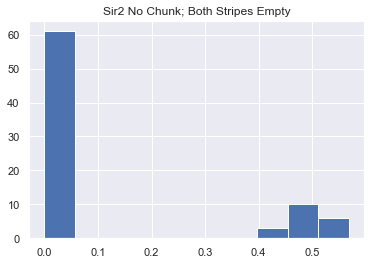

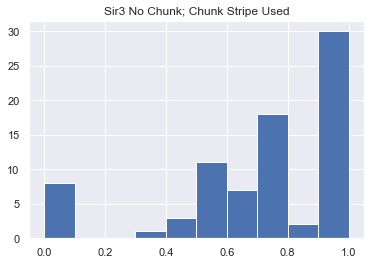

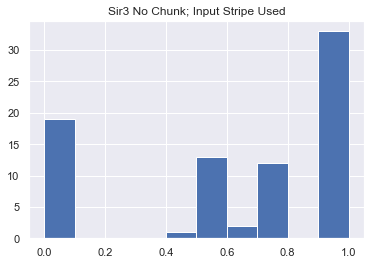

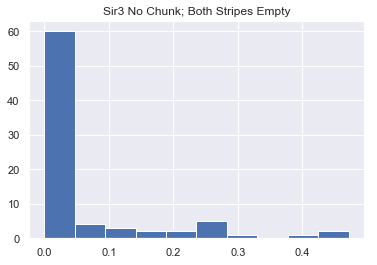

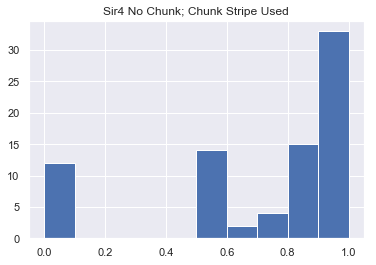

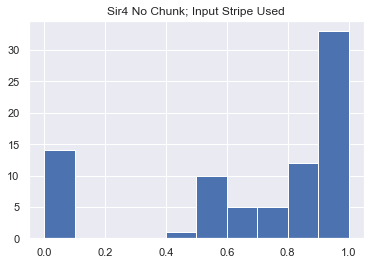

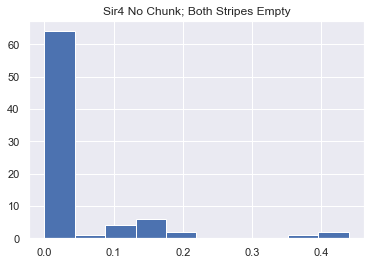

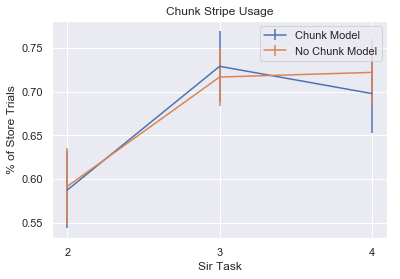

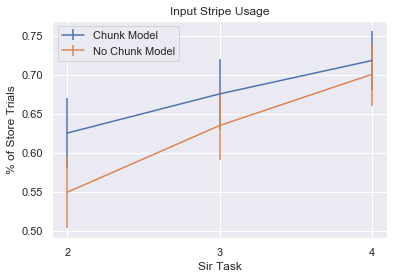

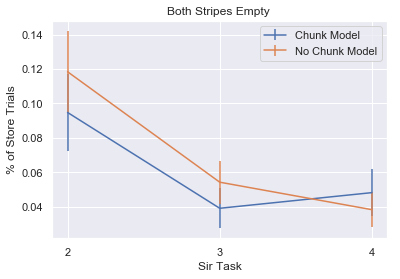

In [76]:

pb16d4chunkmodels_empty = []
pb16d4chunkmodels_empty_std = []
pb16d4nochunkmodels_empty = []
pb16d4nochunkmodels_empty_std = []

pb16d4chunk_used_chunkmodels = []
pb16d4chunk_used_chunkmodels_std = []
pb16d4chunk_used_nochunkmodels = []
pb16d4chunk_used_nochunkmodels_std = []

pb16d4input_used_chunkmodels = []
pb16d4input_used_chunkmodels_std = []
pb16d4input_used_nochunkmodels = []
pb16d4input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1])

pb16d4chunkmodels_empty.append(np.mean(empty_perc_all))
pb16d4chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb16d4chunk_used_chunkmodels.append(np.mean(chk_all))
pb16d4chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb16d4input_used_chunkmodels.append(np.mean(inp_all))
pb16d4input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1,2])

pb16d4chunkmodels_empty.append(np.mean(empty_perc_all))
pb16d4chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb16d4chunk_used_chunkmodels.append(np.mean(chk_all))
pb16d4chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb16d4input_used_chunkmodels.append(np.mean(inp_all))
pb16d4input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = [1,2,3])
pb16d4chunkmodels_empty.append(np.mean(empty_perc_all))
pb16d4chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb16d4chunk_used_chunkmodels.append(np.mean(chk_all))
pb16d4chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb16d4input_used_chunkmodels.append(np.mean(inp_all))
pb16d4input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1])
pb16d4nochunkmodels_empty.append(np.mean(empty_perc_all))
pb16d4nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb16d4chunk_used_nochunkmodels.append(np.mean(chk_all))
pb16d4chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb16d4input_used_nochunkmodels.append(np.mean(inp_all))
pb16d4input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1,2])
pb16d4nochunkmodels_empty.append(np.mean(empty_perc_all))
pb16d4nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb16d4chunk_used_nochunkmodels.append(np.mean(chk_all))
pb16d4chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb16d4input_used_nochunkmodels.append(np.mean(inp_all))
pb16d4input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = [1,2,3])
pb16d4nochunkmodels_empty.append(np.mean(empty_perc_all))
pb16d4nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
pb16d4chunk_used_nochunkmodels.append(np.mean(chk_all))
pb16d4chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
pb16d4input_used_nochunkmodels.append(np.mean(inp_all))
pb16d4input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],pb16d4chunk_used_chunkmodels,yerr = pb16d4chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],pb16d4chunk_used_nochunkmodels,yerr = pb16d4chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],pb16d4input_used_chunkmodels, yerr = pb16d4input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],pb16d4input_used_nochunkmodels,yerr = pb16d4input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],pb16d4chunkmodels_empty,yerr = pb16d4chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],pb16d4nochunkmodels_empty, yerr = pb16d4nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

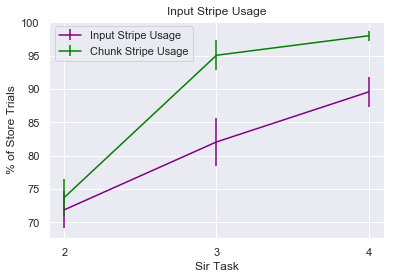

In [108]:
plt.figure()
plt.errorbar([2,3,4],np.array(input_used_chunkmodels)*100,yerr = np.array(input_used_chunkmodels_std)*100,label='Input Stripe Usage', color = 'purple')
plt.errorbar([2,3,4],np.array(chunk_used_chunkmodels)*100,yerr = np.array(chunk_used_chunkmodels_std)*100,label='Chunk Stripe Usage', color = 'green')
plt.xticks([2,3,4])
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.legend()
plt.show()

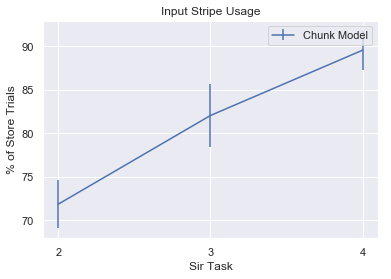

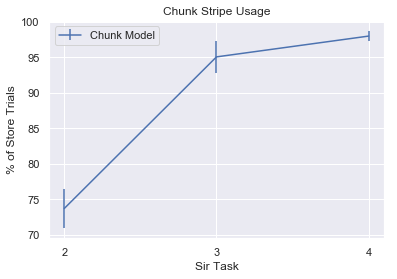

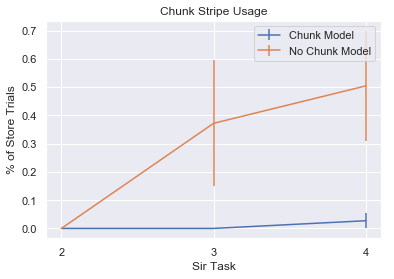

In [109]:
plt.errorbar([2,3,4],np.array(input_used_chunkmodels)*100,yerr = np.array(input_used_chunkmodels_std)*100,label='Chunk Model')
#plt.errorbar([2,3,4],np.array(input_used_nochunkmodels)*100,yerr = np.array(input_used_nochunkmodels_std)*100,label='No Chunk Model')
plt.xticks([2,3,4])
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.legend()
plt.show()



plt.figure()
plt.errorbar([2,3,4],np.array(chunk_used_chunkmodels)*100,yerr = np.array(chunk_used_chunkmodels_std)*100,label='Chunk Model')

#plt.errorbar([2,3,4],np.array(chunk_used_nochunkmodels)*100,yerr = np.array(chunk_used_nochunkmodels_std)*100,label='No Chunk Model')

plt.xticks([2,3,4])
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.legend()
plt.show()

plt.figure()
plt.errorbar([2,3,4],np.array(chunkmodels_empty)*100,yerr = np.array(chunkmodels_empty_std)*100,label='Chunk Model')

plt.errorbar([2,3,4],np.array(nochunkmodels_empty)*100,yerr = np.array(nochunkmodels_empty_std)*100,label='No Chunk Model')

plt.xticks([2,3,4])
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.legend()
plt.show()

<ErrorbarContainer object of 3 artists>

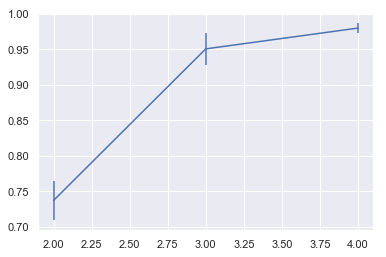

In [89]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std,label='Burst 1.0, Dip 1.0')

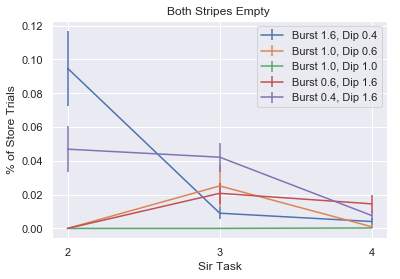

In [81]:
plt.errorbar([2,3,4],b16d4chunkmodels_empty,yerr = b16d4chunkmodels_empty_std,label='Burst 1.6, Dip 0.4')
plt.errorbar([2,3,4],b1d6chunkmodels_empty,yerr = b1d6chunkmodels_empty_std,label='Burst 1.0, Dip 0.6')
plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Burst 1.0, Dip 1.0')
plt.errorbar([2,3,4],b6d16chunkmodels_empty,yerr = b6d16chunkmodels_empty_std,label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],b4d16chunkmodels_empty,yerr = b4d16chunkmodels_empty_std,label='Burst 0.4, Dip 1.6')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

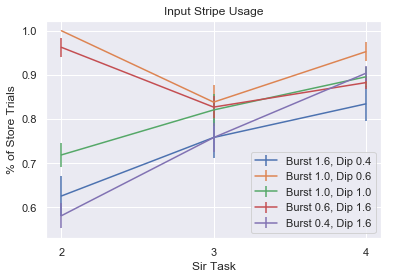

In [87]:
plt.errorbar([2,3,4],b16d4input_used_chunkmodels,yerr = b16d4input_used_chunkmodels_std,label='Burst 1.6, Dip 0.4')
plt.errorbar([2,3,4],b1d6input_used_chunkmodels,yerr = b1d6input_used_chunkmodels_std,label='Burst 1.0, Dip 0.6')
plt.errorbar([2,3,4],input_used_chunkmodels,yerr = input_used_chunkmodels_std,label='Burst 1.0, Dip 1.0')
plt.errorbar([2,3,4],b6d16input_used_chunkmodels,yerr = b6d16input_used_chunkmodels_std,label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],b4d16input_used_chunkmodels,yerr = b4d16input_used_chunkmodels_std,label='Burst 0.4, Dip 1.6')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

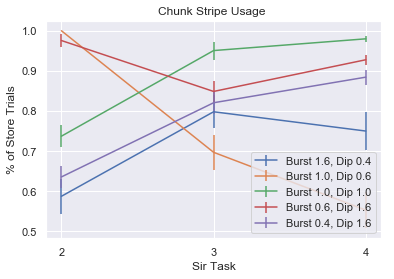

In [86]:
plt.errorbar([2,3,4],b16d4chunk_used_chunkmodels,yerr = b16d4chunk_used_chunkmodels_std,label='Burst 1.6, Dip 0.4')
plt.errorbar([2,3,4],b1d6chunk_used_chunkmodels,yerr = b1d6chunk_used_chunkmodels_std,label='Burst 1.0, Dip 0.6')
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std,label='Burst 1.0, Dip 1.0')
plt.errorbar([2,3,4],b6d16chunk_used_chunkmodels,yerr = b6d16chunk_used_chunkmodels_std,label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],b4d16chunk_used_chunkmodels,yerr = b4d16chunk_used_chunkmodels_std,label='Burst 0.4, Dip 1.6')

plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk


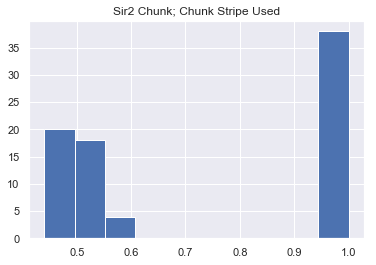

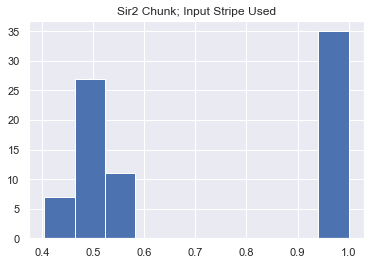

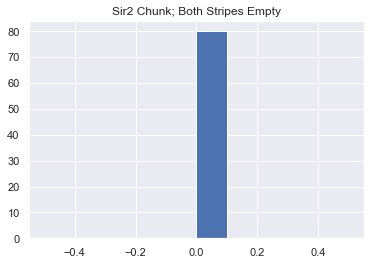

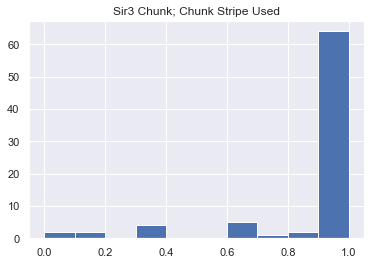

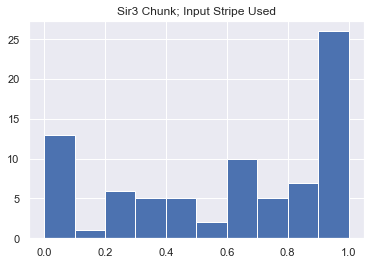

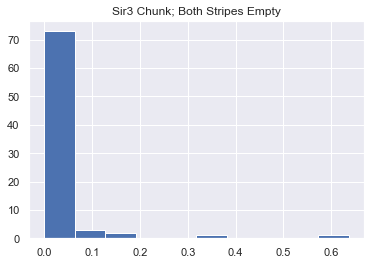

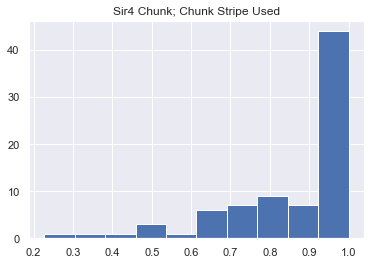

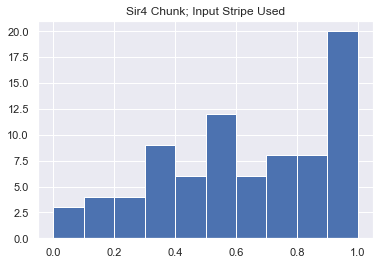

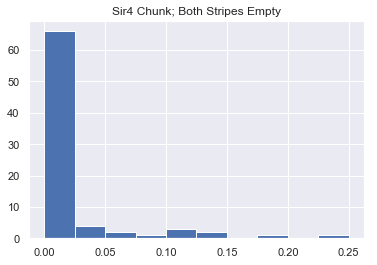

In [52]:
item = 1
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = item)

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = item)
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base,item = item)
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

sir2 no chunk
sir3 no chunk
sir4 no chunk


Text(0.5, 1.0, 'Sir4 No Chunk; Both Stripes Empty')

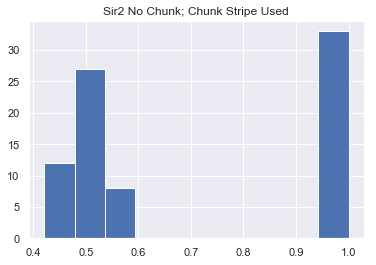

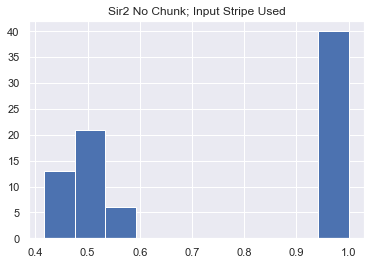

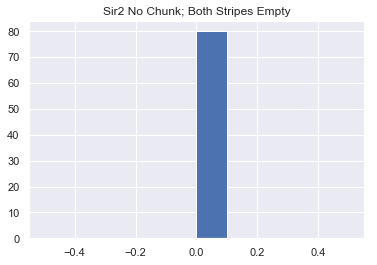

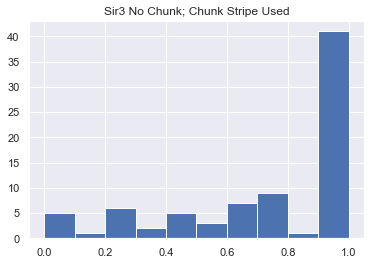

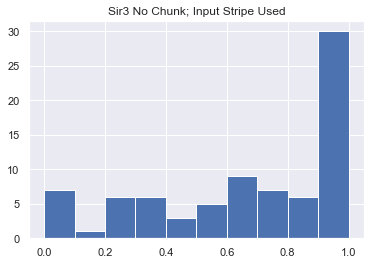

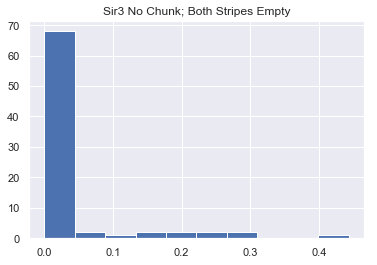

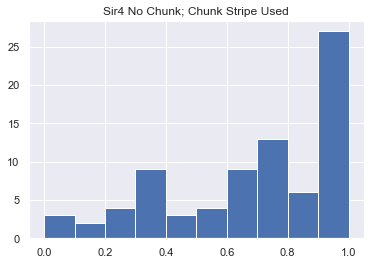

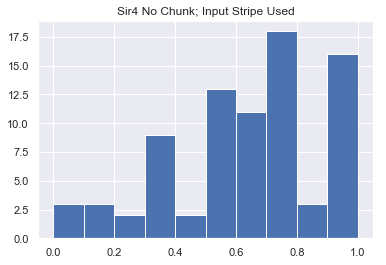

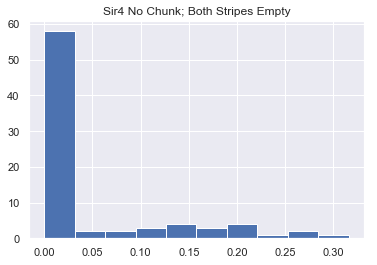

In [53]:
item = 1
print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = item)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = item)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base, item = item)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

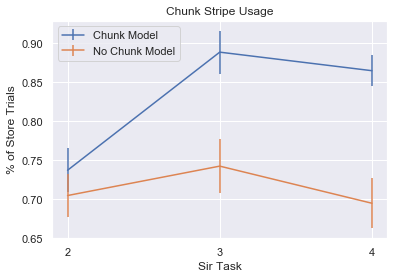

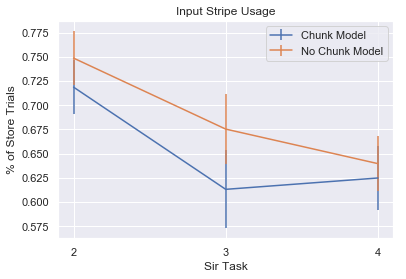

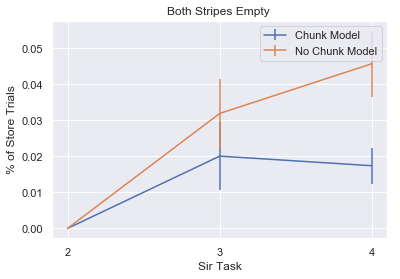

In [55]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [9]:
#trying to figure out the error when 1 stripe used vs. both stripes used. 
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df, err = get_df(base, geterr = True)
both_stripes_used, err_bothstripes, one_stripe_used, err_onestripe, zero_stripes_used, err_zerostripes = stripes_used_before_recall(df, err)

In [10]:
#trying to figure out the error when 1 stripe used vs. both stripes used. 
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df, err = get_df(base, geterr = True)
both_stripes_used_nochunk, err_bothstripes_nochunk, one_stripe_used_nochunk, err_onestripe_nochunk, zero_stripes_used_nochunk, err_zerostripes_nochunk = stripes_used_before_recall(df, err)

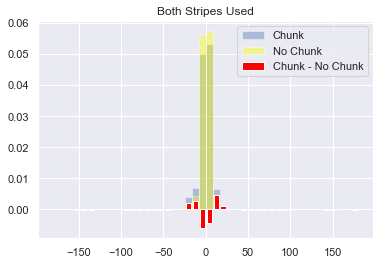

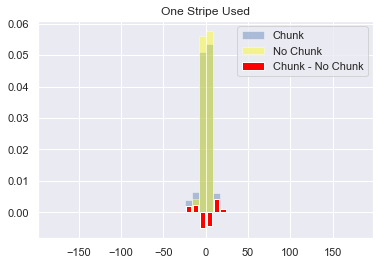

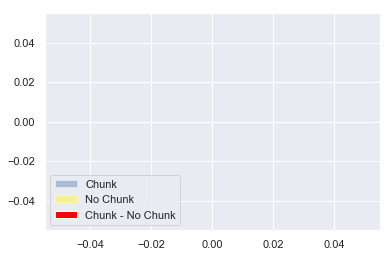

In [18]:
overlay_hist(err_bothstripes, err_bothstripes_nochunk, pl_density = True, title = 'Both Stripes Used')
overlay_hist(err_onestripe,err_onestripe_nochunk, pl_density = True, title = 'One Stripe Used')
overlay_hist(err_zerostripes,err_zerostripes_nochunk, pl_density = True)

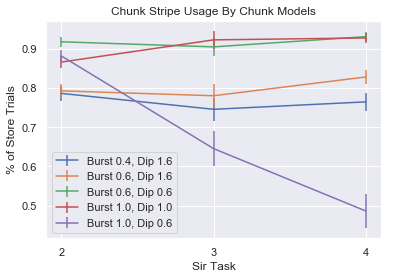

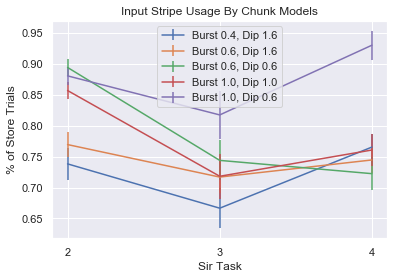

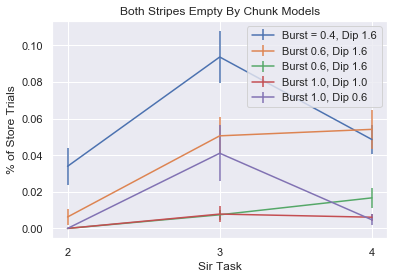

In [32]:

plt.figure()
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Burst 0.4, Dip 1.6')
plt.errorbar([2,3,4],newchunk_used_chunkmodels,yerr = newchunk_used_chunkmodels_std, label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],new3chunk_used_chunkmodels,yerr = new3chunk_used_chunkmodels_std, label='Burst 0.6, Dip 0.6')
plt.errorbar([2,3,4],chunk_used_goodchunkmodels,yerr = chunk_used_goodchunkmodels_std, label='Burst 1.0, Dip 1.0')
plt.errorbar([2,3,4],new2chunk_used_chunkmodels,yerr = new2chunk_used_chunkmodels_std, label='Burst 1.0, Dip 0.6')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage By Chunk Models')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Burst 0.4, Dip 1.6')
plt.errorbar([2,3,4],newinput_used_chunkmodels,yerr = newinput_used_chunkmodels_std, label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],new3input_used_chunkmodels,yerr = new3input_used_chunkmodels_std, label='Burst 0.6, Dip 0.6')
plt.errorbar([2,3,4],input_used_goodchunkmodels,yerr = input_used_goodchunkmodels_std, label='Burst 1.0, Dip 1.0')
plt.errorbar([2,3,4],new2input_used_chunkmodels,yerr = new2input_used_chunkmodels_std, label='Burst 1.0, Dip 0.6')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage By Chunk Models')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Burst = 0.4, Dip 1.6')
plt.errorbar([2,3,4],newchunkmodels_empty, yerr = newchunkmodels_empty_std, label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],new3chunkmodels_empty, yerr = new3chunkmodels_empty_std, label='Burst 0.6, Dip 1.6')
plt.errorbar([2,3,4],goodchunkmodels_empty, yerr = goodchunkmodels_empty_std, label='Burst 1.0, Dip 1.0')
plt.errorbar([2,3,4],new2chunkmodels_empty, yerr = new2chunkmodels_empty_std, label='Burst 1.0, Dip 0.6')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty By Chunk Models')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

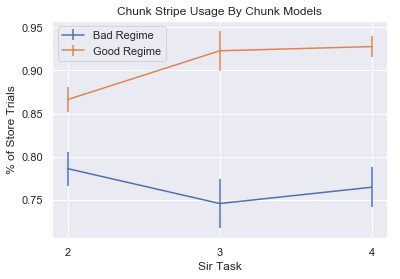

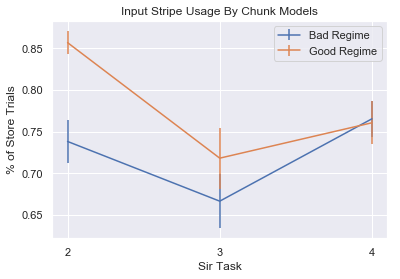

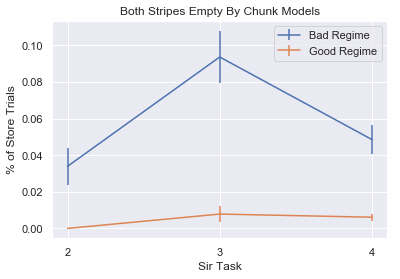

In [25]:

plt.figure()
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Bad Regime')
plt.errorbar([2,3,4],chunk_used_goodchunkmodels,yerr = chunk_used_goodchunkmodels_std, label='Good Regime')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage By Chunk Models')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Bad Regime')
plt.errorbar([2,3,4],input_used_goodchunkmodels,yerr = input_used_goodchunkmodels_std, label='Good Regime')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage By Chunk Models')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Bad Regime')
plt.errorbar([2,3,4],goodchunkmodels_empty, yerr = goodchunkmodels_empty_std, label='Good Regime')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty By Chunk Models')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


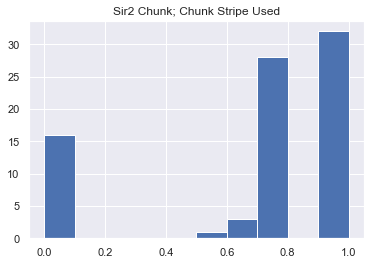

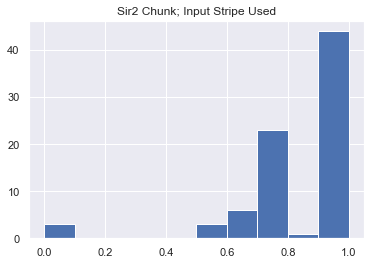

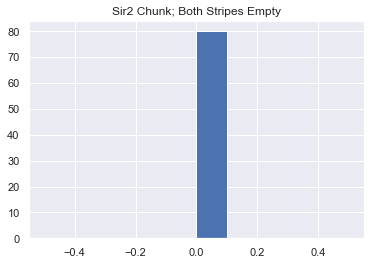

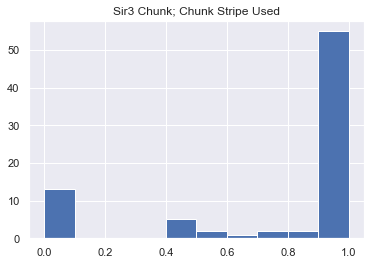

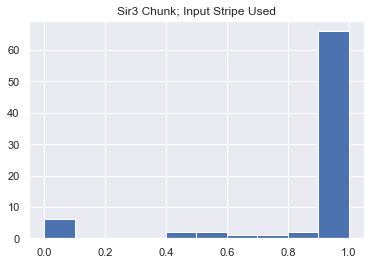

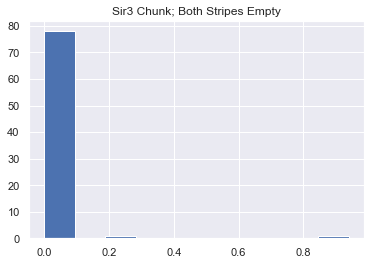

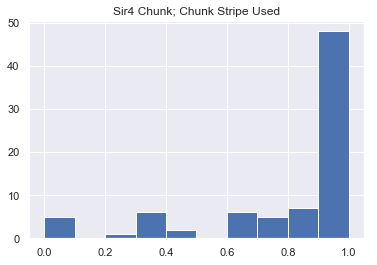

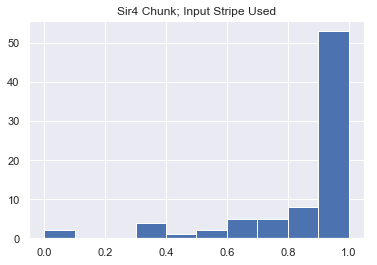

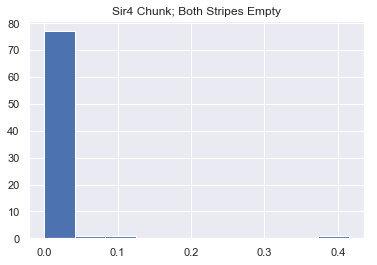

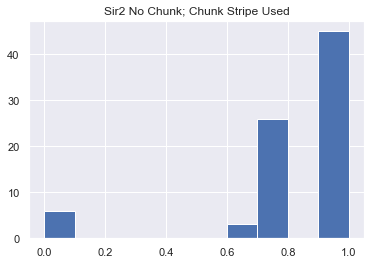

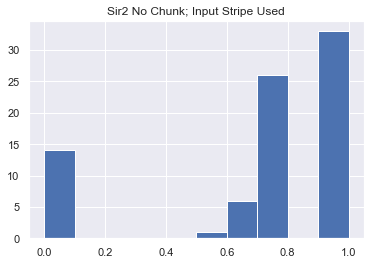

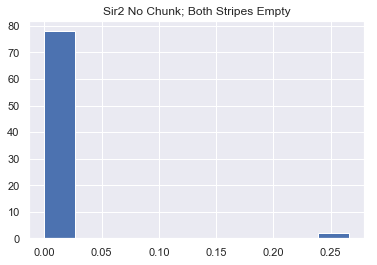

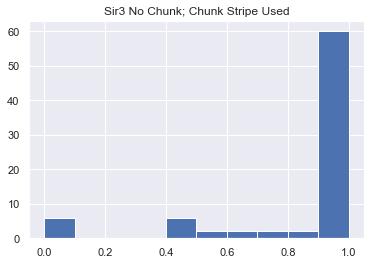

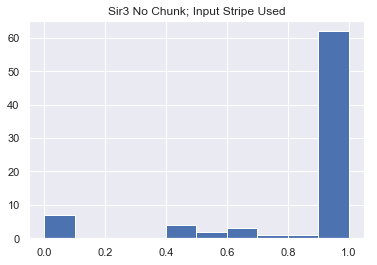

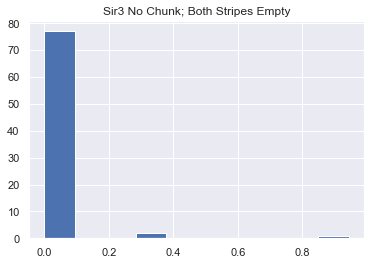

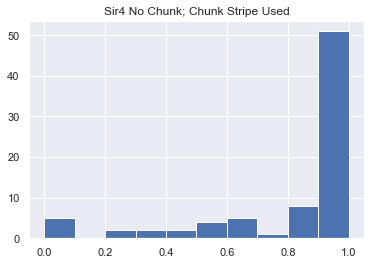

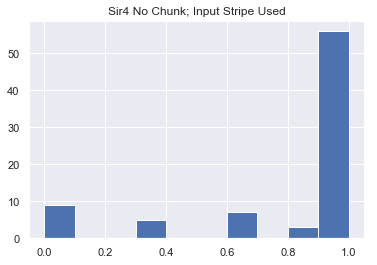

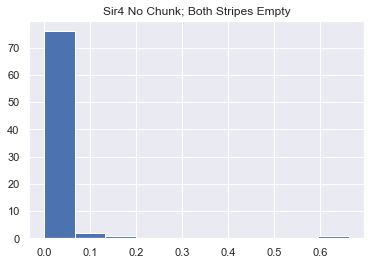

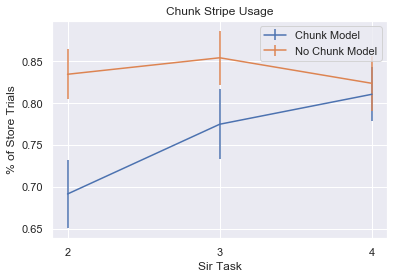

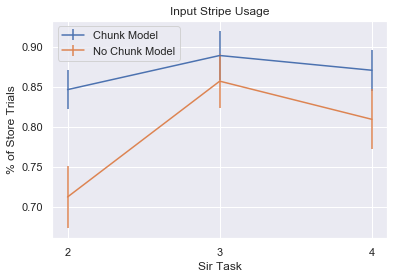

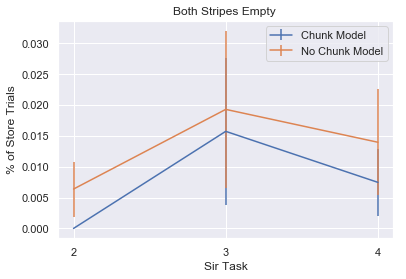

In [3]:
#Burst14, Dip 6
new2chunkmodels_empty = []
new2chunkmodels_empty_std = []
new2nochunkmodels_empty = []
new2nochunkmodels_empty_std = []

new2chunk_used_chunkmodels = []
new2chunk_used_chunkmodels_std = []
new2chunk_used_nochunkmodels = []
new2chunk_used_nochunkmodels_std = []

new2input_used_chunkmodels = []
new2input_used_chunkmodels_std = []
new2input_used_nochunkmodels = []
new2input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],new2chunk_used_chunkmodels,yerr = new2chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2chunk_used_nochunkmodels,yerr = new2chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2input_used_chunkmodels, yerr = new2input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2input_used_nochunkmodels,yerr = new2input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2chunkmodels_empty,yerr = new2chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],new2nochunkmodels_empty, yerr = new2nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


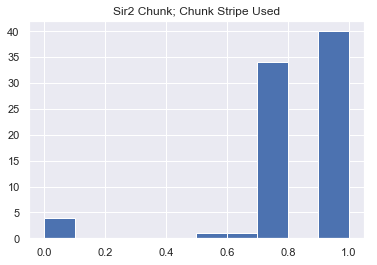

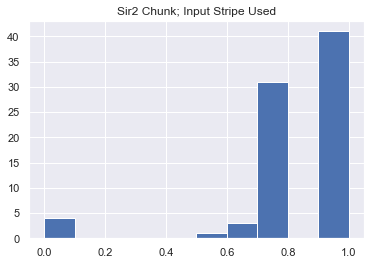

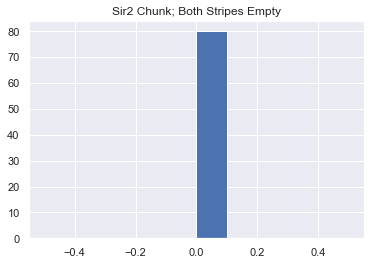

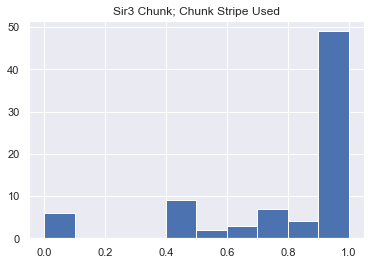

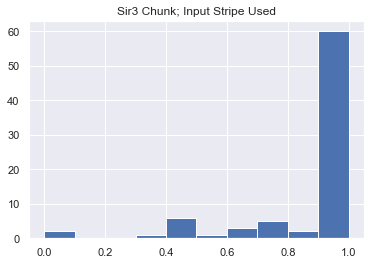

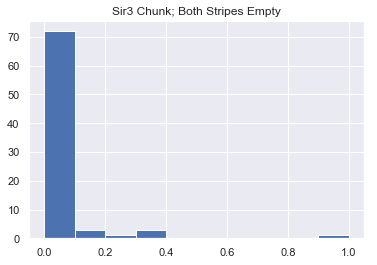

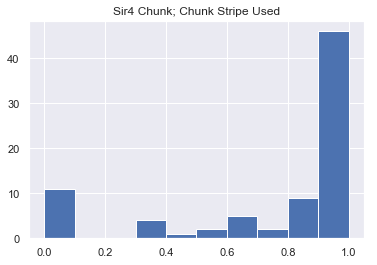

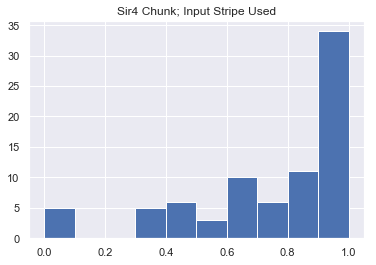

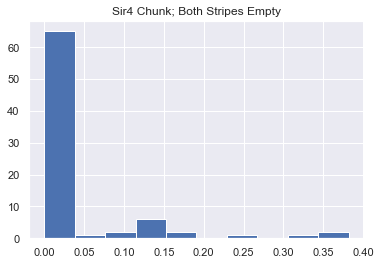

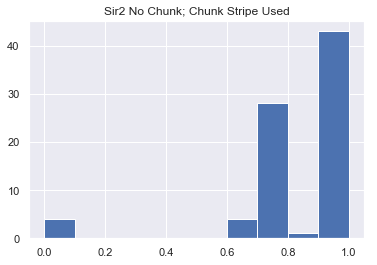

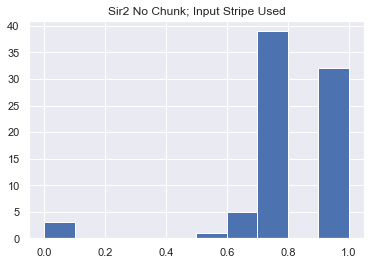

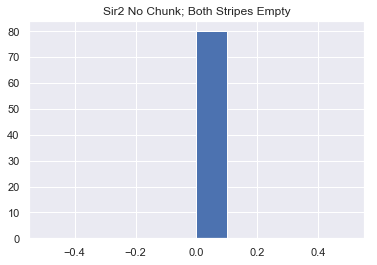

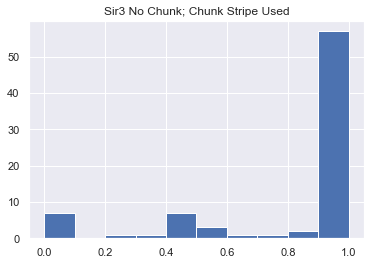

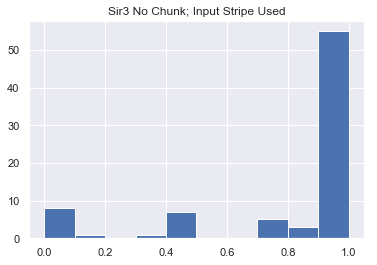

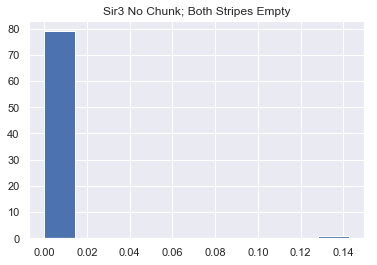

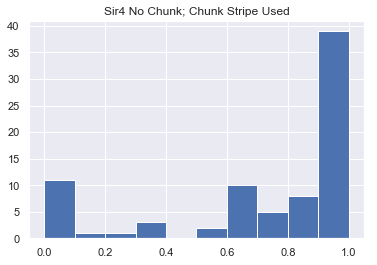

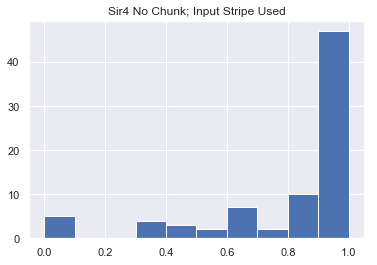

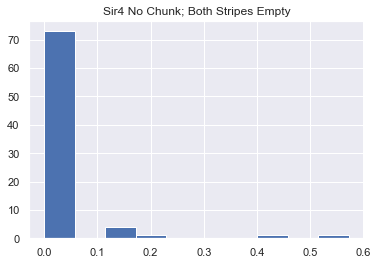

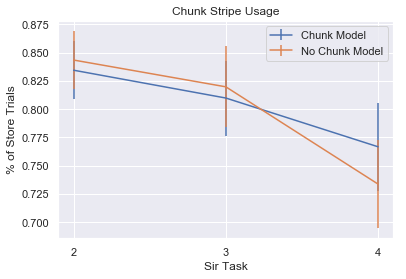

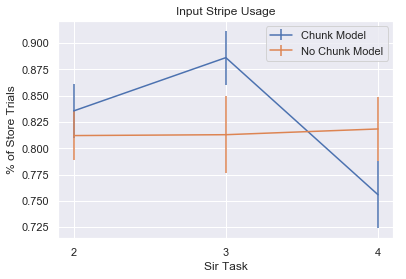

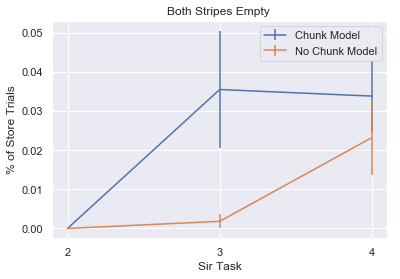

In [4]:
#Burst16, Dip 8
new2chunkmodels_empty = []
new2chunkmodels_empty_std = []
new2nochunkmodels_empty = []
new2nochunkmodels_empty_std = []

new2chunk_used_chunkmodels = []
new2chunk_used_chunkmodels_std = []
new2chunk_used_nochunkmodels = []
new2chunk_used_nochunkmodels_std = []

new2input_used_chunkmodels = []
new2input_used_chunkmodels_std = []
new2input_used_nochunkmodels = []
new2input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],new2chunk_used_chunkmodels,yerr = new2chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2chunk_used_nochunkmodels,yerr = new2chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2input_used_chunkmodels, yerr = new2input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2input_used_nochunkmodels,yerr = new2input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2chunkmodels_empty,yerr = new2chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],new2nochunkmodels_empty, yerr = new2nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


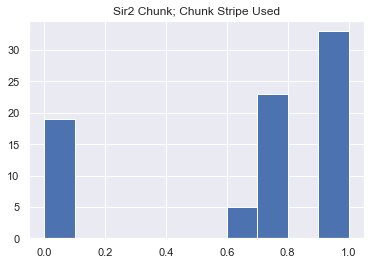

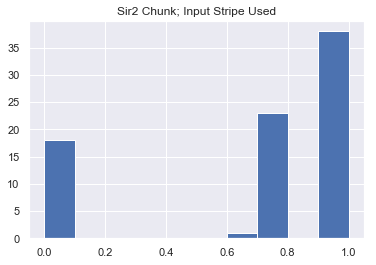

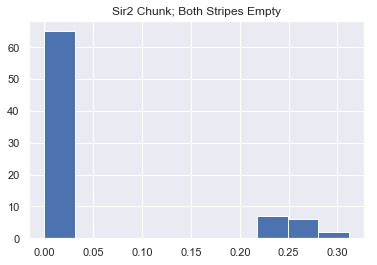

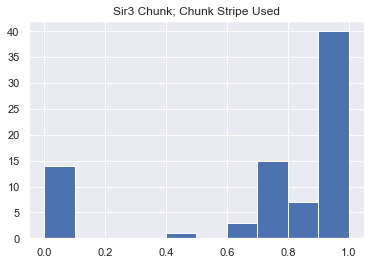

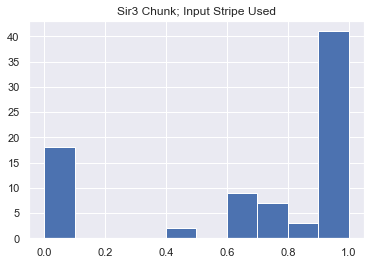

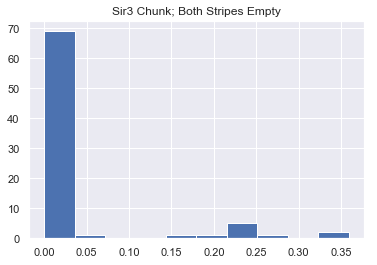

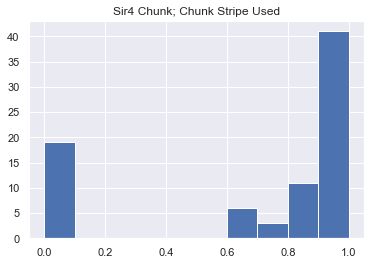

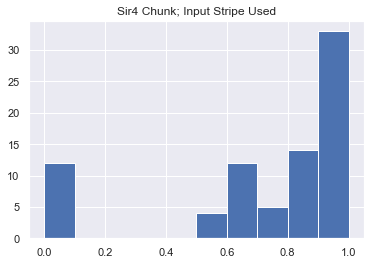

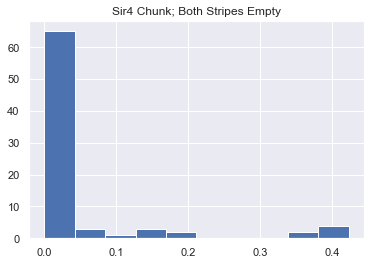

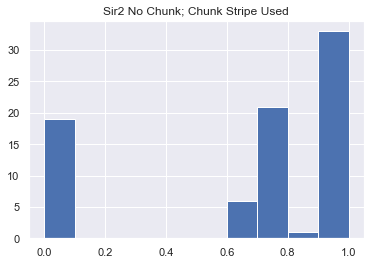

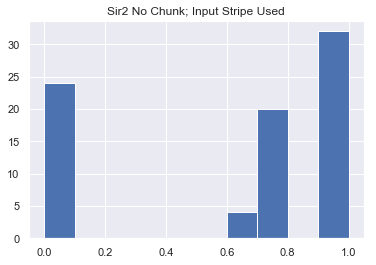

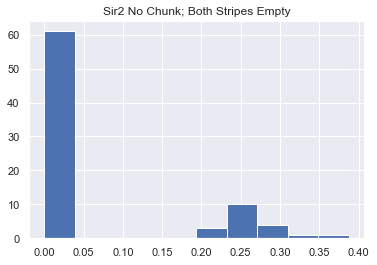

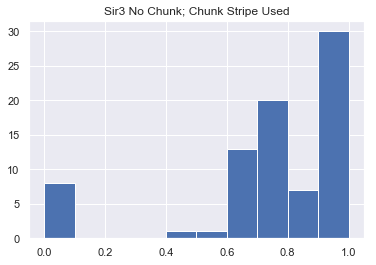

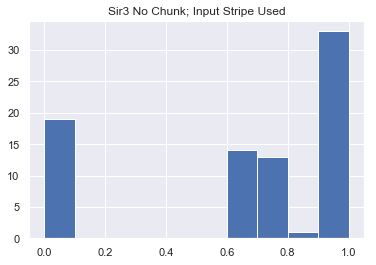

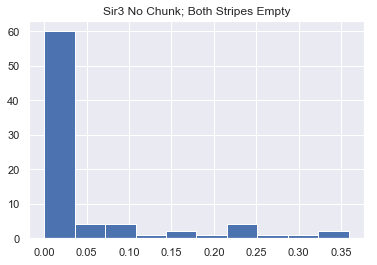

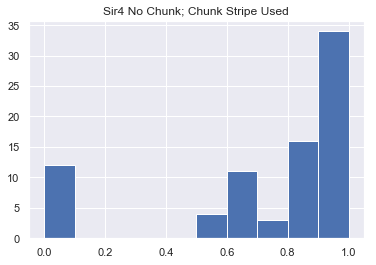

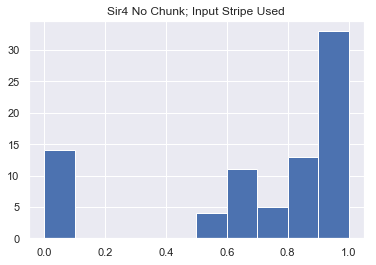

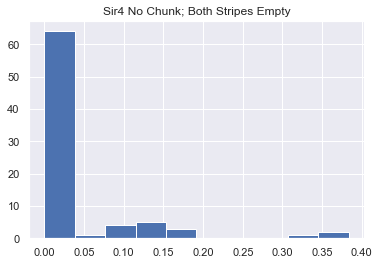

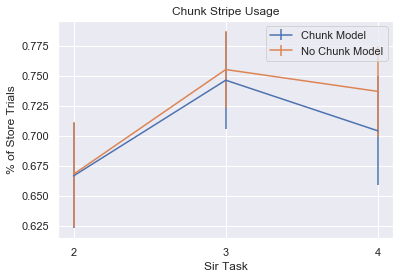

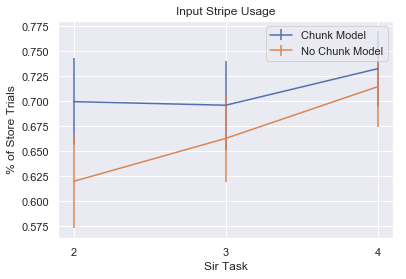

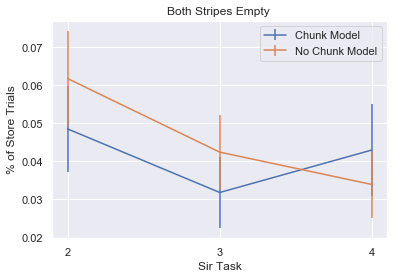

In [5]:
#Burst16, Dip 4
new2chunkmodels_empty = []
new2chunkmodels_empty_std = []
new2nochunkmodels_empty = []
new2nochunkmodels_empty_std = []

new2chunk_used_chunkmodels = []
new2chunk_used_chunkmodels_std = []
new2chunk_used_nochunkmodels = []
new2chunk_used_nochunkmodels_std = []

new2input_used_chunkmodels = []
new2input_used_chunkmodels_std = []
new2input_used_nochunkmodels = []
new2input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],new2chunk_used_chunkmodels,yerr = new2chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2chunk_used_nochunkmodels,yerr = new2chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2input_used_chunkmodels, yerr = new2input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2input_used_nochunkmodels,yerr = new2input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2chunkmodels_empty,yerr = new2chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],new2nochunkmodels_empty, yerr = new2nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


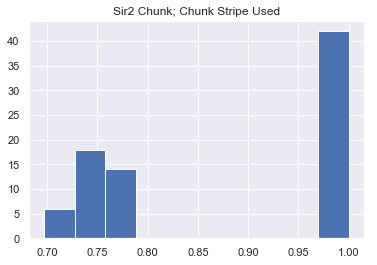

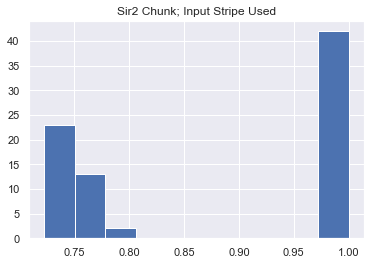

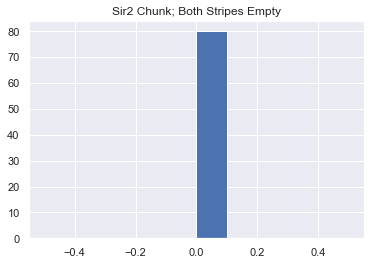

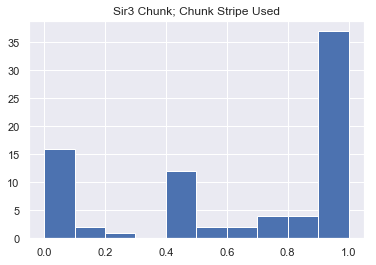

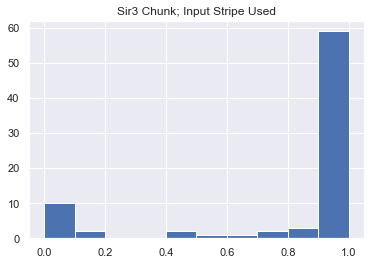

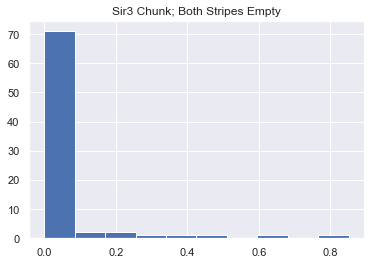

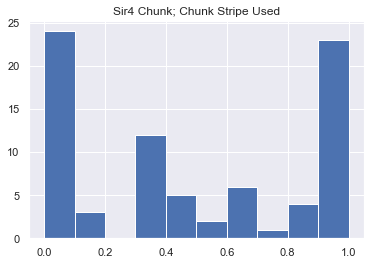

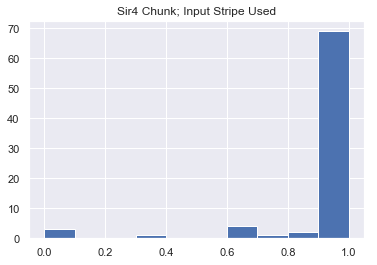

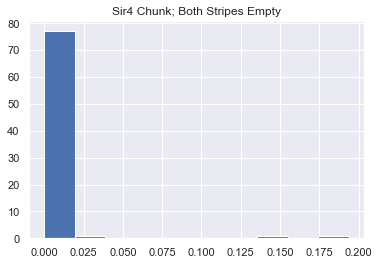

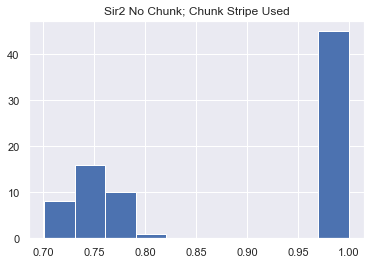

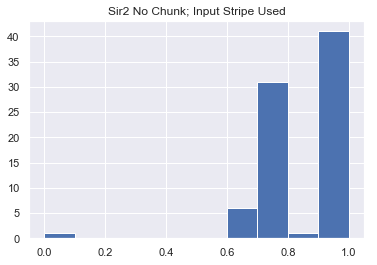

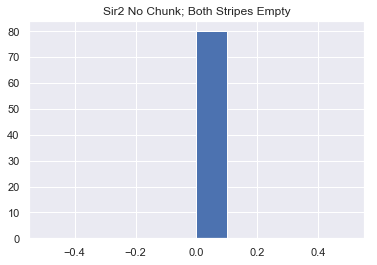

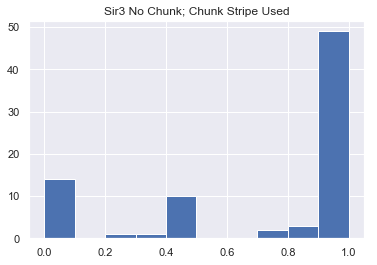

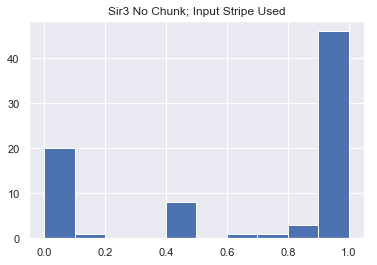

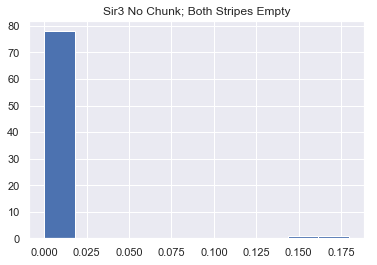

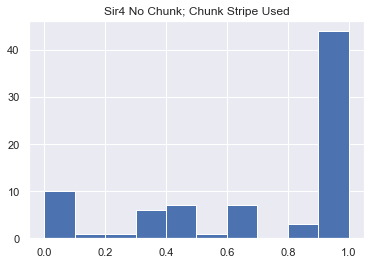

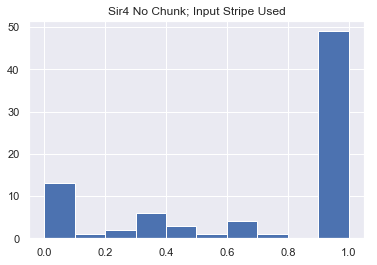

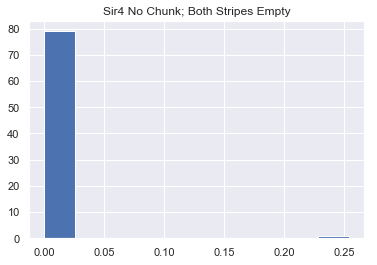

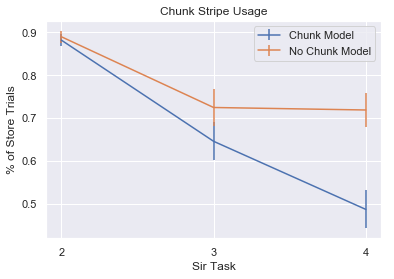

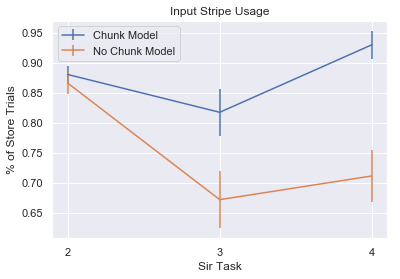

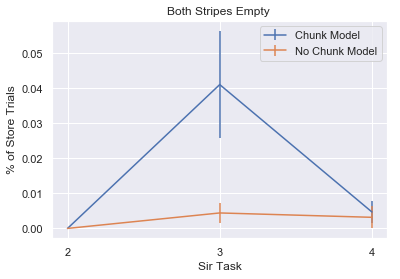

In [29]:
new2chunkmodels_empty = []
new2chunkmodels_empty_std = []
new2nochunkmodels_empty = []
new2nochunkmodels_empty_std = []

new2chunk_used_chunkmodels = []
new2chunk_used_chunkmodels_std = []
new2chunk_used_nochunkmodels = []
new2chunk_used_nochunkmodels_std = []

new2input_used_chunkmodels = []
new2input_used_chunkmodels_std = []
new2input_used_nochunkmodels = []
new2input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2chunkmodels_empty.append(np.mean(empty_perc_all))
new2chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_chunkmodels.append(np.mean(chk_all))
new2chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_chunkmodels.append(np.mean(inp_all))
new2input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new2nochunkmodels_empty.append(np.mean(empty_perc_all))
new2nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new2chunk_used_nochunkmodels.append(np.mean(chk_all))
new2chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new2input_used_nochunkmodels.append(np.mean(inp_all))
new2input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],new2chunk_used_chunkmodels,yerr = new2chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2chunk_used_nochunkmodels,yerr = new2chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2input_used_chunkmodels, yerr = new2input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new2input_used_nochunkmodels,yerr = new2input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new2chunkmodels_empty,yerr = new2chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],new2nochunkmodels_empty, yerr = new2nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


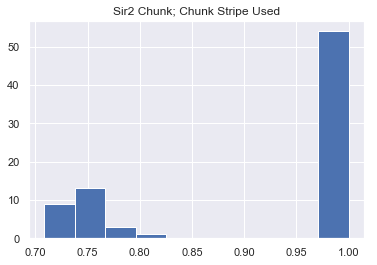

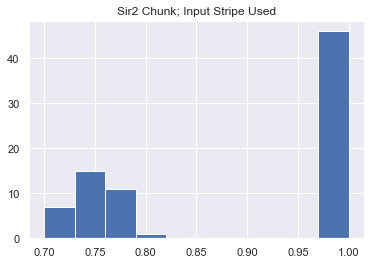

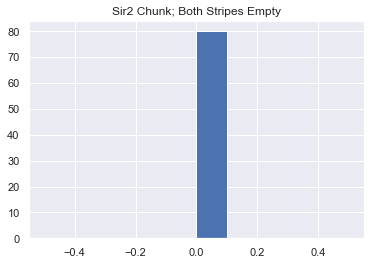

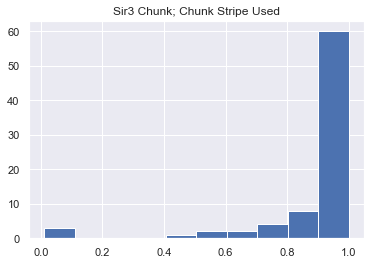

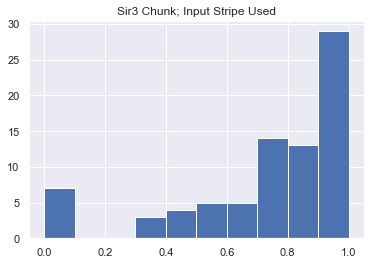

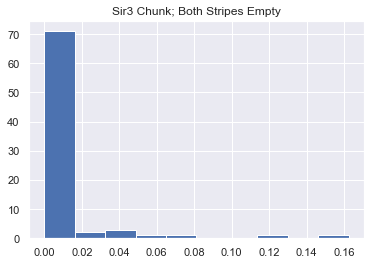

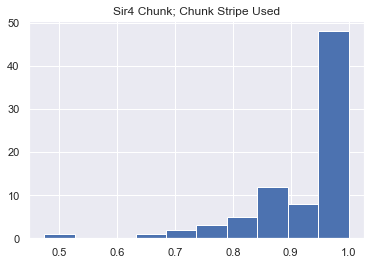

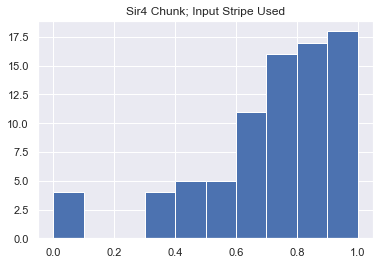

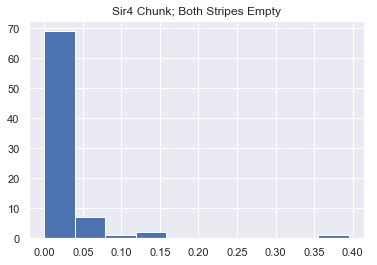

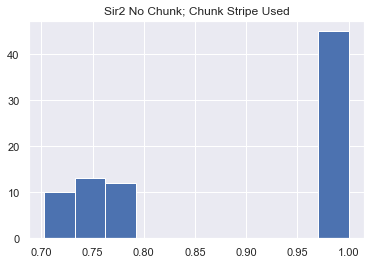

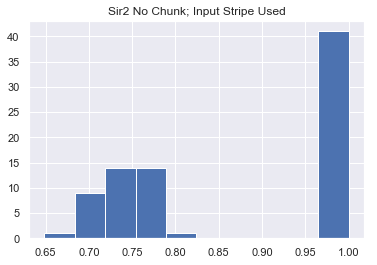

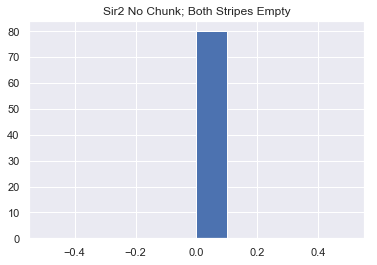

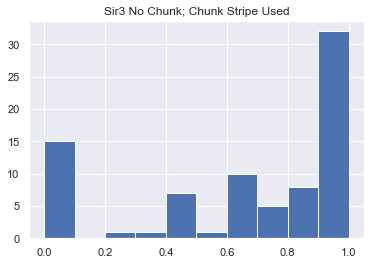

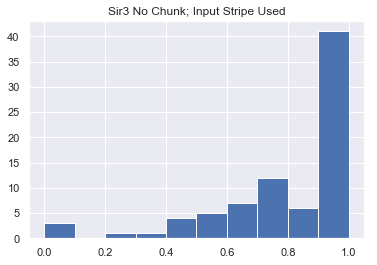

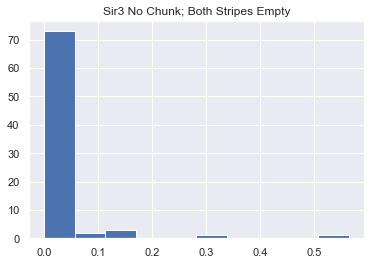

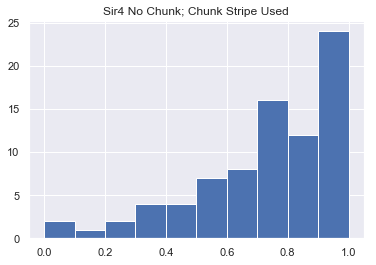

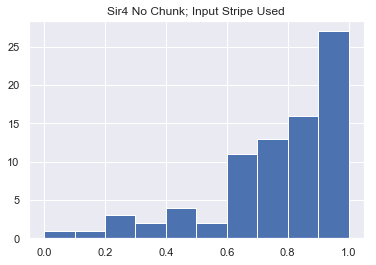

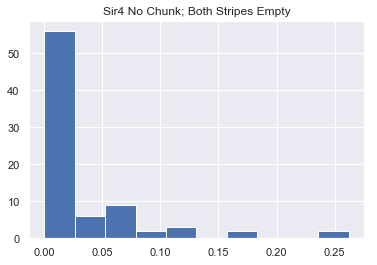

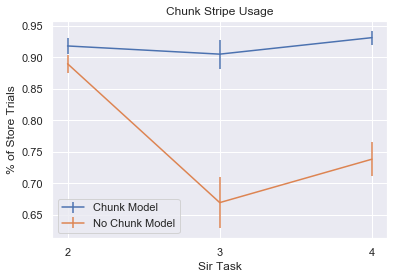

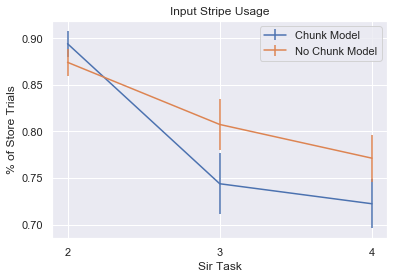

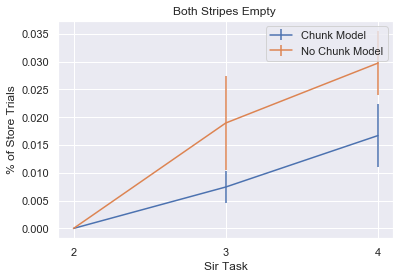

In [30]:
new3chunkmodels_empty = []
new3chunkmodels_empty_std = []
new3nochunkmodels_empty = []
new3nochunkmodels_empty_std = []

new3chunk_used_chunkmodels = []
new3chunk_used_chunkmodels_std = []
new3chunk_used_nochunkmodels = []
new3chunk_used_nochunkmodels_std = []

new3input_used_chunkmodels = []
new3input_used_chunkmodels_std = []
new3input_used_nochunkmodels = []
new3input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

new3chunkmodels_empty.append(np.mean(empty_perc_all))
new3chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new3chunk_used_chunkmodels.append(np.mean(chk_all))
new3chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new3input_used_chunkmodels.append(np.mean(inp_all))
new3input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new3chunkmodels_empty.append(np.mean(empty_perc_all))
new3chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new3chunk_used_chunkmodels.append(np.mean(chk_all))
new3chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new3input_used_chunkmodels.append(np.mean(inp_all))
new3input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new3chunkmodels_empty.append(np.mean(empty_perc_all))
new3chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new3chunk_used_chunkmodels.append(np.mean(chk_all))
new3chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new3input_used_chunkmodels.append(np.mean(inp_all))
new3input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new3nochunkmodels_empty.append(np.mean(empty_perc_all))
new3nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new3chunk_used_nochunkmodels.append(np.mean(chk_all))
new3chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new3input_used_nochunkmodels.append(np.mean(inp_all))
new3input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new3nochunkmodels_empty.append(np.mean(empty_perc_all))
new3nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new3chunk_used_nochunkmodels.append(np.mean(chk_all))
new3chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new3input_used_nochunkmodels.append(np.mean(inp_all))
new3input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
new3nochunkmodels_empty.append(np.mean(empty_perc_all))
new3nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
new3chunk_used_nochunkmodels.append(np.mean(chk_all))
new3chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
new3input_used_nochunkmodels.append(np.mean(inp_all))
new3input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],new3chunk_used_chunkmodels,yerr = new3chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new3chunk_used_nochunkmodels,yerr = new3chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new3input_used_chunkmodels, yerr = new3input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],new3input_used_nochunkmodels,yerr = new3input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],new3chunkmodels_empty,yerr = new3chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],new3nochunkmodels_empty, yerr = new3nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

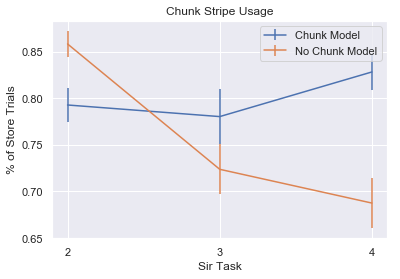

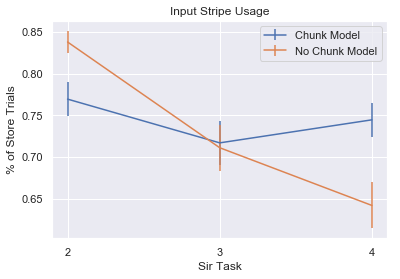

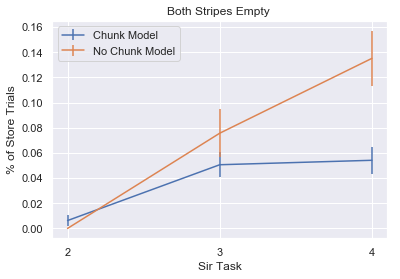

In [27]:
newchunkmodels_empty = []
newchunkmodels_empty_std = []
newnochunkmodels_empty = []
newnochunkmodels_empty_std = []

newchunk_used_chunkmodels = []
newchunk_used_chunkmodels_std = []
newchunk_used_nochunkmodels = []
newchunk_used_nochunkmodels_std = []

newinput_used_chunkmodels = []
newinput_used_chunkmodels_std = []
newinput_used_nochunkmodels = []
newinput_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

newchunkmodels_empty.append(np.mean(empty_perc_all))
newchunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
newchunk_used_chunkmodels.append(np.mean(chk_all))
newchunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
newinput_used_chunkmodels.append(np.mean(inp_all))
newinput_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
newchunkmodels_empty.append(np.mean(empty_perc_all))
newchunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
newchunk_used_chunkmodels.append(np.mean(chk_all))
newchunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
newinput_used_chunkmodels.append(np.mean(inp_all))
newinput_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
newchunkmodels_empty.append(np.mean(empty_perc_all))
newchunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
newchunk_used_chunkmodels.append(np.mean(chk_all))
newchunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
newinput_used_chunkmodels.append(np.mean(inp_all))
newinput_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
newnochunkmodels_empty.append(np.mean(empty_perc_all))
newnochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
newchunk_used_nochunkmodels.append(np.mean(chk_all))
newchunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
newinput_used_nochunkmodels.append(np.mean(inp_all))
newinput_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
newnochunkmodels_empty.append(np.mean(empty_perc_all))
newnochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
newchunk_used_nochunkmodels.append(np.mean(chk_all))
newchunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
newinput_used_nochunkmodels.append(np.mean(inp_all))
newinput_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
newnochunkmodels_empty.append(np.mean(empty_perc_all))
newnochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
newchunk_used_nochunkmodels.append(np.mean(chk_all))
newchunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
newinput_used_nochunkmodels.append(np.mean(inp_all))
newinput_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

plt.figure()

plt.errorbar([2,3,4],newchunk_used_chunkmodels,yerr = newchunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],newchunk_used_nochunkmodels,yerr = newchunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],newinput_used_chunkmodels, yerr = newinput_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],newinput_used_nochunkmodels,yerr = newinput_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],newchunkmodels_empty,yerr = newchunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],newnochunkmodels_empty, yerr = newnochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

sir2 chunk
sir3 chunk
sir4 chunk
sir2 no chunk
sir3 no chunk
sir4 no chunk


Text(0.5, 1.0, 'Sir4 No Chunk; Both Stripes Empty')

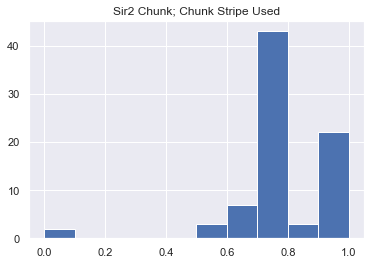

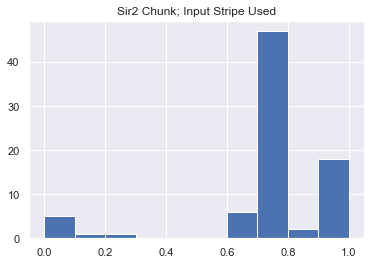

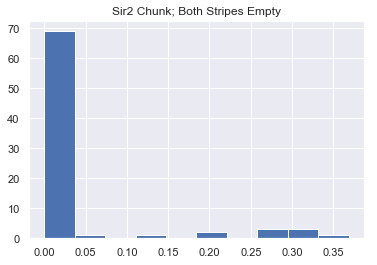

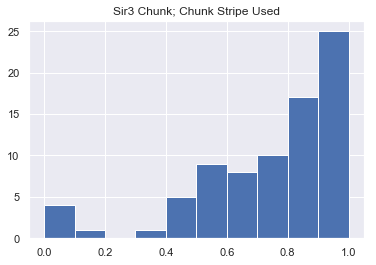

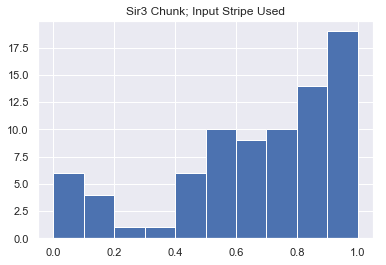

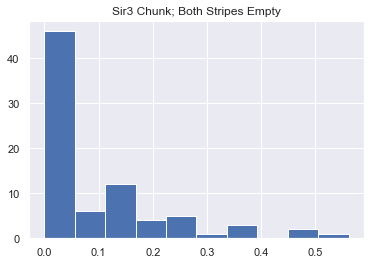

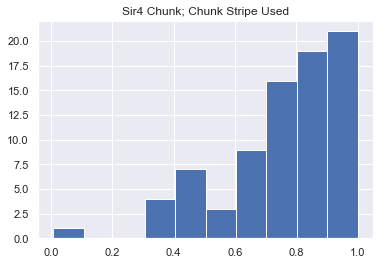

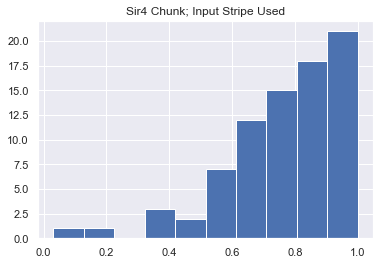

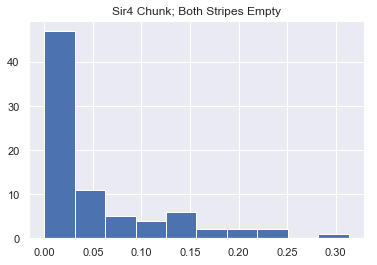

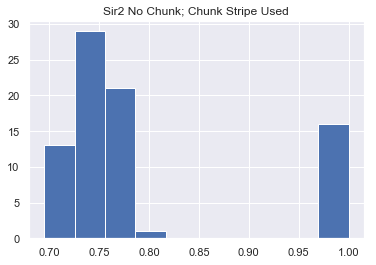

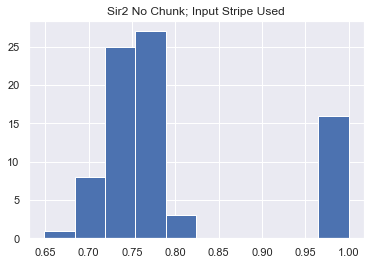

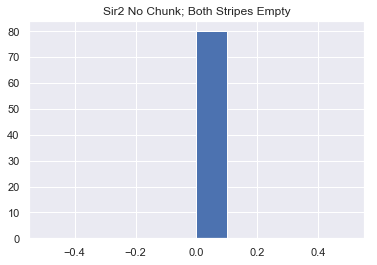

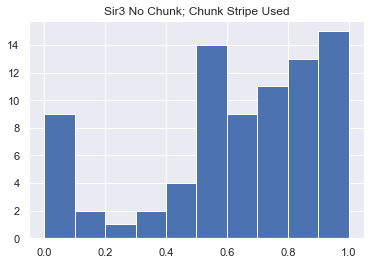

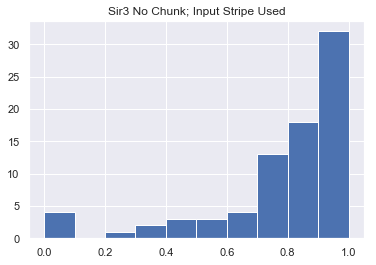

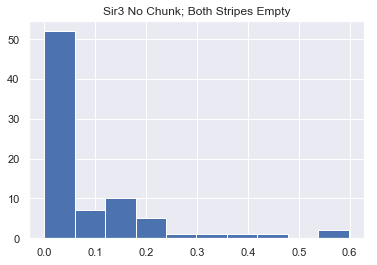

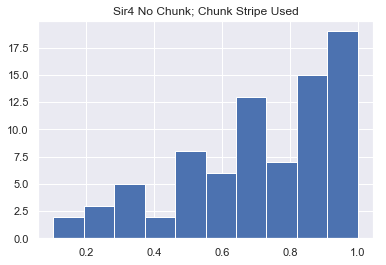

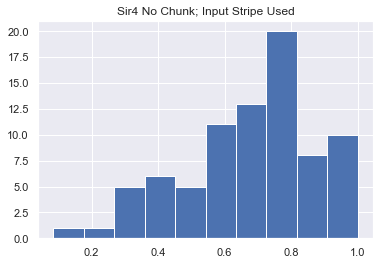

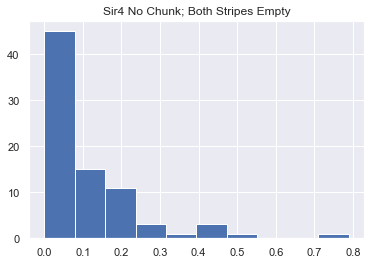

In [18]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')

print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

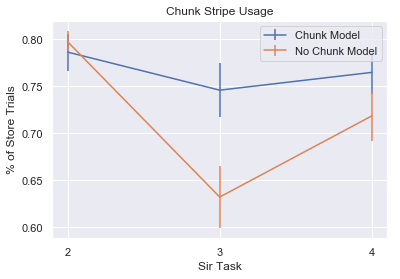

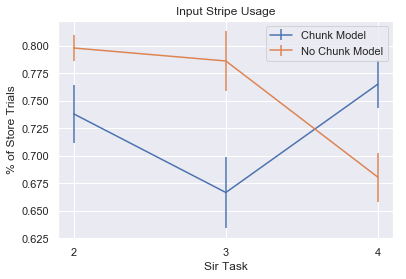

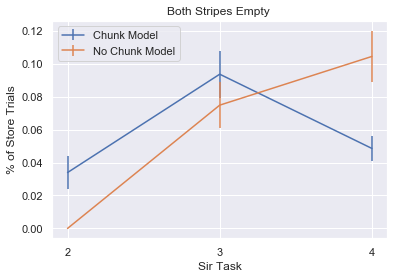

In [19]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [5]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []


sir2 chunk


Text(0.5, 1.0, 'Sir2 Chunk; Both Stripes Empty')

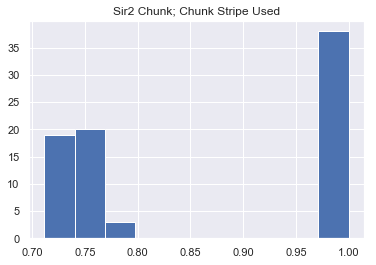

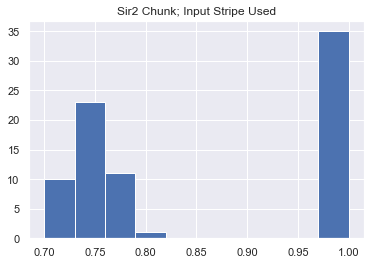

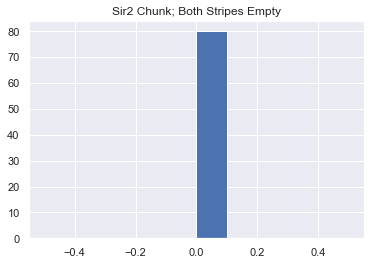

In [11]:
print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')

sir2 chunk
sir3 chunk
sir4 chunk


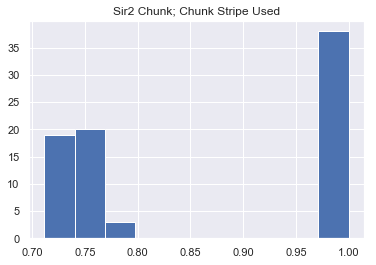

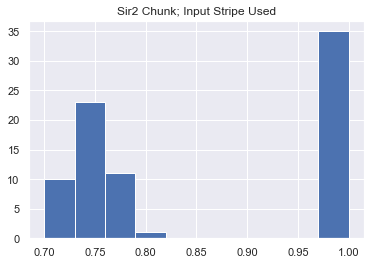

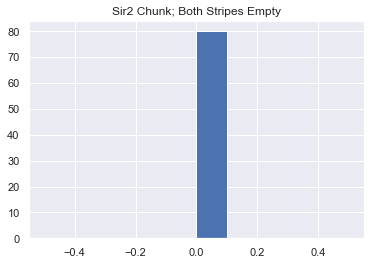

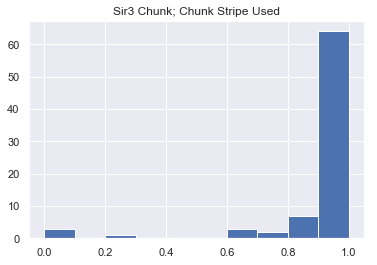

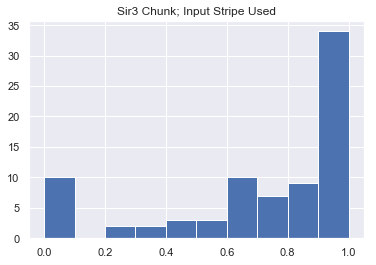

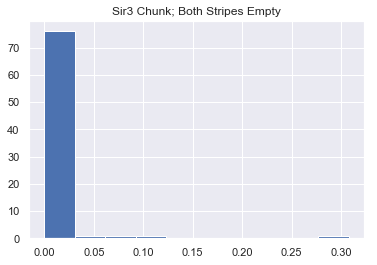

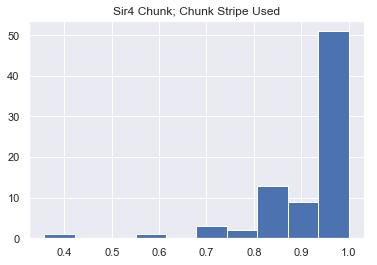

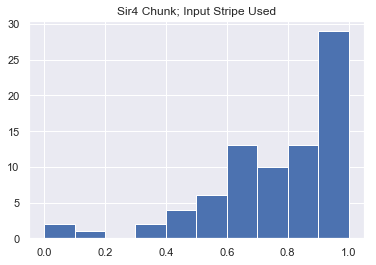

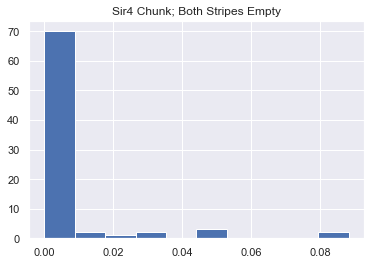

In [15]:
chunkmodels_empty = []
chunkmodels_empty_std = []
nochunkmodels_empty = []
nochunkmodels_empty_std = []

chunk_used_chunkmodels = []
chunk_used_chunkmodels_std = []
chunk_used_nochunkmodels = []
chunk_used_nochunkmodels_std = []

input_used_chunkmodels = []
input_used_chunkmodels_std = []
input_used_nochunkmodels = []
input_used_nochunkmodels_std = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)

chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 Chunk; Both Stripes Empty')
chk_all_2 = chk_all
inp_all_2 = inp_all

print('sir3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 Chunk; Both Stripes Empty')
chk_all_3 = chk_all
inp_all_3 = inp_all

print('sir4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
chunkmodels_empty.append(np.mean(empty_perc_all))
chunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_chunkmodels.append(np.mean(chk_all))
chunk_used_chunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_chunkmodels.append(np.mean(inp_all))
input_used_chunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 Chunk; Both Stripes Empty')
chk_all_4 = chk_all
inp_all_4 = inp_all

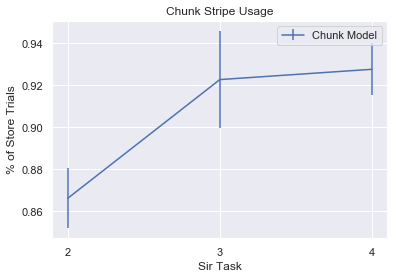

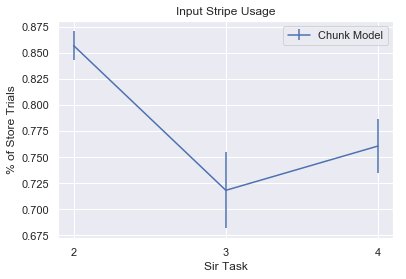

In [35]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

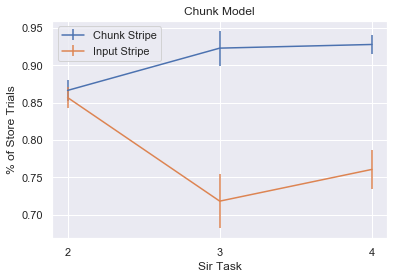

In [36]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Stripe')
plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Input Stripe')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Model')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape

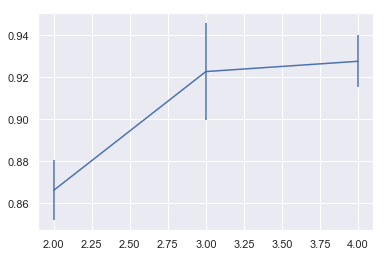

In [33]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

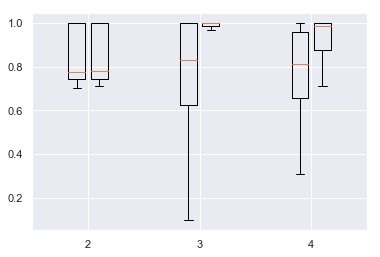

In [32]:
x = np.array([1000,2000,3000])
data1 = np.array([inp_all_2,inp_all_3, inp_all_4]).T
data2 = np.array([chk_all_2,chk_all_3, chk_all_4]).T
plt.figure()
plt.boxplot(data1,0,'',positions=x-100,widths=150)
plt.boxplot(data2,0,'',positions=x+100,widths=150)
plt.xlim(500,3500)
plt.xticks(x,labels = ['2', '3', '4'])
plt.show()

In [19]:
len(inp_all_2)

80

{'whiskers': [<matplotlib.lines.Line2D at 0x12716491550>,
 'caps': [<matplotlib.lines.Line2D at 0x12716491c50>,
 'boxes': [<matplotlib.lines.Line2D at 0x12716491128>],
 'medians': [<matplotlib.lines.Line2D at 0x12716499390>],
 'fliers': [<matplotlib.lines.Line2D at 0x12716499710>],
 'means': []}

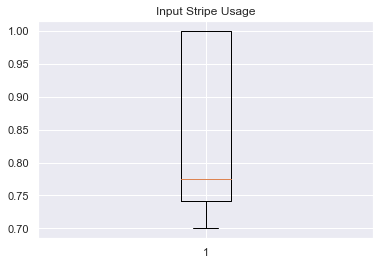

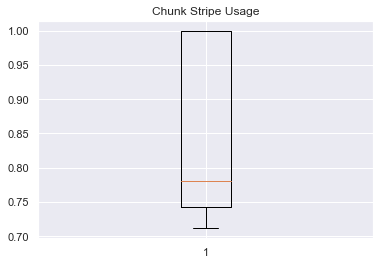

In [12]:
plt.boxplot(inp_all)
plt.title('Input Stripe Usage')

plt.figure()
plt.title('Chunk Stripe Usage')
plt.boxplot(chk_all)

sir2 no chunk
sir3 no chunk
sir4 no chunk


Text(0.5, 1.0, 'Sir4 No Chunk; Both Stripes Empty')

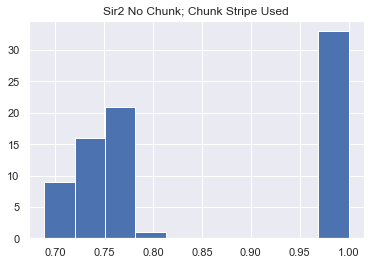

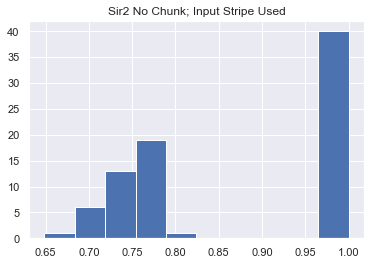

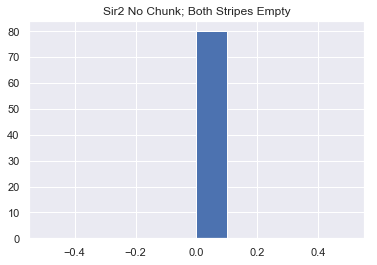

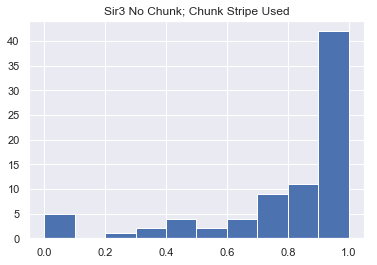

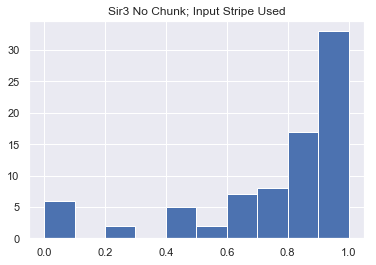

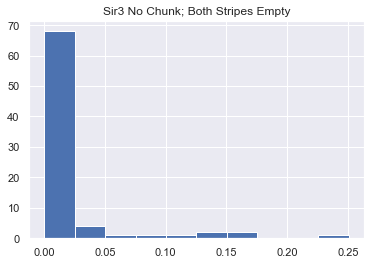

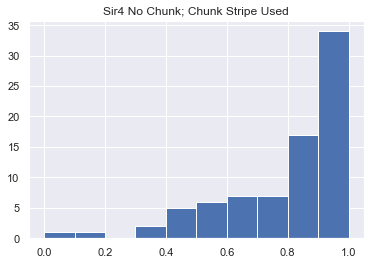

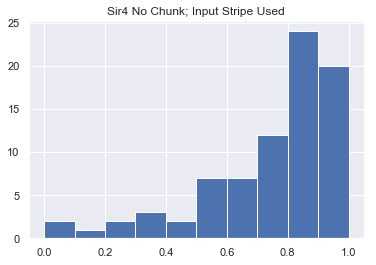

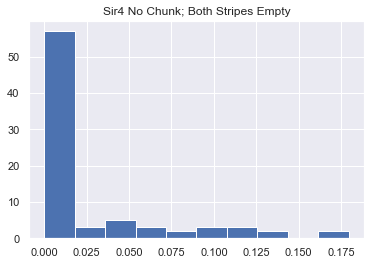

In [8]:
print('sir2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir2 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir2 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir2 No Chunk; Both Stripes Empty')

print('sir3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir3 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir3 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir3 No Chunk; Both Stripes Empty')

print('sir4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
chk_all, inp_all, empty_perc_all = all_files_sep(base)
nochunkmodels_empty.append(np.mean(empty_perc_all))
nochunkmodels_empty_std.append(np.std(empty_perc_all)/np.sqrt(80))
chunk_used_nochunkmodels.append(np.mean(chk_all))
chunk_used_nochunkmodels_std.append(np.std(chk_all)/np.sqrt(80))
input_used_nochunkmodels.append(np.mean(inp_all))
input_used_nochunkmodels_std.append(np.std(inp_all)/np.sqrt(80))
plt.figure()
plt.hist(chk_all)
plt.title('Sir4 No Chunk; Chunk Stripe Used')
plt.figure()
plt.hist(inp_all)
plt.title('Sir4 No Chunk; Input Stripe Used')
plt.figure()
plt.hist(empty_perc_all)
plt.title('Sir4 No Chunk; Both Stripes Empty')

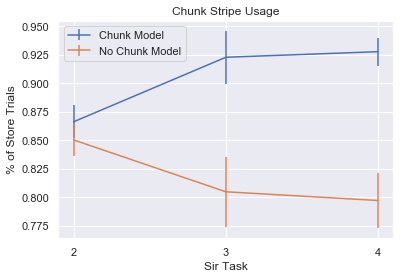

In [14]:
plt.errorbar([2,3,4],chunk_used_chunkmodels,yerr = chunk_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],chunk_used_nochunkmodels,yerr = chunk_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

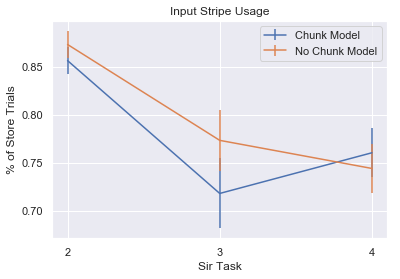

In [16]:
plt.errorbar([2,3,4],input_used_chunkmodels, yerr = input_used_chunkmodels_std, label='Chunk Model')
plt.errorbar([2,3,4],input_used_nochunkmodels,yerr = input_used_nochunkmodels_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

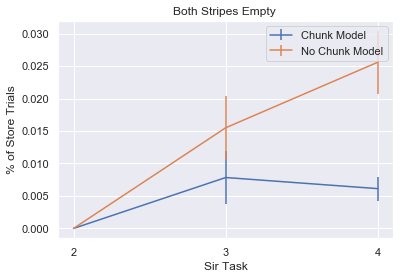

In [17]:
plt.errorbar([2,3,4],chunkmodels_empty,yerr = chunkmodels_empty_std,label='Chunk Model')
plt.errorbar([2,3,4],nochunkmodels_empty, yerr = nochunkmodels_empty_std, label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [32]:
chunkmodels_empty = []
nochunkmodels_empty = []
chunk_used_chunkmodels = []
chunk_used_nochunkmodels = []
input_used_chunkmodels = []
input_used_nochunkmodels = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_chunkmodels.append(chk)
input_used_chunkmodels.append(inp)
chunkmodels_empty.append(empty_perc)

print('sir 2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_nochunkmodels.append(chk)
input_used_nochunkmodels.append(inp)
nochunkmodels_empty.append(empty_perc)

print('sir 3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_chunkmodels.append(chk)
input_used_chunkmodels.append(inp)
chunkmodels_empty.append(empty_perc)

print('sir 3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_nochunkmodels.append(chk)
input_used_nochunkmodels.append(inp)
nochunkmodels_empty.append(empty_perc)

print('sir 4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_chunkmodels.append(chk)
input_used_chunkmodels.append(inp)
chunkmodels_empty.append(empty_perc)

print('sir 4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_nochunkmodels.append(chk)
input_used_nochunkmodels.append(inp)
nochunkmodels_empty.append(empty_perc)


In [26]:
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#df = get_df(base)
#df_recall = pd.read_csv("sir3_good_order")
both_stripes_used = stripes_used_before_recall(df, df_recall = df_recall)
both_stripes_used.to_csv("both_stripes_used_and_good_order")


base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
df_recall_nochunk = pd.read_csv("sir3_good_order_nochunk")
both_stripes_used_nochunk = stripes_used_before_recall(df, df_recall = df_recall_nochunk)
both_stripes_used_nochunk.to_csv("both_stripes_used_and_good_order_nochunk")

In [ ]:
both_stripes_used_nochunk

In [5]:
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
both_stripes_used_nochunk = stripes_used_before_recall(df)

In [6]:
both_stripes_used_nochunk.to_csv("both_stripes_used_nochunk")

In [29]:
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
both_stripes_used_nochunk = stripes_used_before_recall(df)
both_stripes_used_nochunk.to_csv("both_stripes_used_nochunk")

In [32]:
both_stripes_used_nochunk

In [36]:
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
df['ind'] = range(len(df))

both_stripes_used = pd.DataFrame()
df_recall = df.loc['True']
for i in range(len(df_recall)):
    recall_tr = df_recall.iloc[i]['ind']
    #need to find the previous store trial - right before the recall
    need_store = True
    tb = 1 #trials back
    if need_store:
        tr = recall_tr - tb
        full_tr = df[df['ind']==tr]
        if 'Store' in full_tr['$TrialName'][0]:
            need_store = False
            if full_tr['#stripe'][0]!= 0.0 and full_tr['#stripe\x01'][0]!= 0.0:
                both_stripes_used = both_stripes_used.append(df_recall.iloc[i]) #want the recall trials that we want to keep.
            

In [26]:
both_stripes_used.to_csv('both_stripes_used')

In [ ]:
chunkmodels_empty = []
nochunkmodels_empty = []
chunk_used_chunkmodels = []
chunk_used_nochunkmodels = []
input_used_chunkmodels = []
input_used_nochunkmodels = []

print('sir2 chunk')
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_chunkmodels.append(chk)
input_used_chunkmodels.append(inp)
chunkmodels_empty.append(empty_perc)

print('sir 2 no chunk')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_nochunkmodels.append(chk)
input_used_nochunkmodels.append(inp)
nochunkmodels_empty.append(empty_perc)

print('sir 3 chunk')
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_chunkmodels.append(chk)
input_used_chunkmodels.append(inp)
chunkmodels_empty.append(empty_perc)

print('sir 3 no chunk')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_nochunkmodels.append(chk)
input_used_nochunkmodels.append(inp)
nochunkmodels_empty.append(empty_perc)

print('sir 4 chunk')
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_chunkmodels.append(chk)
input_used_chunkmodels.append(inp)
chunkmodels_empty.append(empty_perc)

print('sir 4 no chunk')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)
empty_perc = get_empty(chunkstripeNR, inputstripeNR)
chunk_used_nochunkmodels.append(chk)
input_used_nochunkmodels.append(inp)
nochunkmodels_empty.append(empty_perc)


In [ ]:
plt.plot([2,3,4],chunk_used_chunkmodels, '--bo', label='Chunk Model')
plt.plot([2,3,4],chunk_used_nochunkmodels, '--ro', label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Chunk Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
plt.plot([2,3,4],input_used_chunkmodels, '--bo', label='Chunk Model')
plt.plot([2,3,4],input_used_nochunkmodels, '--ro', label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Input Stripe Usage')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
plt.plot([2,3,4],chunkmodels_empty, '--bo', label='Chunk Model')
plt.plot([2,3,4],nochunkmodels_empty, '--ro', label='No Chunk Model')
plt.xticks([2,3,4])
plt.legend()
plt.title('Both Stripes Empty ')
plt.xlabel('Sir Task')
plt.ylabel('% of Store Trials')
plt.show()

In [ ]:
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
df = get_df(base)
chunkstripeNR, inputstripeNR = find_stripe_prop(df)

In [ ]:
chk,inp = calc_perc(chunkstripeNR, inputstripeNR)

In [ ]:
print(np.sum(inputstripeNR != 0.0)/len(inputstripeNR))
print(np.sum(chunkstripeNR != 0.0)/len(chunkstripeNR))

In [ ]:
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
file = "sir4chunkhybridmodel0_RewThreshold5.5_decoded_Base.csv"

In [ ]:
df_include= []
for i in df['$TrialName']:
    if 'Recall' in i:
        df_include.append('True')
    else:
        df_include.append('False')
df.index = df_include
df_recall = df.loc['True']
df_norecall = df.loc['False']

In [ ]:
chunkstripeNR = df_norecall['#stripe']
inputstripeNR = df_norecall['#stripe\x01']

In [ ]:
print(np.sum(inputstripeNR != 0.0)/len(inputstripeNR))
print(np.sum(chunkstripeNR != 0.0)/len(chunkstripeNR))

In [ ]:
df = pd.read_csv(base+file, sep = '\s+')

In [ ]:
chunkstripe = df['#stripe']

In [ ]:
inputstripe = df['#stripe\x01']

In [ ]:
np.sum(inputstripe != 0.0)/len(inputstripe)

In [ ]:
np.sum(chunkstripe != 0.0)/len(chunkstripe)

In [ ]:
inputstripe